-------------------------------------------------------------
## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 4 : classifiez automatiquement des informations
-------------------------------------------------------------

## Etape préalable

In [1]:
# Contrôle présence venv uv 
import sys
print(sys.executable)

/mnt/projects/ai_engineer_projects/P04/.venv/bin/python3


In [2]:
# Contrôle version python
sys.version

'3.11.15 (main, Mar 10 2026, 18:16:52) [Clang 21.1.4 ]'

In [3]:
# Contrôle présence des bibliothèques installées dans le venv uv
import importlib.metadata as md

packages = [
    "imbalanced-learn", "ipykernel", "jupyterlab",
    "matplotlib", "missingno", "numpy", "pandas", 
    "plotly", "psycopg2-binary", "pyarrow" , "scikit-learn",
    "scipy", "seaborn", "shap", "sqlalchemy", "statsmodels"
]

for p in packages:
    try:
        print(p, md.version(p))
    except:
        print(p, "missing")

imbalanced-learn 0.14.1
ipykernel 7.2.0
jupyterlab 4.5.6
matplotlib 3.10.8
missingno 0.5.2
numpy 2.4.3
pandas 3.0.1
plotly 6.6.0
psycopg2-binary 2.9.11
pyarrow 23.0.1
scikit-learn 1.8.0
scipy 1.17.1
seaborn 0.13.2
shap 0.51.0
sqlalchemy 2.0.48
statsmodels 0.14.6


## Etape 1 : Effectuer une analyse exploratoire des fichiers de données

### Etape 1-1 : EDA du dataframe df_sirh avant jointure

In [4]:
# Chargement en dataframes pandas des 3 fichiers sources sirh, évaluation et sondage  
import pandas as pd

In [5]:
df_sirh = pd.read_csv("../data/raw/extrait_sirh.csv")

In [6]:
df_sirh.head(3)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0


In [7]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 191.1 KB


In [8]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sirh.rename(columns={
    "id_employee": "id_salarie",
    "nombre_heures_travailless": "nombre_heures_travaillees",
    "annee_experience_totale" : "nombre_total_annees_experience",
    "annees_dans_l_entreprise" : "nombre_total_annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel" : "nombre_total_annees_dans_le_poste_actuel"  
}, inplace=True)

In [9]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [10]:
# identification des colonnes numériques
int_cols_sirh = df_sirh.select_dtypes(include="int64").columns
print(int_cols_sirh)

Index(['id_salarie', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travaillees', 'nombre_total_annees_experience',
       'nombre_total_annees_dans_l_entreprise',
       'nombre_total_annees_dans_le_poste_actuel'],
      dtype='str')


In [11]:
# Vérification absence de decimales sur les valeurs au format int64
for col in int_cols_sirh:
    a_decimales = (df_sirh[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

id_salarie a décimales ? False
age a décimales ? False
revenu_mensuel a décimales ? False
nombre_experiences_precedentes a décimales ? False
nombre_heures_travaillees a décimales ? False
nombre_total_annees_experience a décimales ? False
nombre_total_annees_dans_l_entreprise a décimales ? False
nombre_total_annees_dans_le_poste_actuel a décimales ? False


In [12]:
# Identification des colonnes type chaînes de caractères
string_cols_sirh = df_sirh.select_dtypes(include="str").columns
print(string_cols_sirh)

Index(['genre', 'statut_marital', 'departement', 'poste'], dtype='str')


In [13]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
<ArrowStringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str
<ArrowStringArray>
['Commercial', 'Consulting', 'Ressources Humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str


In [14]:
# Retirer les majuscules, espaces, accents et parenthèses
import unicodedata

df_sirh[string_cols_sirh] = df_sirh[string_cols_sirh].apply(
    lambda string_cols_sirh: string_cols_sirh.astype(str)
    .str.lower()
    .str.replace(r"[()]", "", regex=True)  
    .str.replace(" ", "_")
    .str.strip("_") 
    .map(lambda x: unicodedata.normalize("NFKD", x)
         .encode("ascii", errors="ignore")
         .decode("utf-8"))
)

In [15]:
# Réafficher les colonnes types chaînes de caractères mises en forme
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['f', 'm']
Length: 2, dtype: str
<ArrowStringArray>
['celibataire', 'mariee', 'divorcee']
Length: 3, dtype: str
<ArrowStringArray>
['commercial', 'consulting', 'ressources_humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'cadre_commercial',  'assistant_de_direction',
              'consultant',               'tech_lead',
                 'manager',          'senior_manager',
 'representant_commercial',     'directeur_technique',
     'ressources_humaines']
Length: 9, dtype: str


In [16]:
# Recherche de valeurs manquantes 
df_sirh.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

id_salarie                                  0
age                                         0
genre                                       0
revenu_mensuel                              0
statut_marital                              0
departement                                 0
poste                                       0
nombre_experiences_precedentes              0
nombre_heures_travaillees                   0
nombre_total_annees_experience              0
nombre_total_annees_dans_l_entreprise       0
nombre_total_annees_dans_le_poste_actuel    0
dtype: int64

In [17]:
# Contrôle présence de doublons sur la colonne id_salarie
df_sirh["id_salarie"].duplicated().any()

np.False_

In [18]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [19]:
# Statistiques descriptives du dataframe df_sirh
df_sirh.describe().T

,count,mean,std,min,25%,50%,75%,max
id_salarie,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0
nombre_heures_travaillees,1470.0,80.000000,0.000000,80.0,80.00,80.0,80.00,80.0
nombre_total_annees_experience,1470.0,11.279592,7.780782,0.0,6.00,10.0,15.00,40.0
nombre_total_annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.0,9.00,40.0
nombre_total_annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.0,7.00,18.0


#### premiere analyse des statistiques descriptives
* anomalies du nombre d'heures travaillées car tous les salariés sont à 80h soit plus de deux fois 35h => cette colonne est peu informative et pourra donc être ignorée
*  la moyenne d'âge des salariés est de 36 ans
*  la distribution des âges des salariés est équilibrée car moyenne = médiane
*  le nombre d'années moyen passées dans l'entreprise est autour de **7 ans**

In [20]:
# suppression de la colonne nombre d'heures travaillées
df_sirh.drop(columns=["nombre_heures_travaillees"], inplace=True)

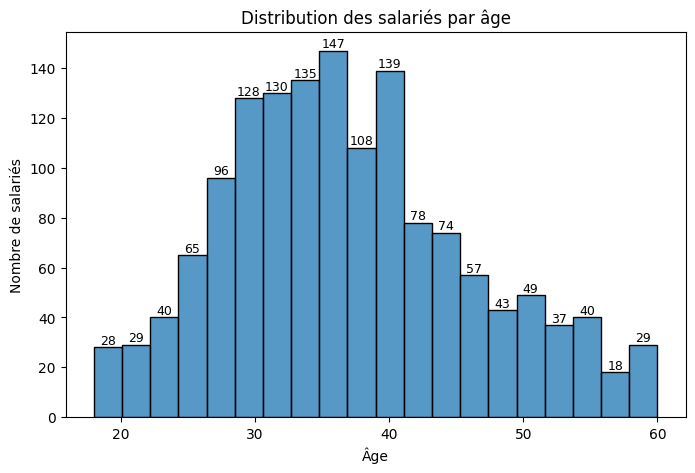

In [21]:
# distribution des âges des salariés

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["age"], bins=20)

plt.title("Distribution des salariés par âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

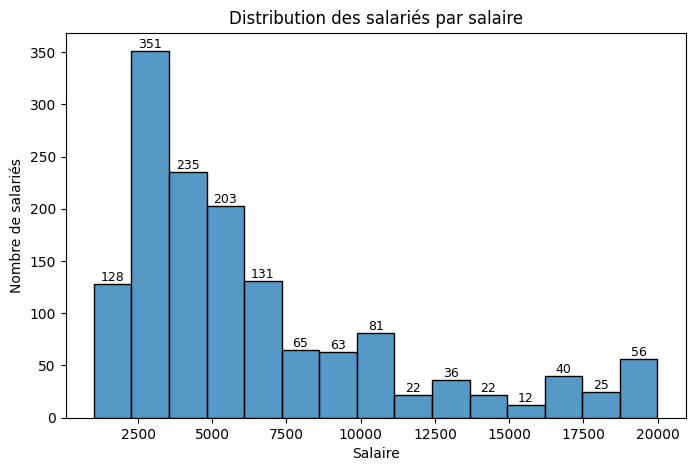

In [22]:
# distribution des revenus mensuels
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["revenu_mensuel"], bins=15)

plt.title("Distribution des salariés par salaire")
plt.xlabel("Salaire")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

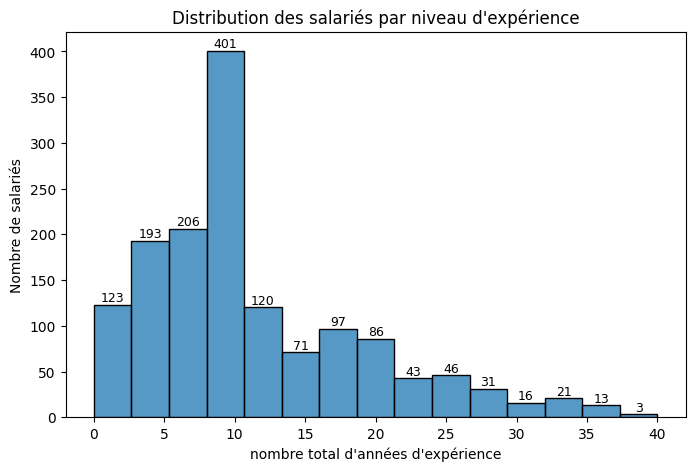

In [23]:
#  Distribution du nombre total d'annees d'experience 
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_experience"], bins=15)

plt.title("Distribution des salariés par niveau d'expérience")
plt.xlabel("nombre total d'années d'expérience")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

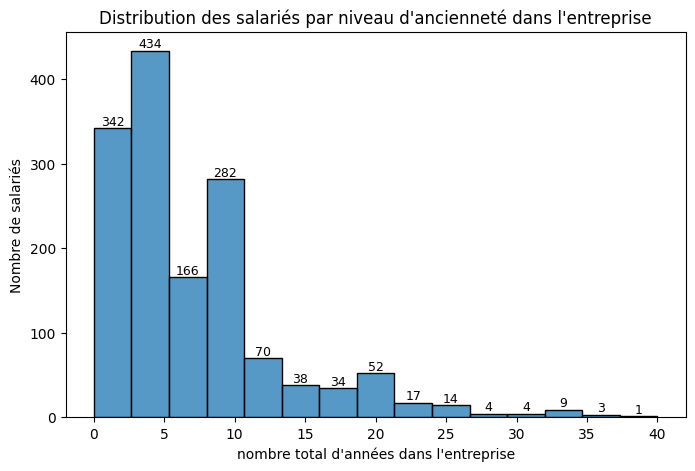

In [24]:
# Distribution du niveau d'ancienneté dans l'entreprise
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_dans_l_entreprise"], bins=15)

plt.title("Distribution des salariés par niveau d'ancienneté dans l'entreprise")
plt.xlabel("nombre total d'années dans l'entreprise")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

#### observations
* le salaire médian de 4 900 € représente le cœur de la population salariale
* la majorité des salariés quittent avant 10 ans
* peu de salariés atteignent donc les niveaux d’ancienneté élevés
* cela peut limiter la progression salariale globale et **potentiellement influencer le turnover**

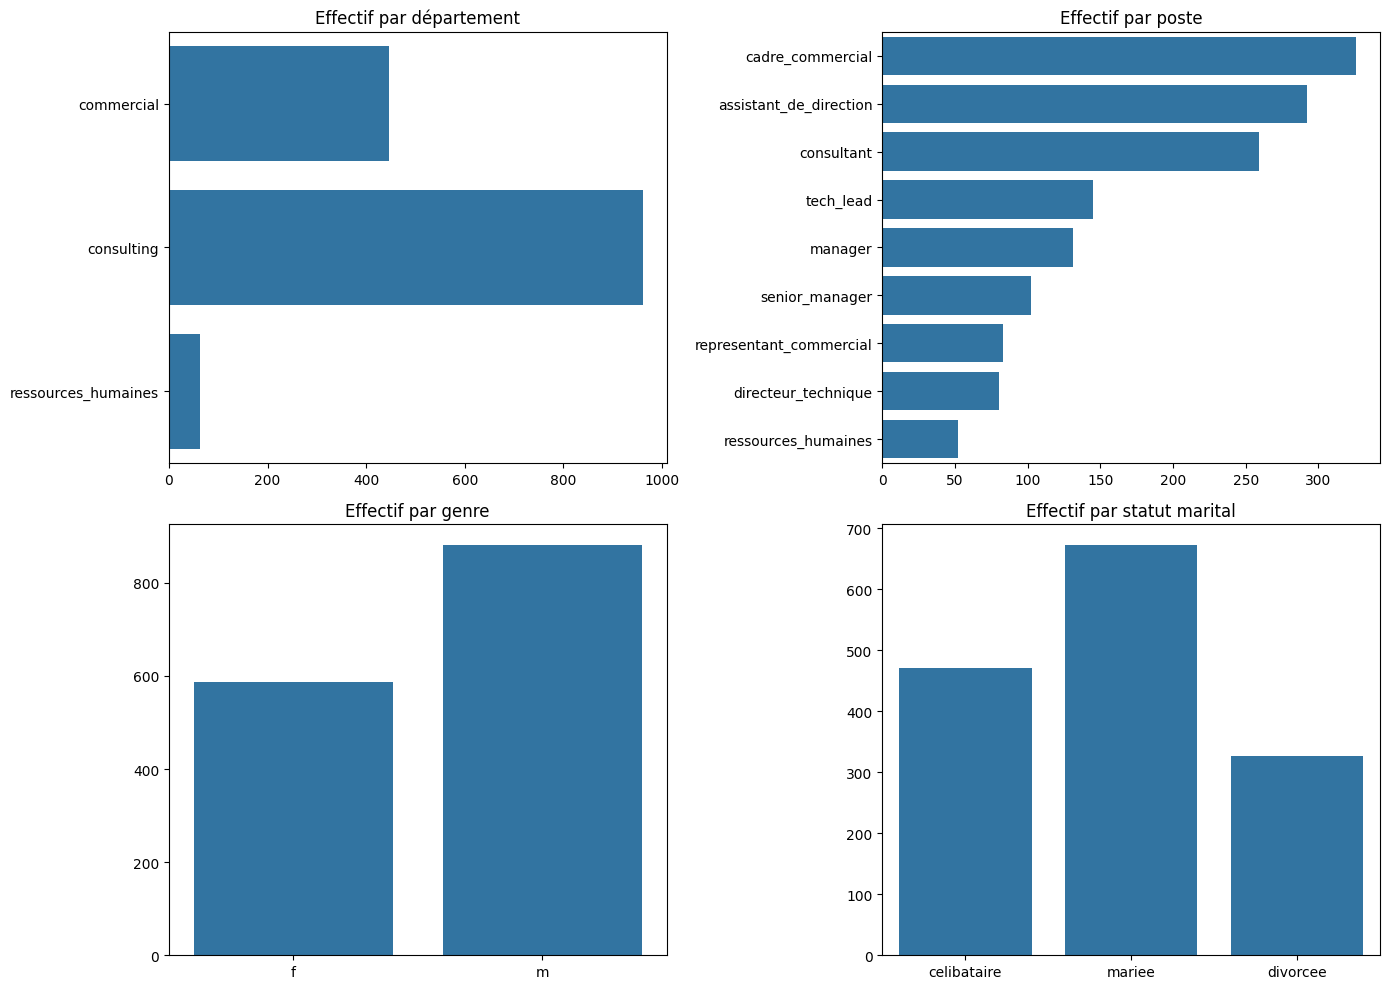

In [25]:
# Distribution par département, poste, genre et statut marital

import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    ("departement", "Effectif par département", "y"),
    ("poste", "Effectif par poste", "y"),
    ("genre", "Effectif par genre", "x"),
    ("statut_marital", "Effectif par statut marital", "x")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, title, orient) in enumerate(cols):
    
    if orient == "y":
        sns.countplot(y=df_sirh[col], ax=axes[i])
    else:
        sns.countplot(x=df_sirh[col], ax=axes[i])
    
    axes[i].set_title(title)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

#### observations
* les postes de cadre commercial, assistant de direction et de consultant sont les plus représentés
* il n'y a pas de déséquilibre profond entre hommes et femmes bien que ces dernières soient à 25% moins représentées que les hommes

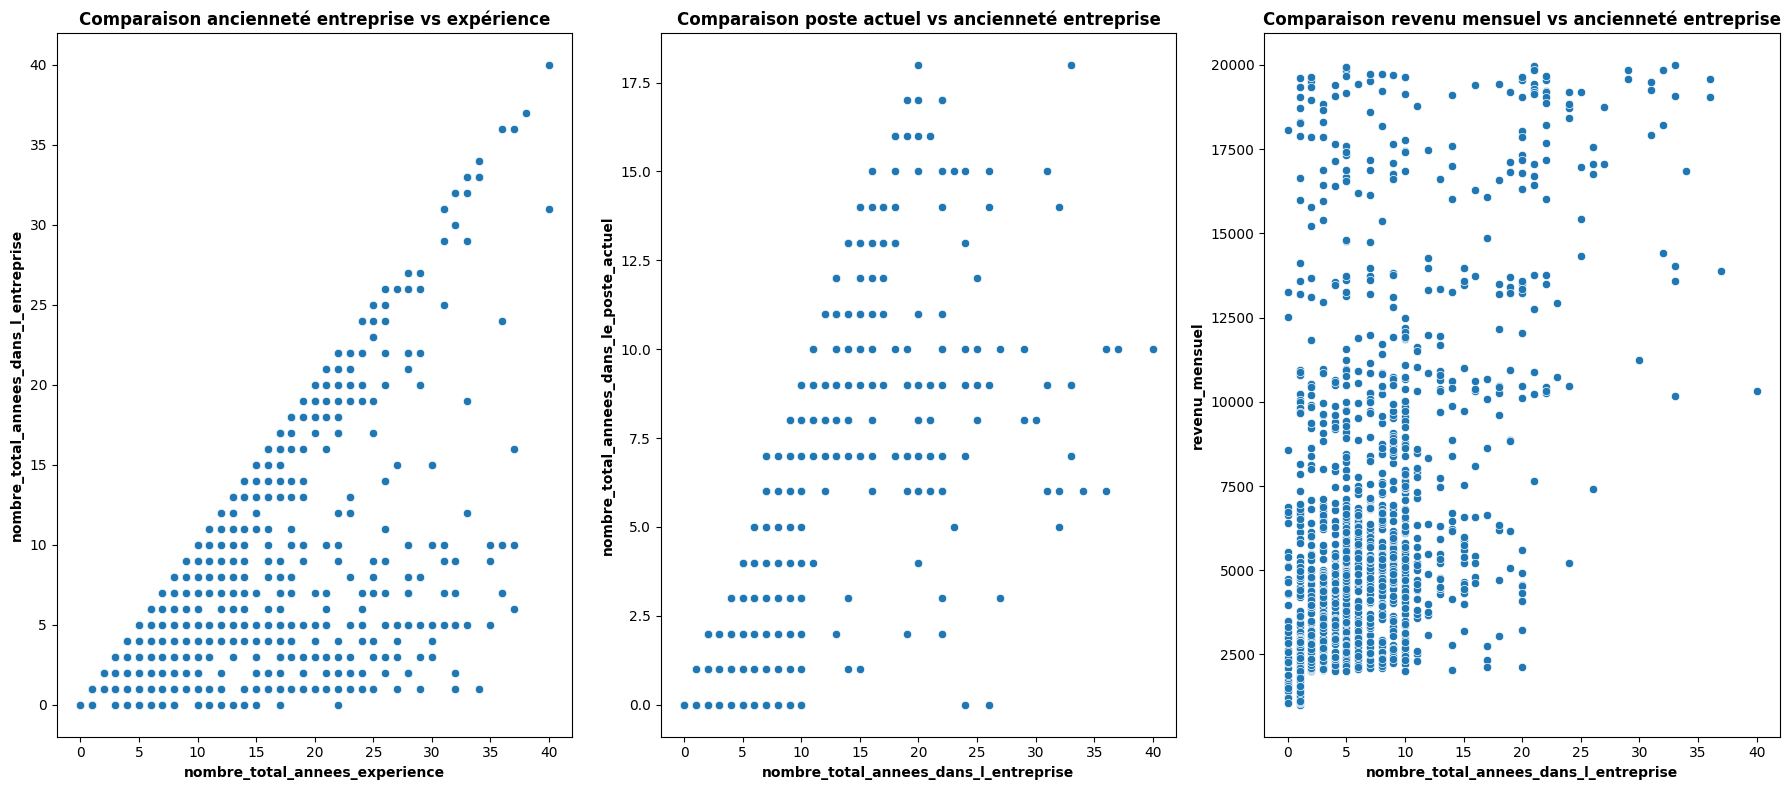

In [26]:
# Recherche de premieres corrélations
import matplotlib.pyplot as plt
import seaborn as sns

plots = [
    (
        "nombre_total_annees_experience",
        "nombre_total_annees_dans_l_entreprise",
        "Comparaison ancienneté entreprise vs expérience"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "nombre_total_annees_dans_le_poste_actuel",
        "Comparaison poste actuel vs ancienneté entreprise"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "revenu_mensuel",
        "Comparaison revenu mensuel vs ancienneté entreprise"
    )
]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, (x, y, title) in enumerate(plots):
    sns.scatterplot(
        data=df_sirh,
        x=x,
        y=y,
        ax=axes[i]
    )
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel(x, fontweight='bold')
    axes[i].set_ylabel(y, fontweight='bold')

plt.tight_layout()
plt.show()

#### observations
* les salariés arrivent dans l'entreprise avec de l'entreprise déjà acquise ailleurs
* les salariés dans l'entreprise changent régulièrement de poste ce qui peut signifier soit **promotions** soit **restructurations fréquentes**

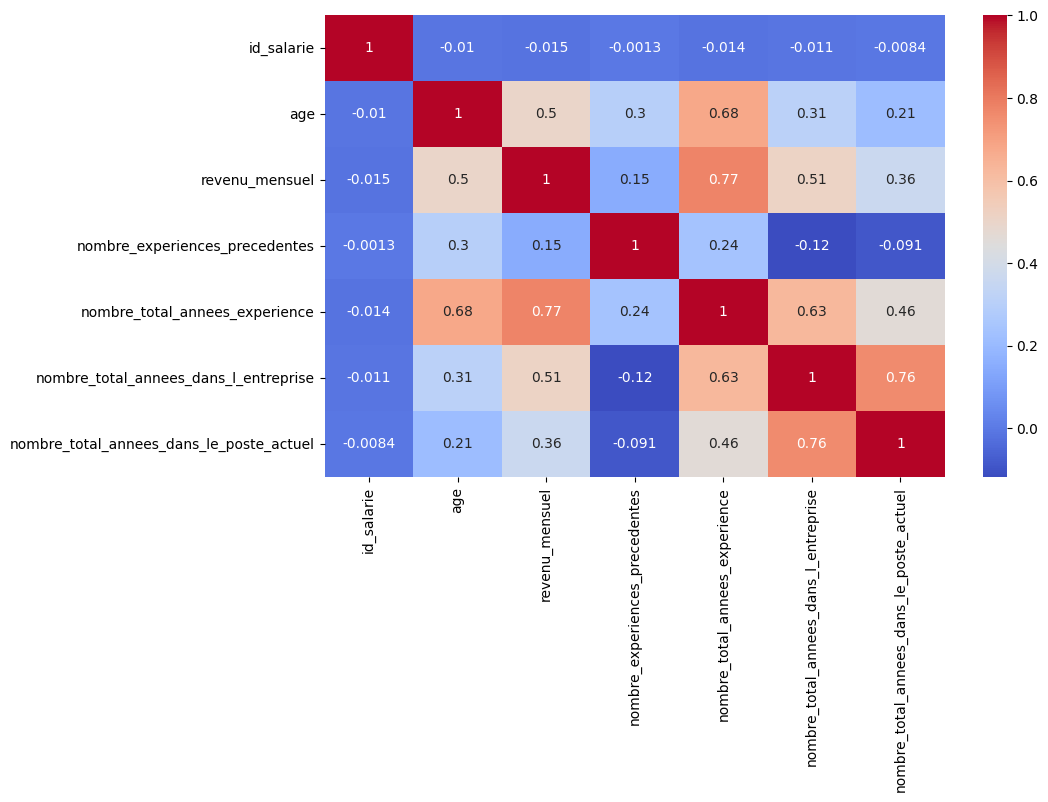

In [27]:
# Matrice globale des corrélations de df_sirh
plt.figure(figsize=(10,6))
sns.heatmap(df_sirh.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

#### observations
Les variables suivantes sont fortement corrélées entre elles:
* l'âge augmente avec l'expérience
* l'expérience augmente avec le salaire 
* l'ancienneté augmente sans nécessairement changer de poste (soit **faible mobilité interne pouvant expliquer les départs** soit **évolution lente**)

Ces variables corrélées amènent de la **multicolinéarité** qui peut rendre les **poids instables** et **l'interprétation biaisée** dans une modélisaiton de machine learning. Il faudra donc:
* soit garder l'âge
* soit garder l'expérience
* ou créer une feature “ratio salaire / expérience”

### Etape 1-2 : EDA du dataframe df_eval avant jointure

In [28]:
df_eval = pd.read_csv("../data/raw/extrait_eval.csv")

In [29]:
df_eval.head(3)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %


In [30]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [31]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_eval.rename(columns={
    "satisfaction_employee_environnement": "satisfaction_salarie_environnement",
    "satisfaction_employee_nature_travail": "satisfaction_salarie_nature_travail",
    "satisfaction_employee_equipe": "satisfaction_salarie_equipe",
    "satisfaction_employee_equilibre_pro_perso" : "satisfaction_salarie_equilibre_pro_perso",
    "eval_number" : "numero_d_evaluation",
    "heure_supplementaires" : "heures_supplementaires",
    "augementation_salaire_precedente" : "precedent_pourcentage_d_augmentation"  
}, inplace=True)

In [32]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   str  
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [33]:
int_cols_eval = df_eval.select_dtypes(include="int64").columns
print(int_cols_eval)

Index(['satisfaction_salarie_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_salarie_nature_travail',
       'satisfaction_salarie_equipe',
       'satisfaction_salarie_equilibre_pro_perso', 'note_evaluation_actuelle'],
      dtype='str')


In [34]:
for col in int_cols_eval:
    a_decimales = (df_eval[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

satisfaction_salarie_environnement a décimales ? False
note_evaluation_precedente a décimales ? False
niveau_hierarchique_poste a décimales ? False
satisfaction_salarie_nature_travail a décimales ? False
satisfaction_salarie_equipe a décimales ? False
satisfaction_salarie_equilibre_pro_perso a décimales ? False
note_evaluation_actuelle a décimales ? False


In [35]:
# Identification des colonnes type chaînes de caractères
string_cols_eval = df_eval.select_dtypes(include="str").columns
print(string_cols_eval)

Index(['numero_d_evaluation', 'heures_supplementaires',
       'precedent_pourcentage_d_augmentation'],
      dtype='str')


In [36]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_eval:
    print(df_eval[col].unique()) 

<ArrowStringArray>
[   'E_1',    'E_2',    'E_4',    'E_5',    'E_7',    'E_8',   'E_10',
   'E_11',   'E_12',   'E_13',
 ...
 'E_2054', 'E_2055', 'E_2056', 'E_2057', 'E_2060', 'E_2061', 'E_2062',
 'E_2064', 'E_2065', 'E_2068']
Length: 1470, dtype: str
<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str


In [37]:
df_sirh["id_salarie"].min(), df_sirh["id_salarie"].max()

(np.int64(1), np.int64(2068))

In [38]:
# Transformer les colonnes au format int64 
import re

df_eval["numero_d_evaluation"] = df_eval["numero_d_evaluation"].apply(
    lambda x: int(re.sub(r"\D", "", str(x)))
)

df_eval["heures_supplementaires"] = df_eval["heures_supplementaires"].apply(
    lambda x: str(x).strip().lower()
)

df_eval["precedent_pourcentage_d_augmentation"] = df_eval["precedent_pourcentage_d_augmentation"].apply(
    lambda x: int(re.sub(r"[^\d]", "", str(x)))
)

In [39]:
for col in string_cols_eval:
    print(df_eval[col].unique()) 

[   1    2    4 ... 2064 2065 2068]
<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
[11 23 15 12 13 20 22 21 17 14 16 18 19 24 25]


In [40]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [41]:
# Recherche de valeurs manquantes 
df_eval.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

satisfaction_salarie_environnement          0
note_evaluation_precedente                  0
niveau_hierarchique_poste                   0
satisfaction_salarie_nature_travail         0
satisfaction_salarie_equipe                 0
satisfaction_salarie_equilibre_pro_perso    0
numero_d_evaluation                         0
note_evaluation_actuelle                    0
heures_supplementaires                      0
precedent_pourcentage_d_augmentation        0
dtype: int64

In [42]:
# Contrôle présence de doublons sur la colonne numero_d_evaluation
df_eval["numero_d_evaluation"].duplicated().any()

np.False_

In [43]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [44]:
# Statistiques descriptives du dataframe df_eval
num_cols_eval = df_eval.select_dtypes(include="int64").columns
cat_cols_eval = df_eval.select_dtypes(include="str").columns
df_eval[num_cols_eval].describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_salarie_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
satisfaction_salarie_nature_travail,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equipe,1470.0,2.712245,1.081209,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equilibre_pro_perso,1470.0,2.761224,0.706476,1.0,2.00,3.0,3.00,4.0
numero_d_evaluation,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.0,3.00,3.0,3.00,4.0
precedent_pourcentage_d_augmentation,1470.0,15.209524,3.659938,11.0,12.00,14.0,18.00,25.0


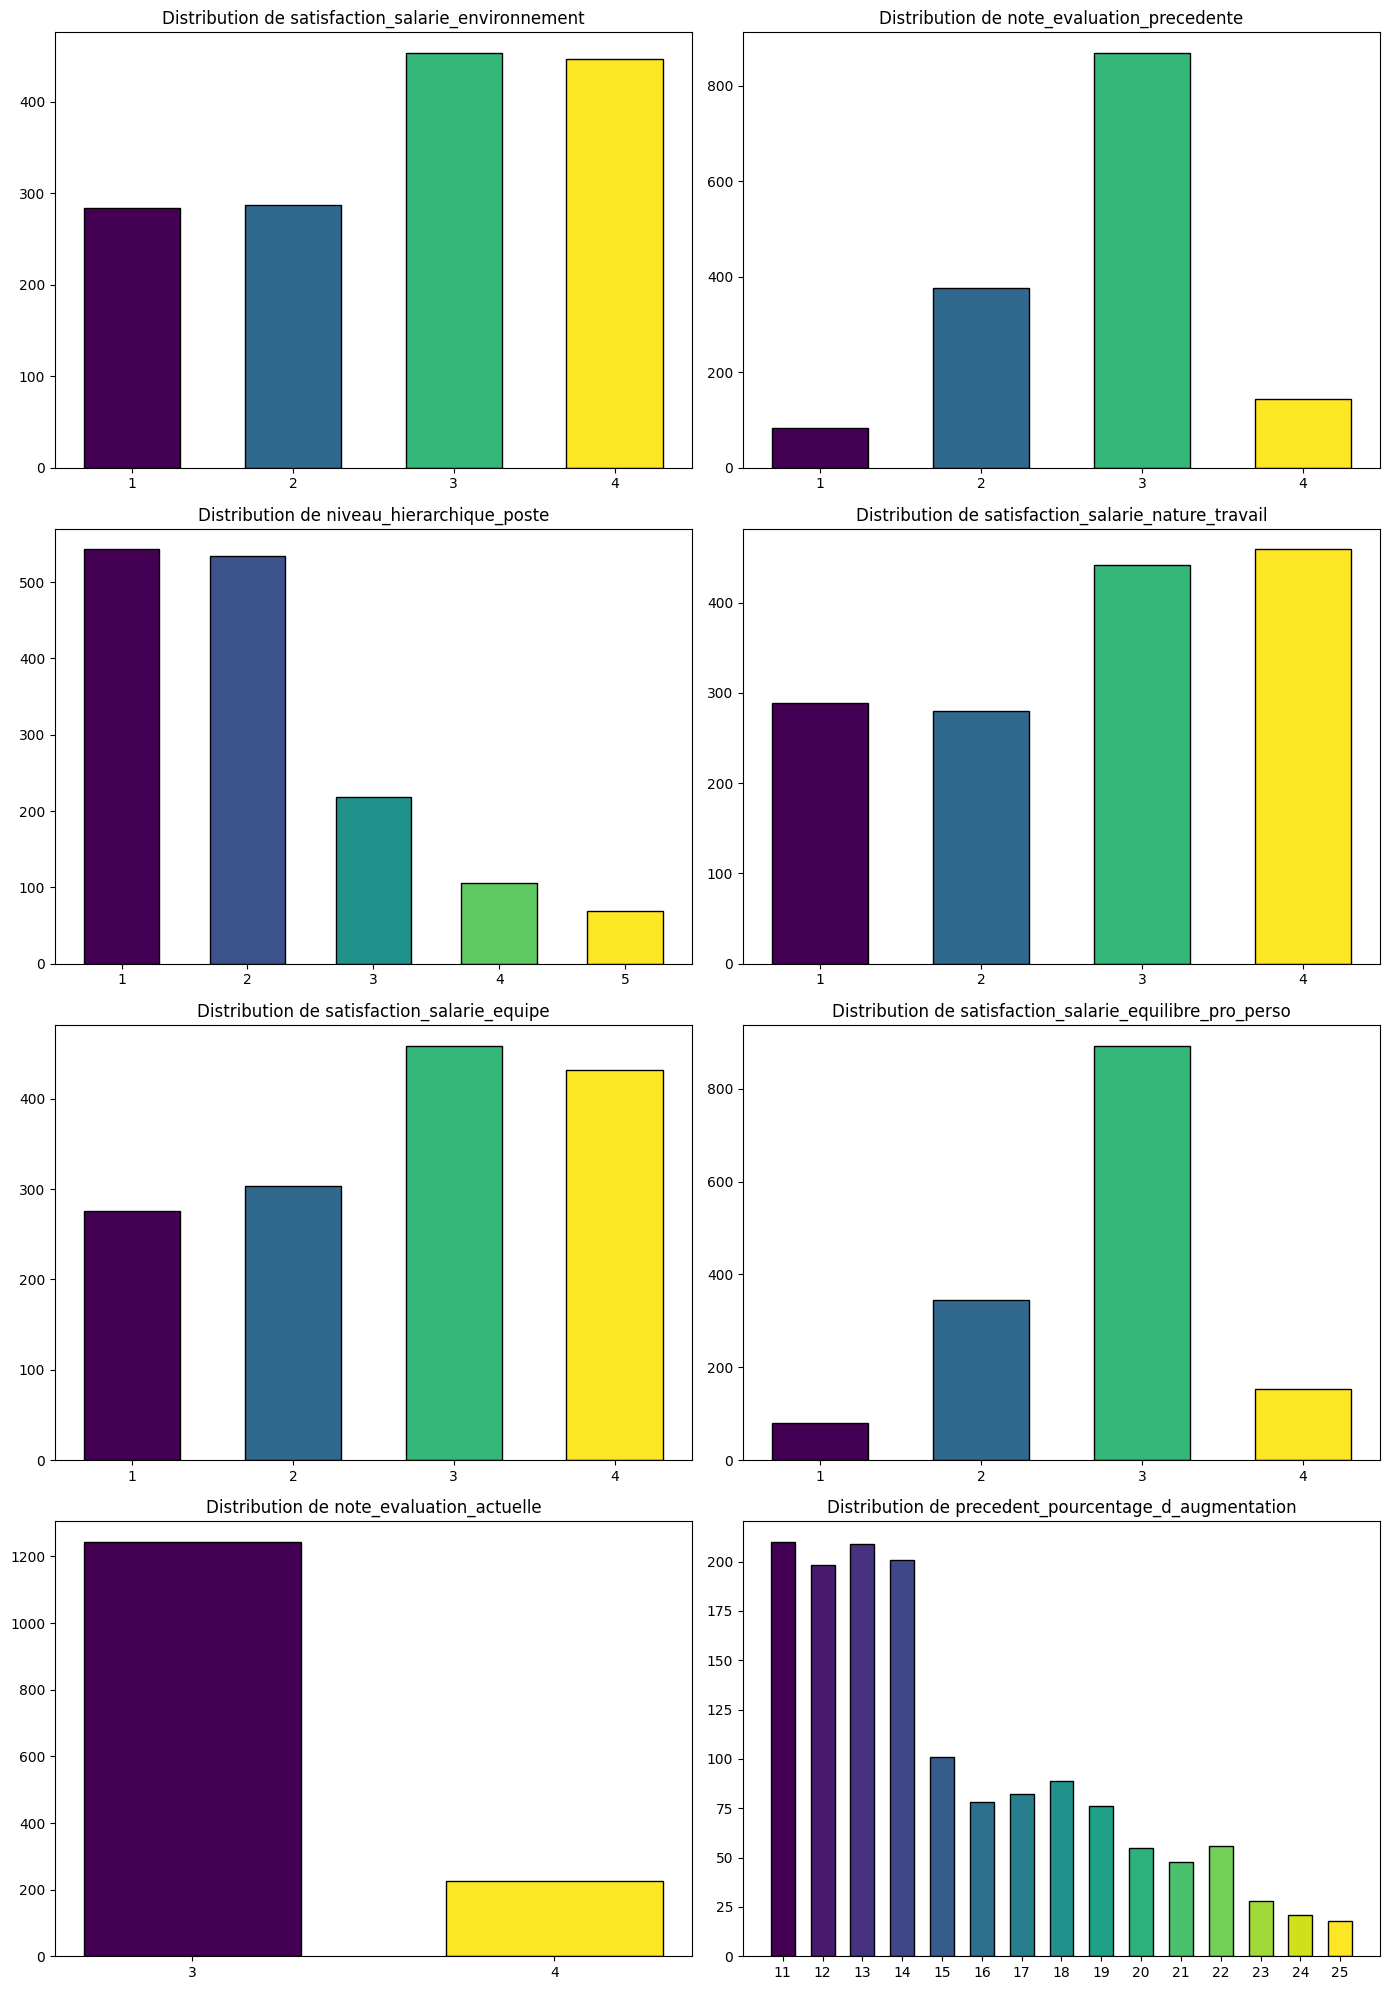

In [45]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

hierarchical_cols = ["niveau_hierarchique_poste"]
percent_cols = ["precedent_pourcentage_d_augmentation"]
exclude_cols = ["numero_d_evaluation"] 

# on retire la colonne du calcul
cols_to_plot = [col for col in num_cols_eval if col not in exclude_cols]

n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.ravel()

cmap = plt.cm.viridis

for i, col in enumerate(cols_to_plot):

    # cas niveau hiérarchique
    if col in hierarchical_cols:
        levels = sorted(df_eval[col].unique())

    # cas pourcentage augmentation
    elif col in percent_cols:
        levels = sorted(df_eval[col].unique())
        axes[i].set_xlim(min(levels) - 1, max(levels) + 1)

    # autres variables numériques
    else:
        levels = sorted(df_eval[col].unique())

    # normalisation couleurs
    norm = mcolors.Normalize(vmin=min(levels), vmax=max(levels))

    counts = df_eval[col].value_counts().reindex(levels, fill_value=0)

    colors = [cmap(norm(x)) for x in counts.index]

    axes[i].bar(
        counts.index,
        counts.values,
        width=0.6,
        edgecolor="black",
        color=colors
    )

    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xticks(levels)

# supprimer axes inutilisés
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

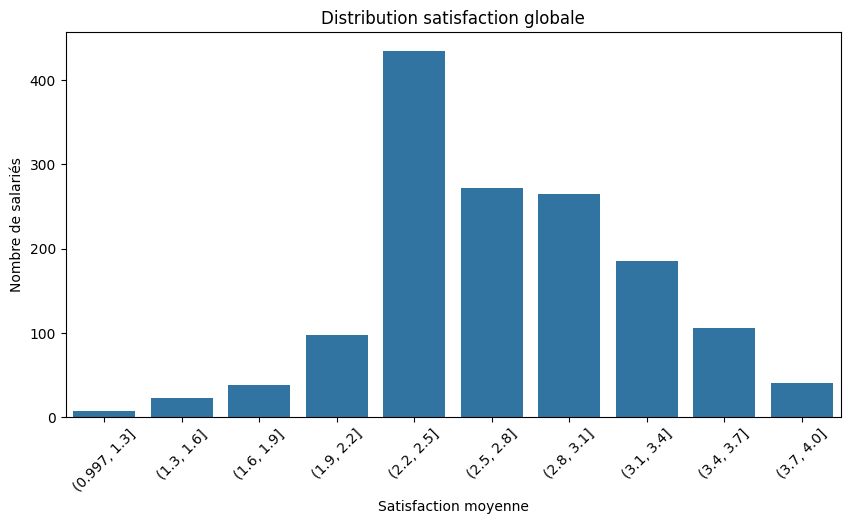

In [46]:

# création de la satisfaction moyenne
satisfaction_cols = [
    "satisfaction_salarie_environnement",
    "satisfaction_salarie_nature_travail",
    "satisfaction_salarie_equipe",
    "satisfaction_salarie_equilibre_pro_perso"
]

df_eval["satisfaction_moyenne"] = df_eval[satisfaction_cols].mean(axis=1)

# création des bins
df_eval["satisfaction_bin"] = pd.cut(
    df_eval["satisfaction_moyenne"],
    bins=10
)

# comptage par bin
bar_data = df_eval["satisfaction_bin"].value_counts().sort_index()

# barplot
plt.figure(figsize=(10,5))
sns.barplot(x=bar_data.index.astype(str), y=bar_data.values)

plt.xticks(rotation=45)
plt.title("Distribution satisfaction globale")
plt.xlabel("Satisfaction moyenne")
plt.ylabel("Nombre de salariés")

plt.show()

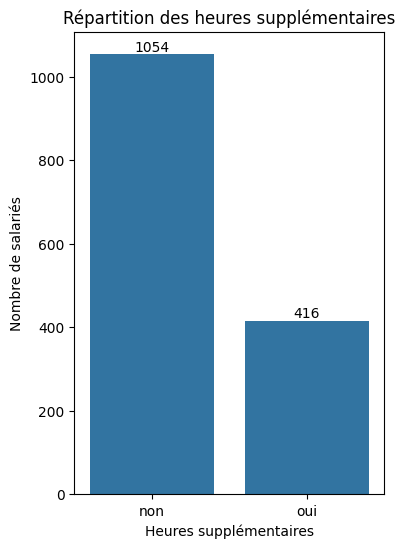

In [47]:
# distribution des heures supplémentaires

plt.figure(figsize=(4,6))

ax = sns.countplot(
    data=df_eval,
    x="heures_supplementaires",
    order=["non", "oui"] 
)

# titres
plt.title("Répartition des heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Nombre de salariés")

# ajout des valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container)

plt.show()

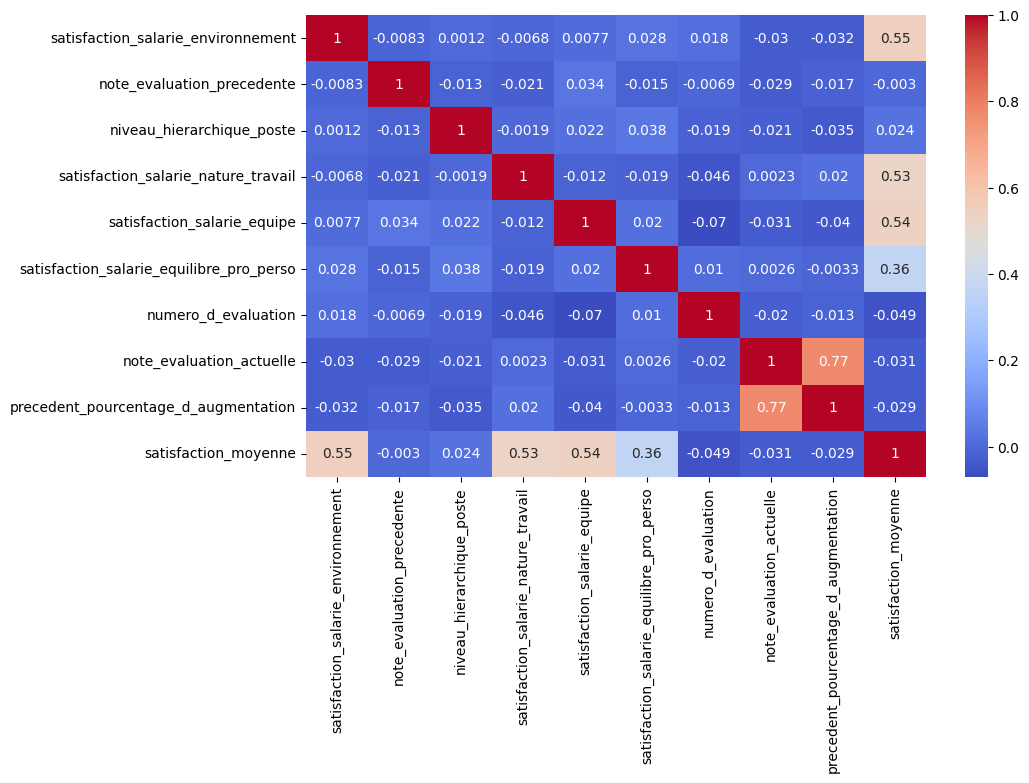

In [48]:
# matrice globale des corrélations de df_eval
plt.figure(figsize=(10,6))
sns.heatmap(df_eval.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

#### observations
* satisfaction globale moyenne mais pas excellente
* **peu de différenciation individuelle sur l'augmentation salariale**
* perception de l'environnement de travail globalement bonne mais pas homogène (400 personnes note 3 et 400 personnes note 4) **ce qui peut cacher des différences dans les différents départements de travail**
* le système de notation d'évaluation actuelle est peu discriminant par près de 80%  des salariés ont leur performance notée à 3. Or 400 salariés evaluent la satisfaction globale à 2 **ce qui montre que les salariés évaluent moins bien leur bien-être (pouvant causer des départs) que leur performance ce qui est synonyme de stress global**.
* 30% de l'effectif effectue des heures supplémentaires ce qui peut être source de stress
* **plus la note d’évaluation est élevée, plus le pourcentage d’augmentation est élevé**
* la note d’évaluation précédente n’a pas de corrélation linéaire simple avec la note actuelle (un salarié bien noté avant n’est pas forcément bien noté maintenant (et inversement)), **ce qui peut suggérer que les signaux de départ sont plutôt dans le contexte actuel que dans l’historique**


In [49]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   satisfaction_salarie_environnement        1470 non-null   int64   
 1   note_evaluation_precedente                1470 non-null   int64   
 2   niveau_hierarchique_poste                 1470 non-null   int64   
 3   satisfaction_salarie_nature_travail       1470 non-null   int64   
 4   satisfaction_salarie_equipe               1470 non-null   int64   
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64   
 6   numero_d_evaluation                       1470 non-null   int64   
 7   note_evaluation_actuelle                  1470 non-null   int64   
 8   heures_supplementaires                    1470 non-null   str     
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64   
 10  satisfaction_moyenne               

### Etape 1-3 : EDA du dataframe df_sondage avant jointure

In [50]:
df_sondage = pd.read_csv("../data/raw/extrait_sondage.csv")

In [51]:
df_sondage.head(3)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0


In [52]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [53]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sondage.rename(columns={
    "nb_formations_suivies" : "nombre_de_formations_suivies",
    "nombre_employee_sous_responsabilite" : "nombre_de_salaries_sous_sa_responsabilite",
    "annees_depuis_la_derniere_promotion" : "nombre_d_annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel" : "nombre_d_annees_sous_le_responsable_actuel"
}, inplace=True)

In [54]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [55]:
int_cols_sondage = df_sondage.select_dtypes(include="int64").columns
print(int_cols_sondage)

Index(['nombre_participation_pee', 'nombre_de_formations_suivies',
       'nombre_de_salaries_sous_sa_responsabilite', 'code_sondage',
       'distance_domicile_travail', 'niveau_education',
       'nombre_d_annees_depuis_la_derniere_promotion',
       'nombre_d_annees_sous_le_responsable_actuel'],
      dtype='str')


In [56]:
for col in int_cols_sondage:
    a_decimales = (df_sondage[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

nombre_participation_pee a décimales ? False
nombre_de_formations_suivies a décimales ? False
nombre_de_salaries_sous_sa_responsabilite a décimales ? False
code_sondage a décimales ? False
distance_domicile_travail a décimales ? False
niveau_education a décimales ? False
nombre_d_annees_depuis_la_derniere_promotion a décimales ? False
nombre_d_annees_sous_le_responsable_actuel a décimales ? False


In [57]:
# Identification des colonnes type chaînes de caractères
string_cols_sondage = df_sondage.select_dtypes(include="str").columns
print(string_cols_sondage)

Index(['a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants',
       'frequence_deplacement'],
      dtype='str')


In [58]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
[          'Infra & Cloud',                   'Autre',
 'Transformation Digitale',               'Marketing',
         'Entrepreunariat',     'Ressources Humaines']
Length: 6, dtype: str
<ArrowStringArray>
['Y']
Length: 1, dtype: str
<ArrowStringArray>
['Occasionnel', 'Frequent', 'Aucun']
Length: 3, dtype: str


In [59]:
# Recherche de valeurs manquantes 
df_sondage.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

a_quitte_l_entreprise                           0
nombre_participation_pee                        0
nombre_de_formations_suivies                    0
nombre_de_salaries_sous_sa_responsabilite       0
code_sondage                                    0
distance_domicile_travail                       0
niveau_education                                0
domaine_etude                                   0
ayant_enfants                                   0
frequence_deplacement                           0
nombre_d_annees_depuis_la_derniere_promotion    0
nombre_d_annees_sous_le_responsable_actuel      0
dtype: int64

In [60]:
# Retirer les majuscules, espaces, & et remplacer Y par oui
df_sondage[string_cols_sondage] = df_sondage[string_cols_sondage].apply(
    lambda col: col.astype(str)
    .str.strip()
    .str.lower()
    .str.replace("&", "et", regex=False)
    .str.replace(" ", "_", regex=False)
    .apply(lambda x: "oui" if x == "y" else x)
)

In [61]:
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
<ArrowStringArray>
[         'infra_et_cloud',                   'autre',
 'transformation_digitale',               'marketing',
         'entrepreunariat',     'ressources_humaines']
Length: 6, dtype: str
<ArrowStringArray>
['oui']
Length: 1, dtype: str
<ArrowStringArray>
['occasionnel', 'frequent', 'aucun']
Length: 3, dtype: str


In [62]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [63]:
df_sondage["code_sondage"].min(), df_sondage["code_sondage"].max()

(np.int64(1), np.int64(2068))

In [64]:
# Contrôle présence de doublons sur la colonne code_sondage
df_sondage["code_sondage"].duplicated().any()

np.False_

In [65]:
# statistiques descriptiques du dataframe df_sondage
df_sondage.describe().T

,count,mean,std,min,25%,50%,75%,max
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.00,1.0,1.00,3.0
nombre_de_formations_suivies,1470.0,2.799320,1.289271,0.0,2.00,3.0,3.00,6.0
nombre_de_salaries_sous_sa_responsabilite,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
code_sondage,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
niveau_education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
nombre_d_annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.00,1.0,3.00,15.0
nombre_d_annees_sous_le_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.00,3.0,7.00,17.0


#### observations 
- Le nombre de salaries sous sa responsaiblité est toujours égal à 1 donc pas de variabilité dans les données, la colonne pourra être retirée du dataframe.

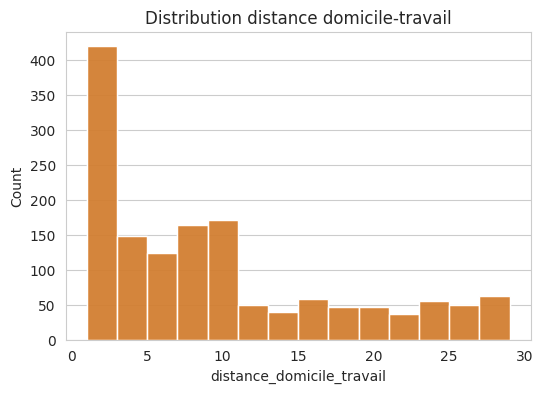

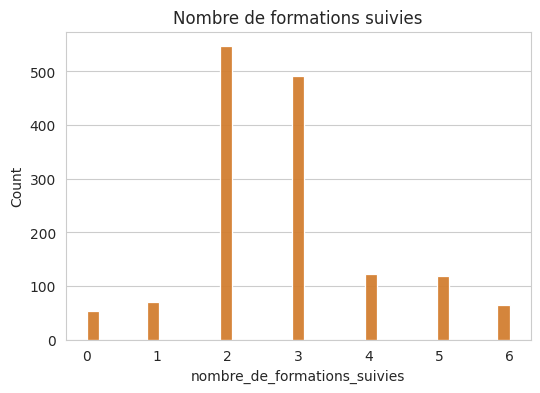

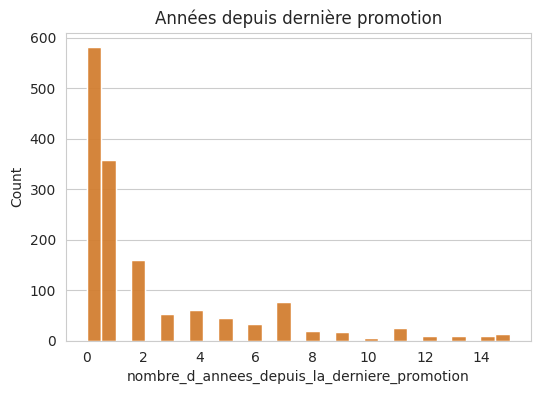

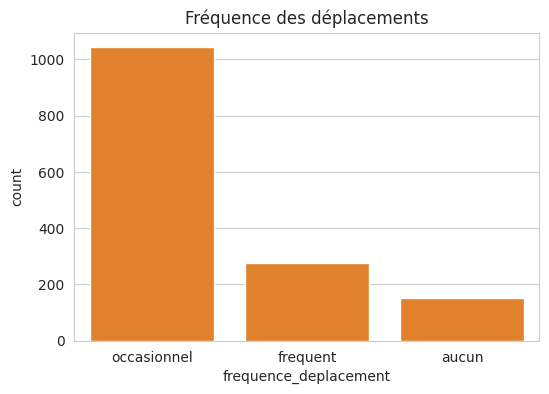

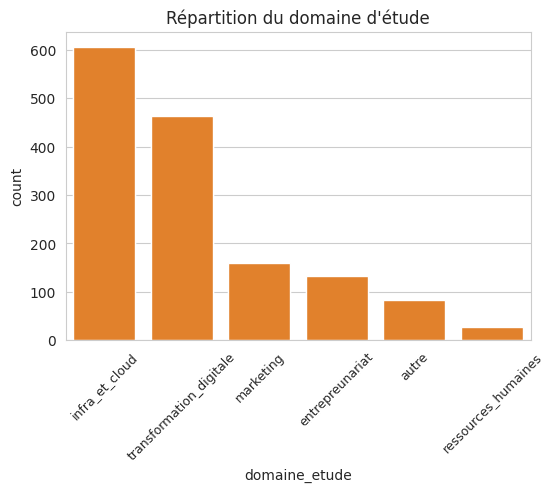

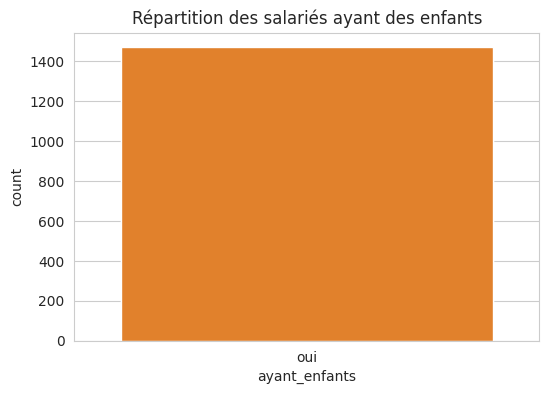

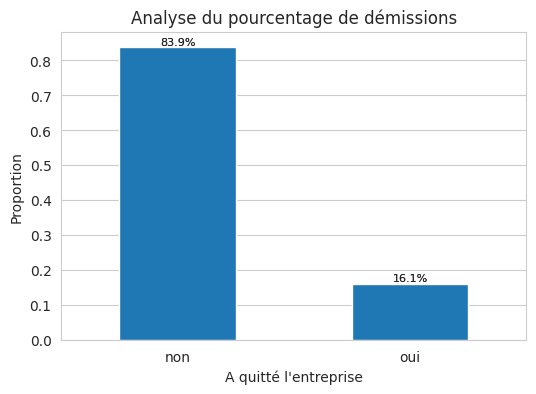

In [66]:
# Visualisations univariées

sns.set_style("whitegrid", {'axes.grid.axis': 'y'})
plt.rcParams["figure.figsize"] = (6, 4)

# Distance domicile-travail
sns.histplot(df_sondage["distance_domicile_travail"], kde=False)
ax = sns.histplot(df_sondage["distance_domicile_travail"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Distribution distance domicile-travail")
plt.show()

# Formations suivies
sns.histplot(df_sondage["nombre_de_formations_suivies"], kde=False)
ax = sns.histplot(df_sondage["nombre_de_formations_suivies"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Nombre de formations suivies")
plt.show()

# Années depuis dernière promotion
sns.histplot(df_sondage["nombre_d_annees_depuis_la_derniere_promotion"], kde=False)
ax = sns.histplot(df_sondage["nombre_d_annees_depuis_la_derniere_promotion"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Années depuis dernière promotion")
plt.show()

# Fréquence des déplacements
sns.countplot(data=df_sondage, x="frequence_deplacement")
ax = sns.countplot(data=df_sondage, x="frequence_deplacement")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Fréquence des déplacements")
plt.show()

# Domaine d'étude 
sns.countplot(data=df_sondage, x="domaine_etude", order=df_sondage["domaine_etude"].value_counts().index)
ax = sns.countplot(data=df_sondage, x="domaine_etude", order=df_sondage["domaine_etude"].value_counts().index)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Répartition du domaine d'étude")
plt.xticks(rotation=45, ha="center", fontsize=9)
plt.show()

# Ayant enfants
sns.countplot(data=df_sondage, x="ayant_enfants")
ax = sns.countplot(data=df_sondage, x="ayant_enfants")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Répartition des salariés ayant des enfants")
plt.show()

# a quitté l'entreprise (variable cible potentielle)
plt.figure()

(df_sondage["a_quitte_l_entreprise"]
 .value_counts(normalize=True)
 .sort_index()
 .plot(kind="bar"))

ax = (df_sondage["a_quitte_l_entreprise"]
      .value_counts(normalize=True)
      .sort_index()
      .plot(kind="bar"))

# ajout des labels directement
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=8)

ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)

plt.title("Analyse du pourcentage de démissions")
plt.ylabel("Proportion")
plt.xlabel("A quitté l'entreprise")
plt.xticks(rotation=0)

plt.show()


In [67]:
# Analyse de la variable cible a_quitte_l_entreprise
df_sondage["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
non    0.838776
oui    0.161224
Name: proportion, dtype: float64

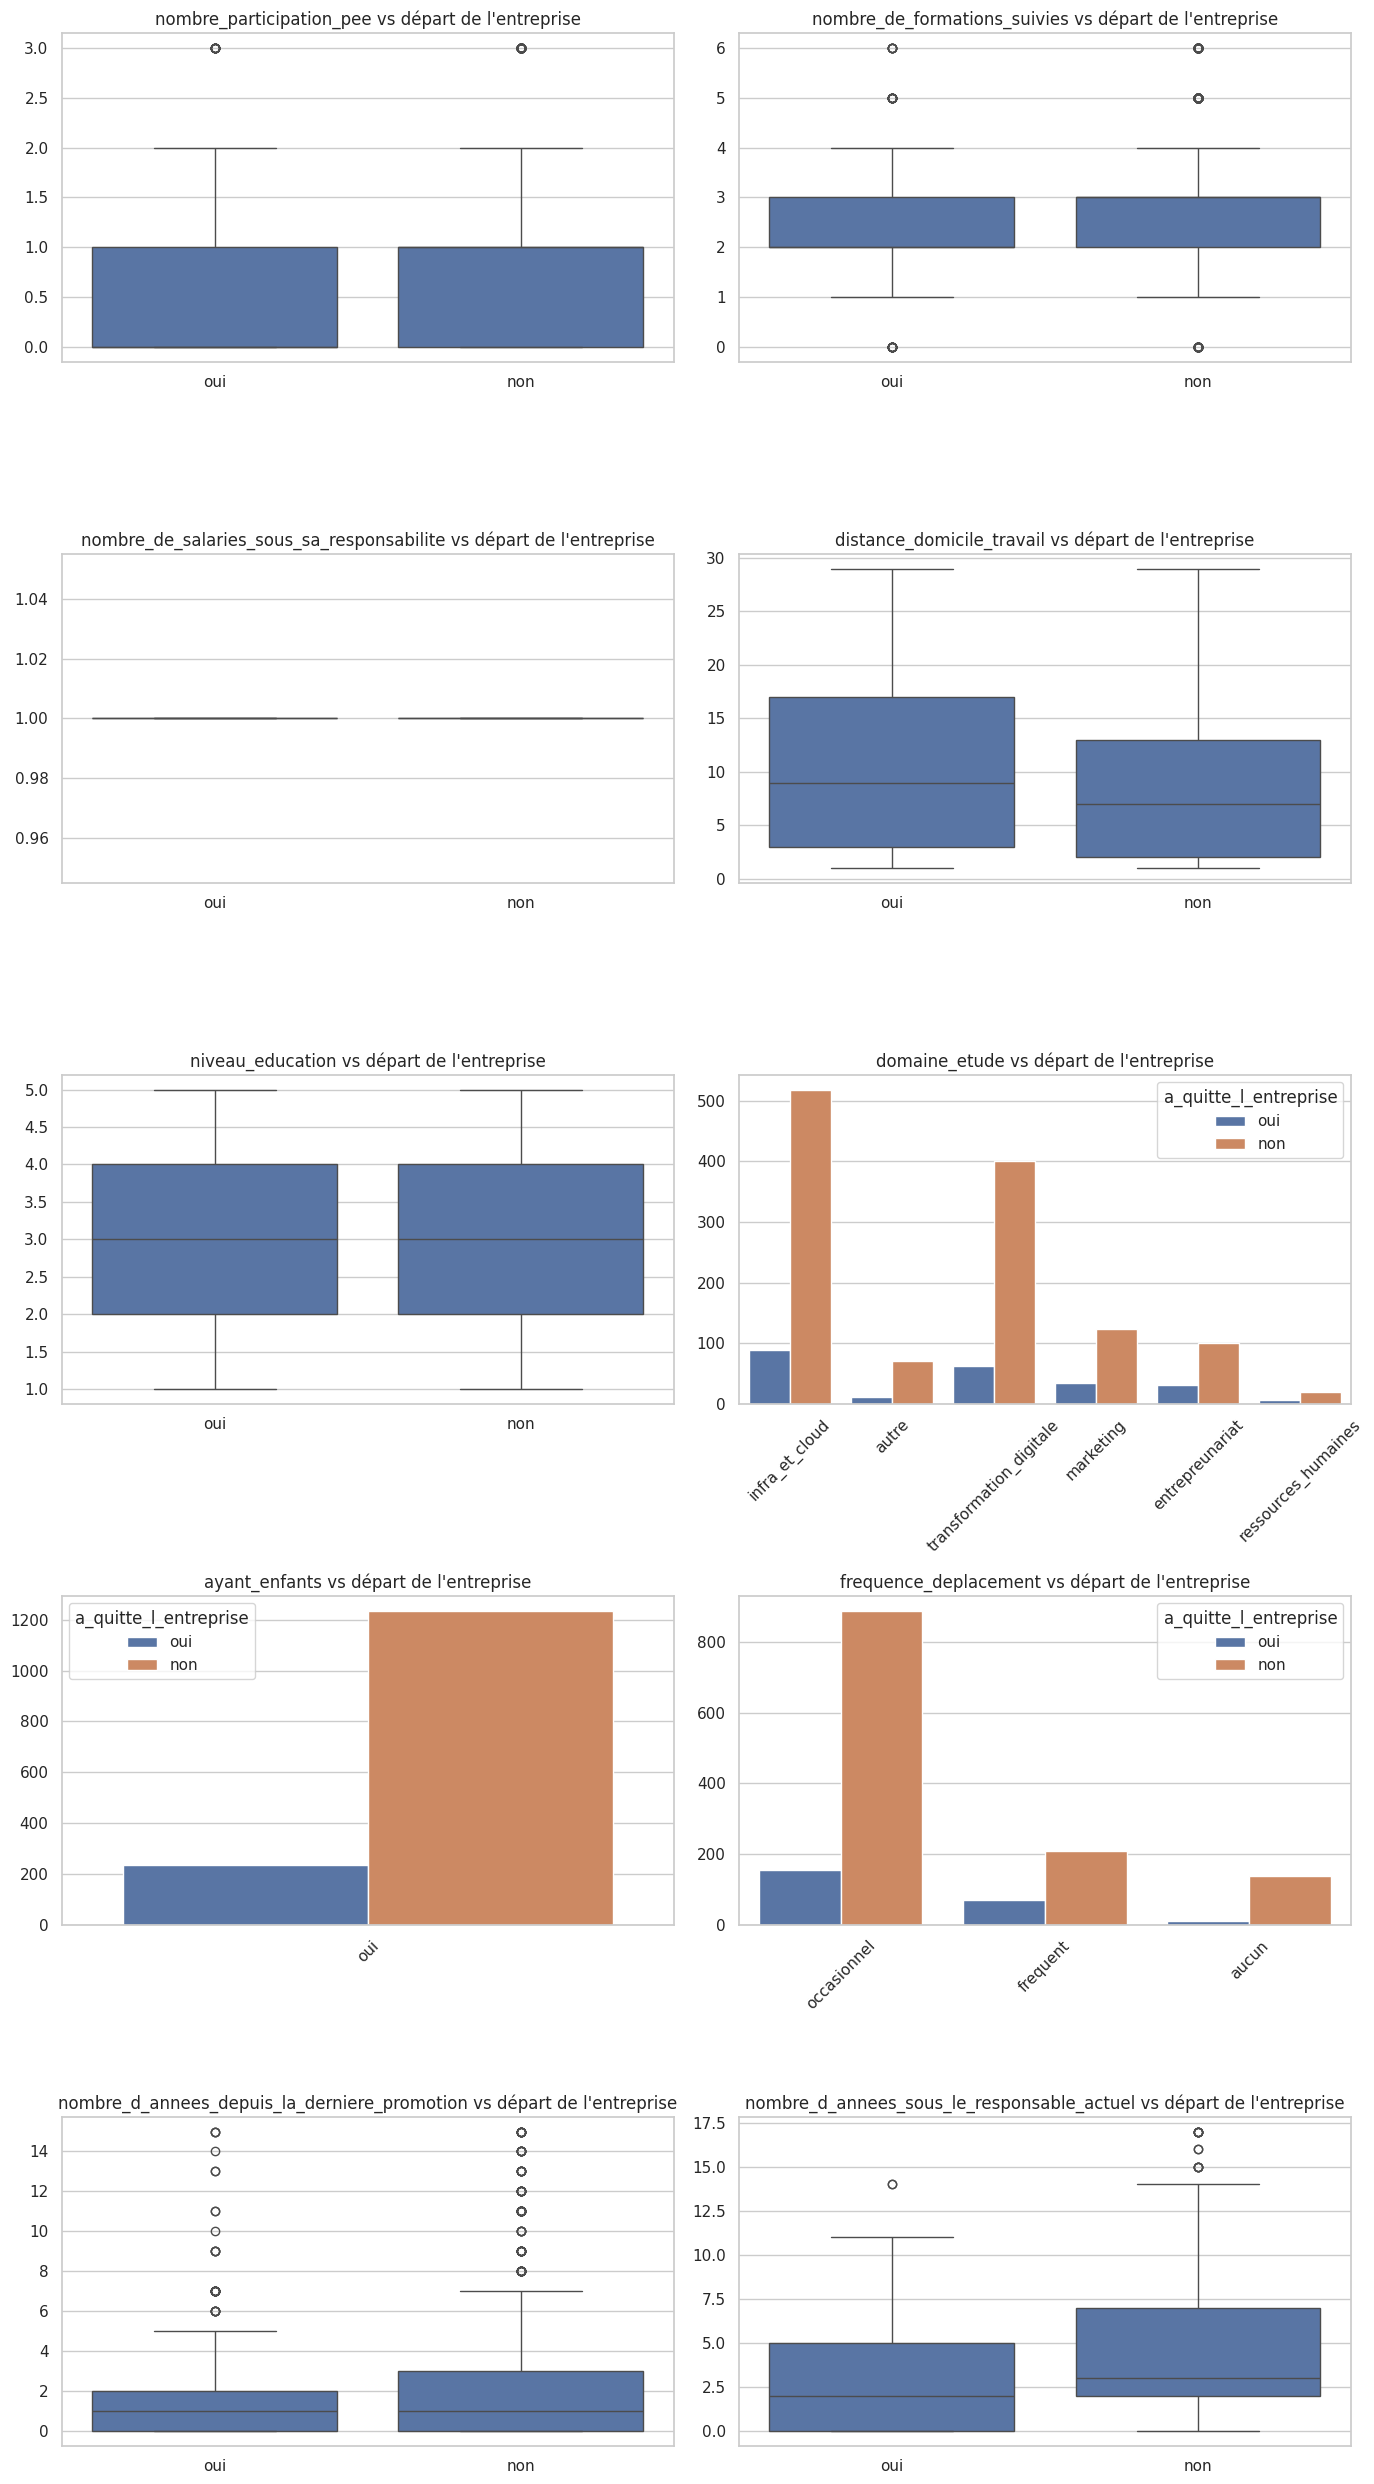

In [68]:
# visualisaitons bivariees
import math

sns.set(style="whitegrid")

cols = [
    "nombre_participation_pee",
    "nombre_de_formations_suivies",
    "nombre_de_salaries_sous_sa_responsabilite",
    "distance_domicile_travail",
    "niveau_education",
    "domaine_etude",
    "ayant_enfants",
    "frequence_deplacement",
    "nombre_d_annees_depuis_la_derniere_promotion",
    "nombre_d_annees_sous_le_responsable_actuel"
]

n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):

    # Cas variables numériques
    if df_sondage[col].dtype == "int64":
        sns.boxplot(
            data=df_sondage,
            x="a_quitte_l_entreprise",
            y=col,
            ax=axes[i]
        )
    
    # Cas variables catégorielles
    else:
        sns.countplot(
            data=df_sondage,
            x=col,
            hue="a_quitte_l_entreprise",
            ax=axes[i]
        )
        axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f"{col} vs départ de l'entreprise")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# supprimer axes inutilisés
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### observations
* **la colonne ayant enfants pourra être retirée du dataframe** car la réponse est toujours oui, donc la variable n'apportera pas d'informations
* population plutôt proche du lieu de travail, **peu de contrainte géographique globale**
* **politique de formation active** (1000 salaries ont suivi entre 2 et 3 formations), faible dispersion des valeurs dans la boxplot
* promotions récentes nombreuses
* **déplacements assez présents** ce qui peut être facteur potentiel de fatigue puis de départ de l'entreprise
* population technique dominante
* **le dataset présente un déséquilibre de classes significatif sur la variable cible**, ce qui nécessitera des techniques adaptées (pondération, rééchantillonnage avec undersampling) lors de la modélisation machine learning
* **davantage de départs dans le domaine “infra & cloud”** (profils très demandés, stress, sous-payé par rapport au marché)
* **population majoritairement technique** (domaine infra & cloud), avec une forte concentration des départs dans ce segment 
* **les salariés présentent une ancienneté faible depuis leur dernière promotion** et une fréquence de déplacement majoritairement occasionnelle
* **le déséquilibre de classes (16% de départs) devra être pris en compte dans les étapes de modélisation**

In [69]:
df_sondage.drop(
    columns=[
        "ayant_enfants",
        "nombre_de_salaries_sous_sa_responsabilite"
    ],
    inplace=True
)
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   code_sondage                                  1470 non-null   int64
 4   distance_domicile_travail                     1470 non-null   int64
 5   niveau_education                              1470 non-null   int64
 6   domaine_etude                                 1470 non-null   str  
 7   frequence_deplacement                         1470 non-null   str  
 8   nombre_d_annees_depuis_la_derniere_promotion  1470 non-null   int64
 9   nombre_d_annees_sous_le_responsable_actuel    1470 non-null   int64
dtypes: int64(7), str(3)
mem

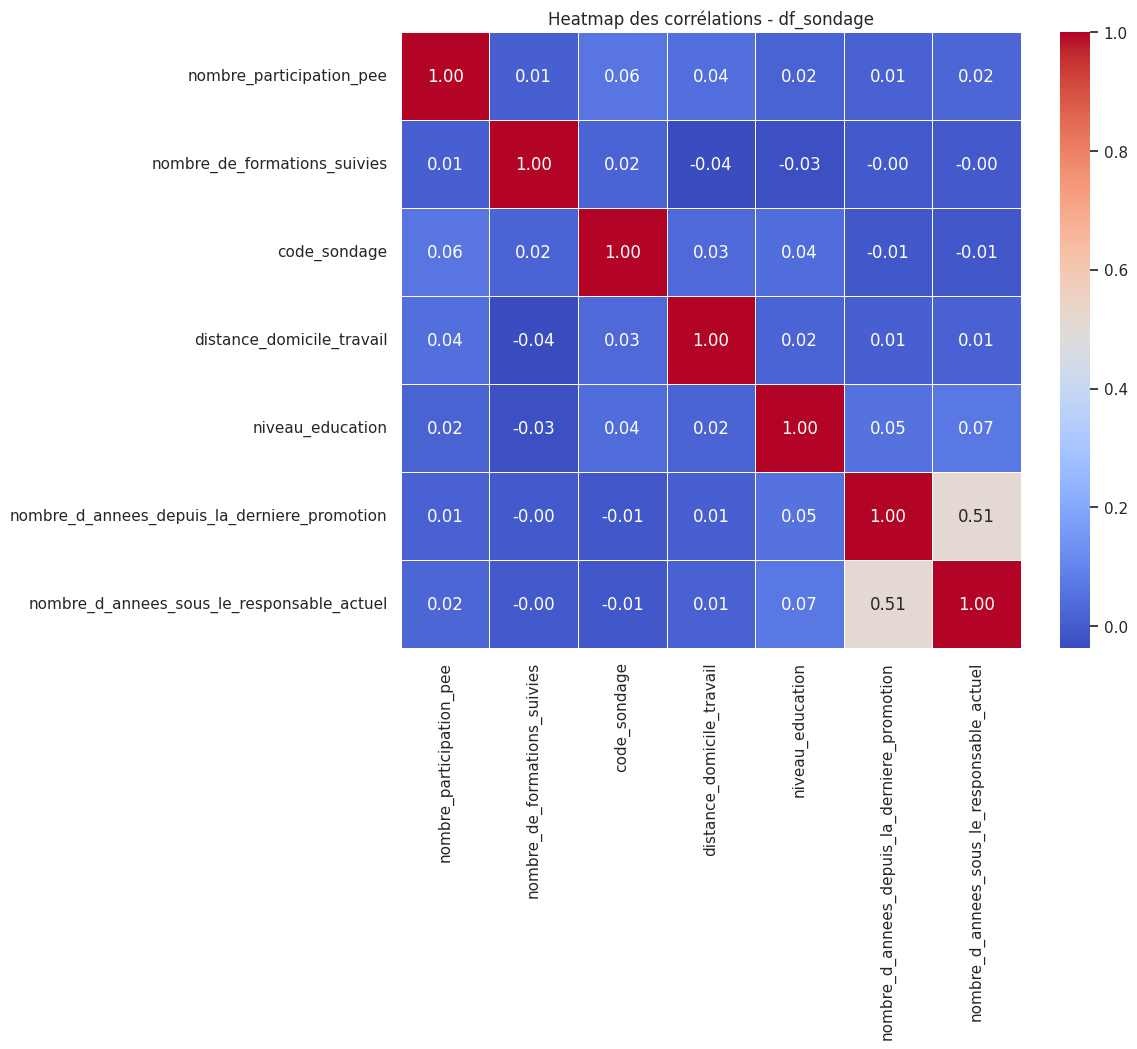

In [70]:
# Matrice globale des corrélations de df_sondage
# sélection des colonnes numériques
num_cols_sondage = df_sondage.select_dtypes(include="int64")

# matrice de corrélation
corr_matrix = num_cols_sondage.corr()

# heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap des corrélations - df_sondage")
plt.show()

#### observations
- Une corrélation modérée (0.51) entre le nombre d’années depuis la dernière promotion et l’ancienneté avec le responsable actuel suggère que **les salariés restés longtemps sous le même management ont tendance à connaître une progression de carrière plus lente, ce qui peut refléter une certaine stagnation professionnelle**. Ceci peut être une motivation pour quitter l'entreprise.

### Etape 1-4 : Réalisation de la jointure pour réunir les 3 dataframes 

In [71]:
# Réalisation de la jointure pour réunir les trois dataframes

df_sirh = df_sirh.rename(columns={"id_salarie": "id"})
df_eval = df_eval.rename(columns={"numero_d_evaluation": "id"})
df_sondage = df_sondage.rename(columns={"code_sondage": "id"})

df_joint = (
    df_sirh
    .merge(df_eval, on="id", how="inner")
    .merge(df_sondage, on="id", how="inner")
    .sort_values(by="id")
    .reset_index(drop=True)
)

In [72]:
# Contrôle dimensions du dataframe obtenu et de l'absence de doublons
print("Shape finale :", df_joint.shape)
print("Doublons :", df_joint.duplicated().sum())

Shape finale : (1470, 31)
Doublons : 0


In [73]:
df_joint.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   id                                            1470 non-null   int64   
 1   age                                           1470 non-null   int64   
 2   genre                                         1470 non-null   str     
 3   revenu_mensuel                                1470 non-null   int64   
 4   statut_marital                                1470 non-null   str     
 5   departement                                   1470 non-null   str     
 6   poste                                         1470 non-null   str     
 7   nombre_experiences_precedentes                1470 non-null   int64   
 8   nombre_total_annees_experience                1470 non-null   int64   
 9   nombre_total_annees_dans_l_entreprise         1470 non-null   i

### Etape 1-5 : EDA sur le dataframe obtenu df_joint

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

In [75]:
df_joint.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1470.0,1024.865306,602.024335,1.0,491.25,1020.50,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.00,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.00,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.00,4.00,9.0
nombre_total_annees_experience,1470.0,11.279592,7.780782,0.0,6.00,10.00,15.00,40.0
nombre_total_annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.00,9.00,40.0
nombre_total_annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.00,7.00,18.0
satisfaction_salarie_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.00,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.00,3.00,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.00,2.00,3.00,5.0


In [76]:
# Fonctions python pour l'EDA sur le dataframe df_joint issu de la jointure

def eda_univariee(df, num_cols=None, cat_cols=None):
    """Visualisations univariées pour les colonnes numériques et catégorielles"""
    if num_cols is None:
        num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    if cat_cols is None:
        cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Numériques
    for col in num_cols:
        sns.histplot(df[col], kde=False)
        plt.title(f"Distribution de {col}")
        plt.show()
    
    # Catégorielles
    for col in cat_cols:
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Répartition de {col}")
        plt.show()


def eda_bivariee(df, target_col, num_cols=None, cat_cols=None):
    """Visualisations bivariées entre features et la cible"""
    if num_cols is None:
        num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    if cat_cols is None:
        cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Numériques vs cible
    for col in num_cols:
        plt.figure(figsize=(8,5))
        sns.boxplot(x=df[target_col], y=df[col])
        
        plt.title(f"{col} selon {target_col}", fontsize=14)
        plt.xlabel(target_col, fontsize=12)
        plt.ylabel(col, fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        plt.show()
    
    # Catégorielles vs cible
    for col in cat_cols:
        plt.figure(figsize=(8,5))
        sns.countplot(x=col, hue=target_col, data=df)
        
        plt.title(f"{col} selon {target_col}", fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks(fontsize=10, rotation=45)
        plt.yticks(fontsize=10)
        
        plt.legend(title=target_col, fontsize=10, title_fontsize=11)
        
        plt.show()

def correlation_heatmap(df, method="pearson"):
    """
    - method="pearson" : variables normalement distribuées
    - method="spearman": variables non normales ou discrètes
    """
    if method == "pearson":
        cols = [
            "age"  
        ]
    elif method == "spearman":
        cols = [
            "revenu_mensuel",
            "nombre_total_annees_experience",
            "nombre_total_annees_dans_l_entreprise",
            "nombre_total_annees_dans_le_poste_actuel",
            "satisfaction_moyenne",
            "nombre_experiences_precedentes",
            "satisfaction_salarie_environnement",
            "note_evaluation_precedente",
            "niveau_hierarchique_poste",
            "satisfaction_salarie_nature_travail",
            "satisfaction_salarie_equipe",
            "satisfaction_salarie_equilibre_pro_perso",
            "note_evaluation_actuelle",
            "precedent_pourcentage_d_augmentation",
            "nombre_participation_pee",
            "nombre_de_formations_suivies",
            "distance_domicile_travail",
            "niveau_education",
            "nombre_d_annees_depuis_la_derniere_promotion",
            "nombre_d_annees_sous_le_responsable_actuel"
        ]
    else:
        raise ValueError("Méthode doit être 'pearson' ou 'spearman'")

    plt.figure(figsize=(20,18)) 

    sns.heatmap(
    df[cols].corr(method=method),
    annot=True,           
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8},  
    linewidths=0.8          
)

    plt.title(f"Matrice de corrélation ({method})", fontsize=16)
    plt.xticks(fontsize=10, rotation=90)  
    plt.yticks(fontsize=10, rotation=0)  
    plt.tight_layout()                     
    plt.show()


def pairplot_sample(df, cols, target_col, sample_size=500):
    """Pairplot pour un sous-échantillon de lignes de df_joint"""
    # Sous-échantillon
    if len(df) > sample_size:
        df_sample = df.sample(sample_size, random_state=42)
    else:
        df_sample = df

    # Style et taille globale
    sns.set_context("notebook", font_scale=0.8)  
    g = sns.pairplot(
        df_sample[cols + [target_col]],
        hue=target_col,
        diag_kind="kde",
        height=3.5,    
        aspect=1.2    
    )

    for ax in g.axes.flatten():
        if ax is not None:
            ax.xaxis.label.set_fontweight('bold')
            ax.yaxis.label.set_fontweight('bold')

    # Mettre la légende en gras
    if g._legend is not None:
        for text in g._legend.get_texts():
            text.set_fontweight('bold')

    # Ajuster l'espacement
    plt.subplots_adjust(top=0.95)
    plt.show()

In [80]:
# Fonctions python pour préparer les features X et la target y à partir de df_joint

def prepare_features(df, target_col):
    """
    Prépare X et y pour sklearn :
    - encode la cible en binaire
    - sépare features numériques et catégorielles
    - encode les catégorielles avec OneHotEncoder
    """
    # Cible
    y = df[target_col].map({"Oui":1, "Non":0})  # ajuster selon vos valeurs

    # Features
    X = df.drop(columns=[target_col, "id"])  # on enlève id et cible

    # Colonnes catégorielles
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    # OneHotEncoding
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X_encoded, y

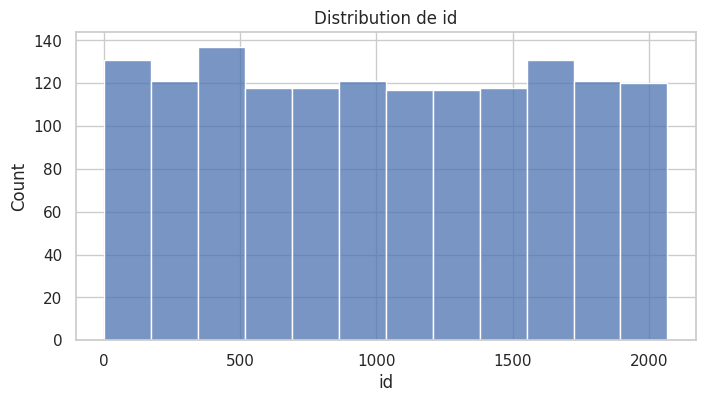

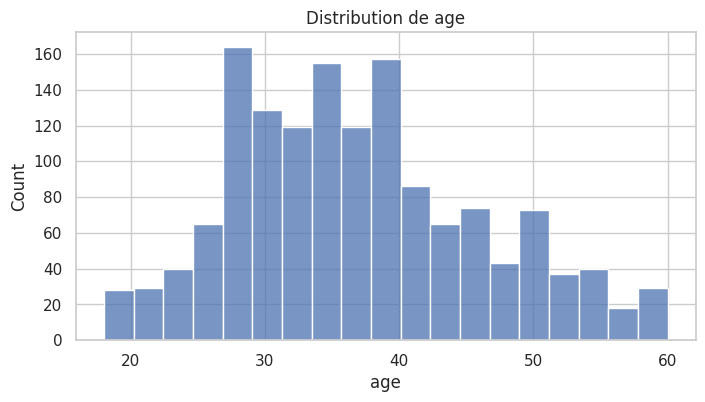

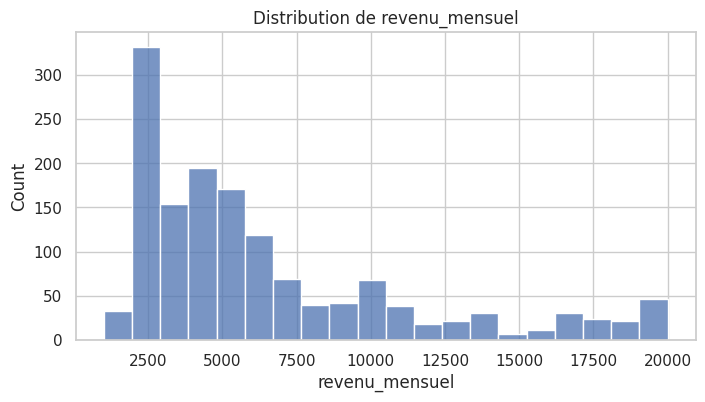

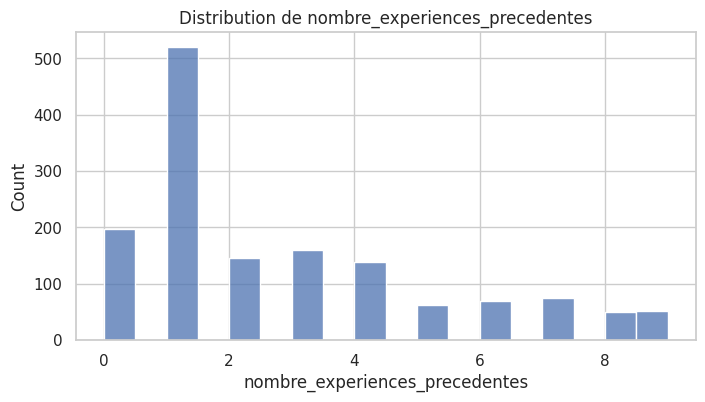

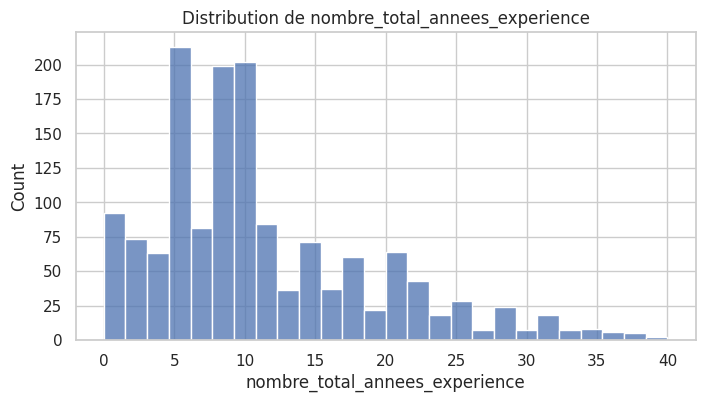

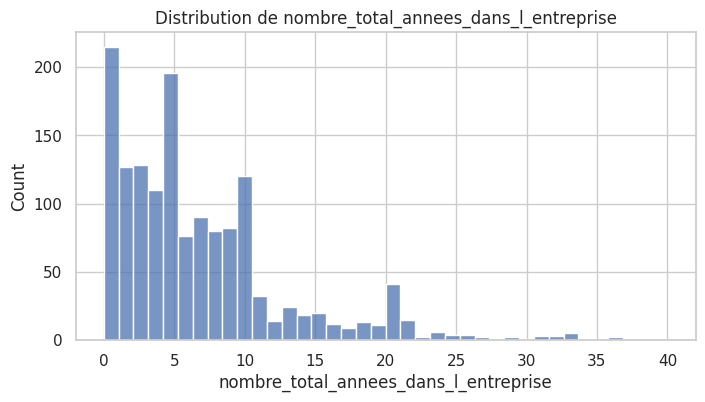

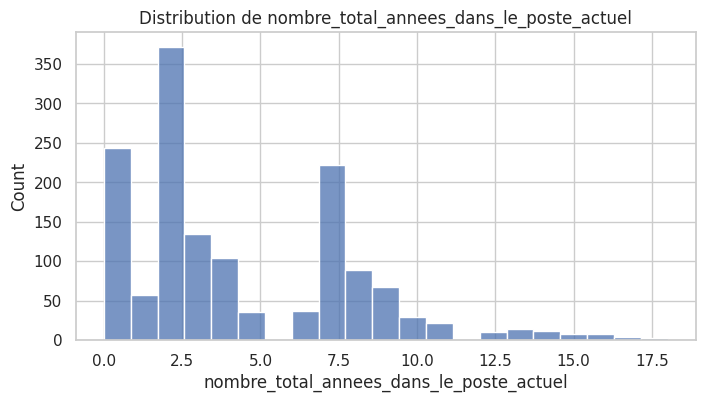

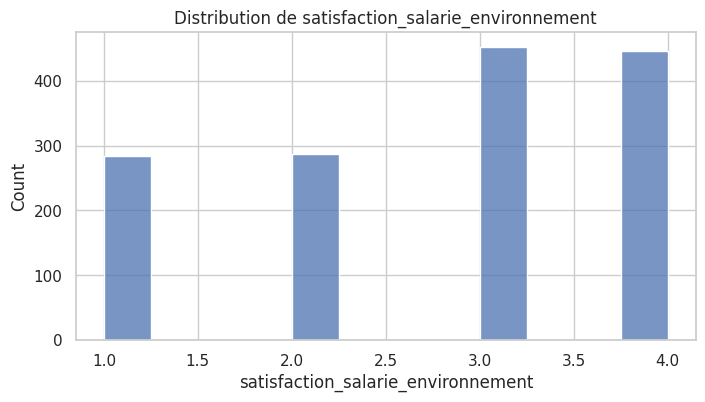

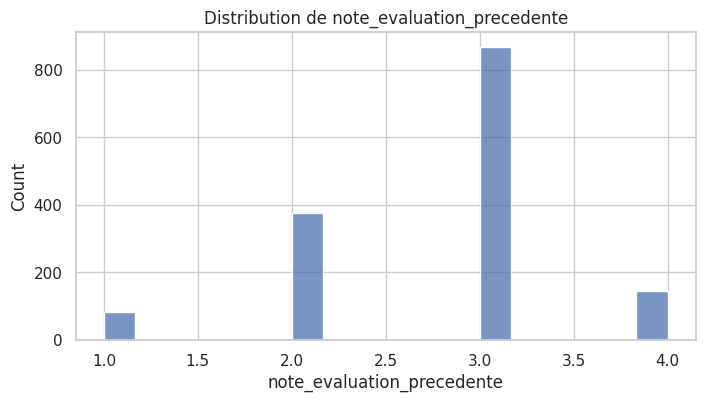

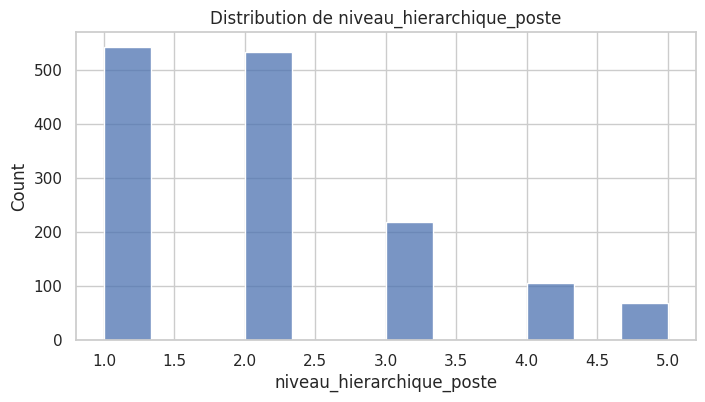

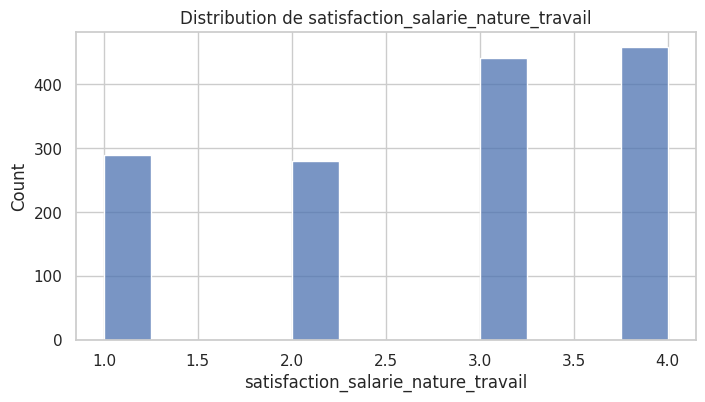

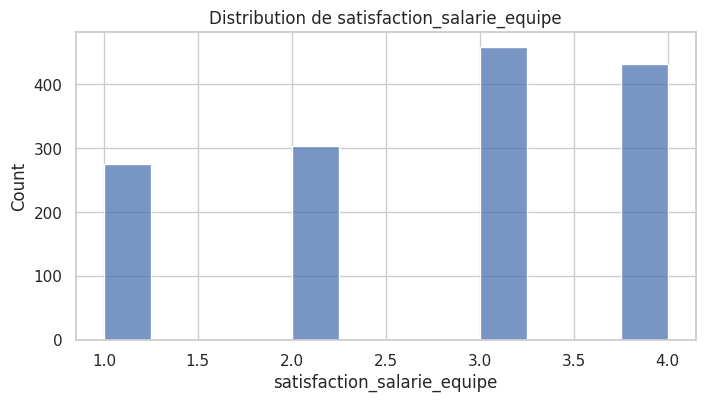

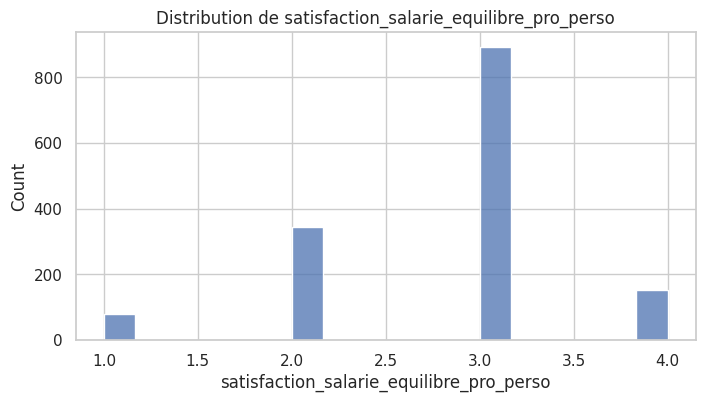

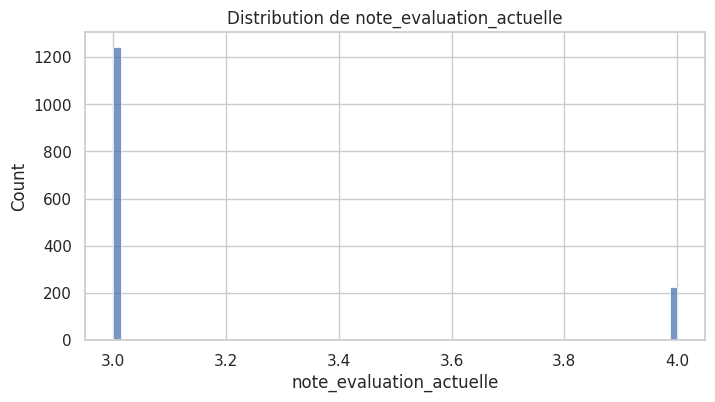

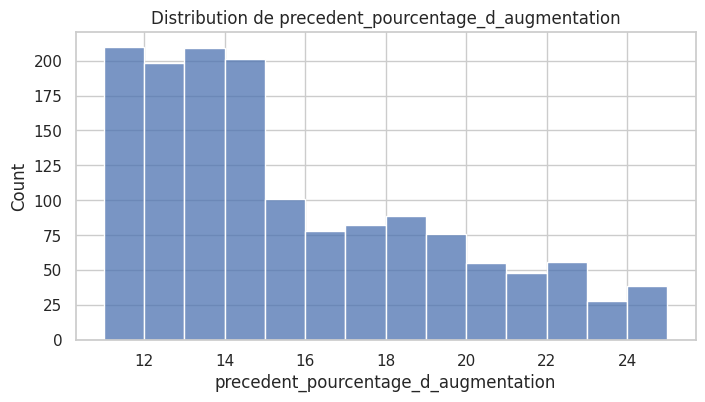

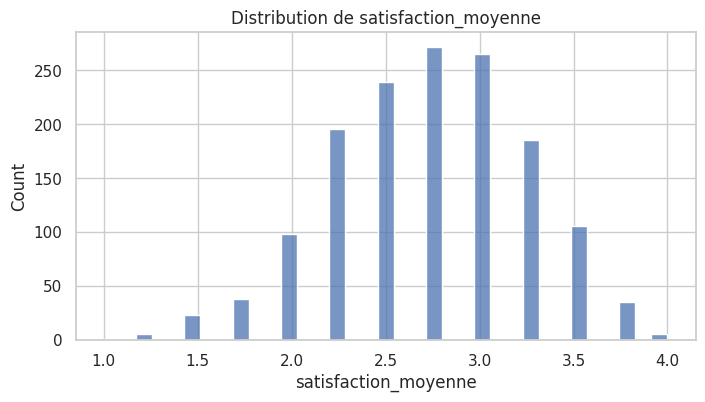

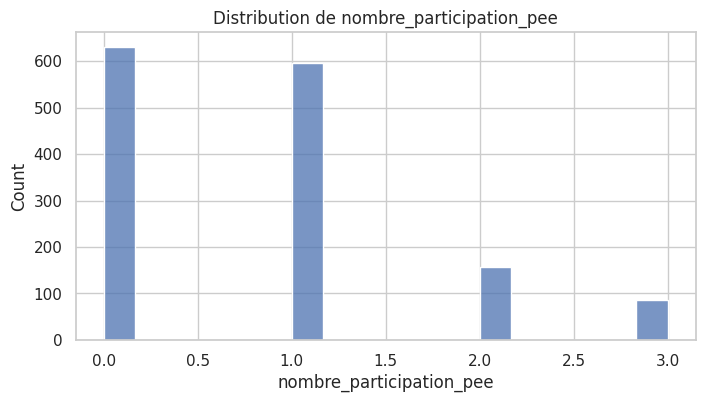

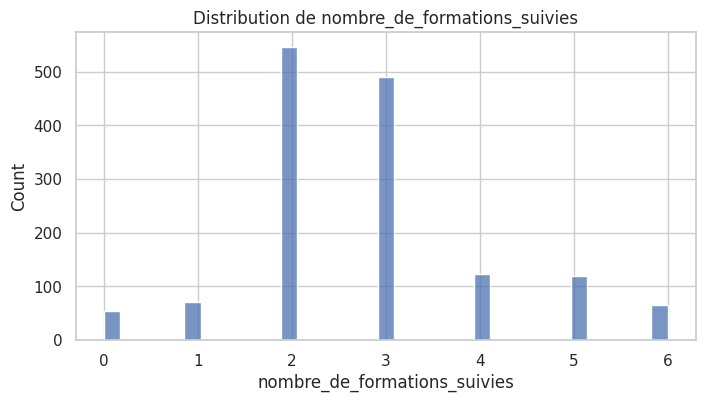

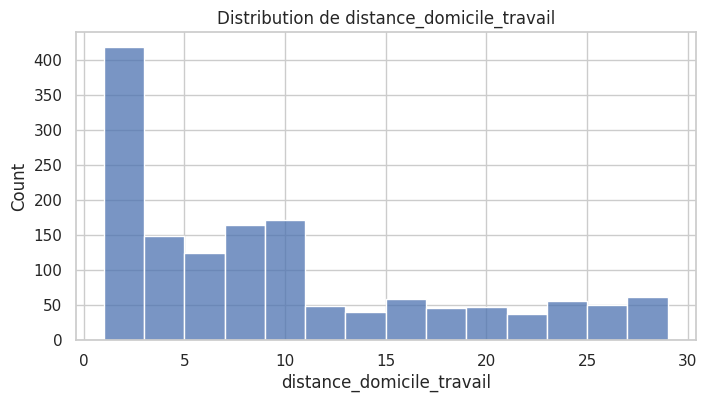

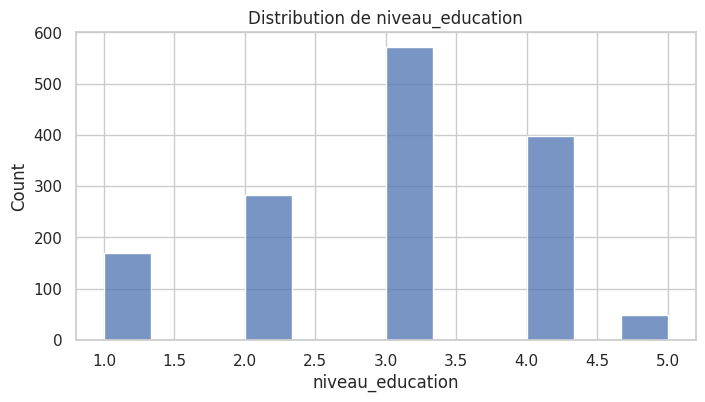

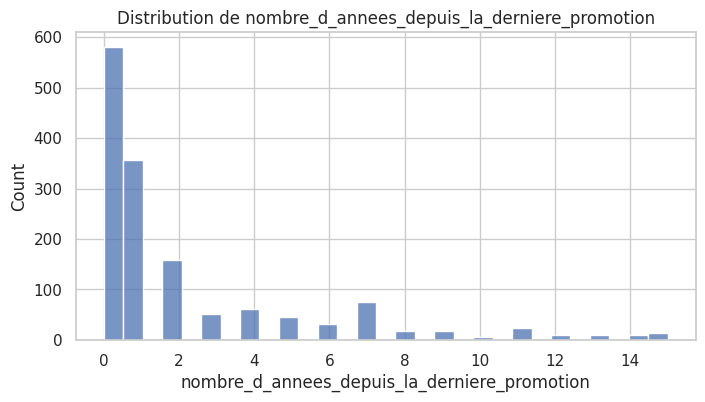

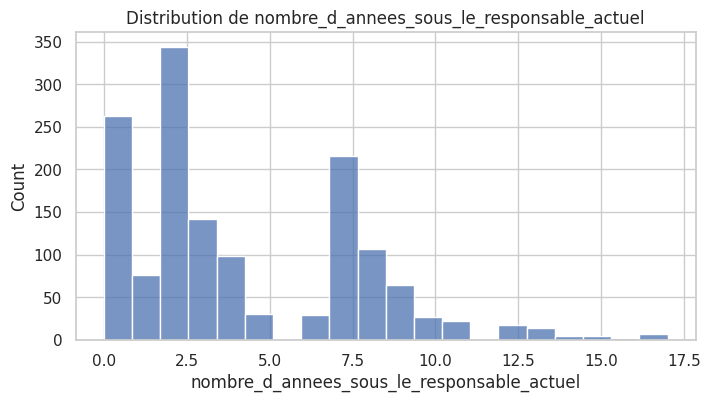

In [81]:
# EDA univariée

# On enlève l'id des listes
num_cols = [col for col in num_cols if col not in ["id"]]

# Sélection des colonnes numériques uniquement
num_cols = df_joint.select_dtypes(include=["int64", "float64"]).columns

# Appel de la fonction univariée avec ces colonnes
eda_univariee(df_joint, num_cols=num_cols, cat_cols=[])

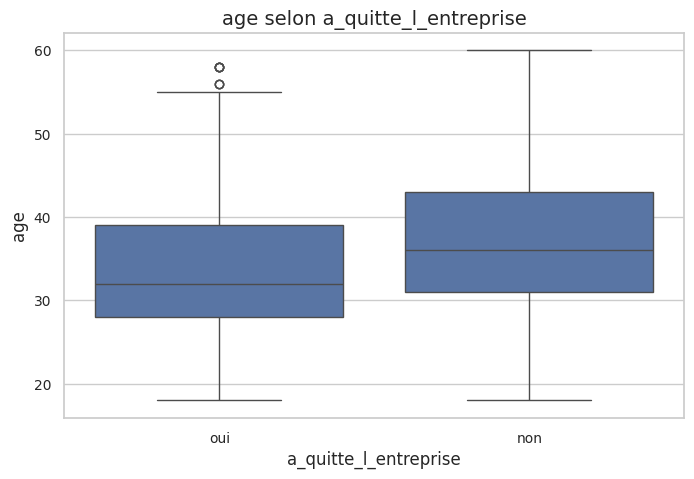

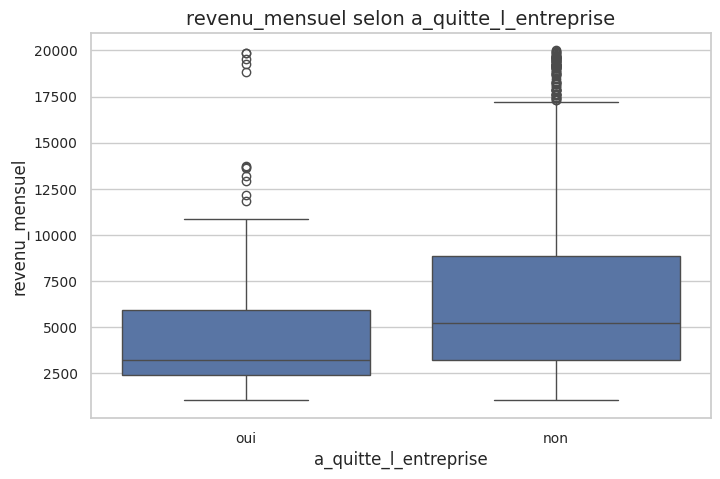

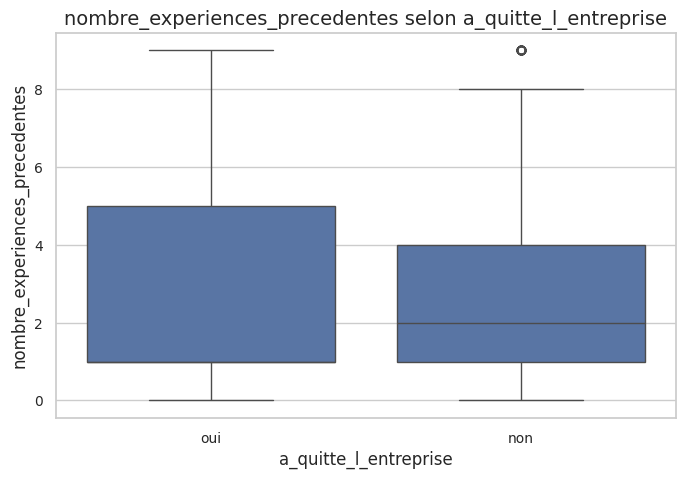

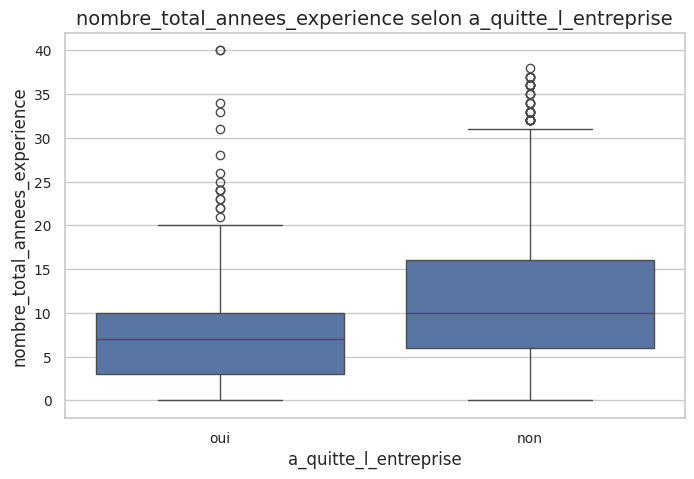

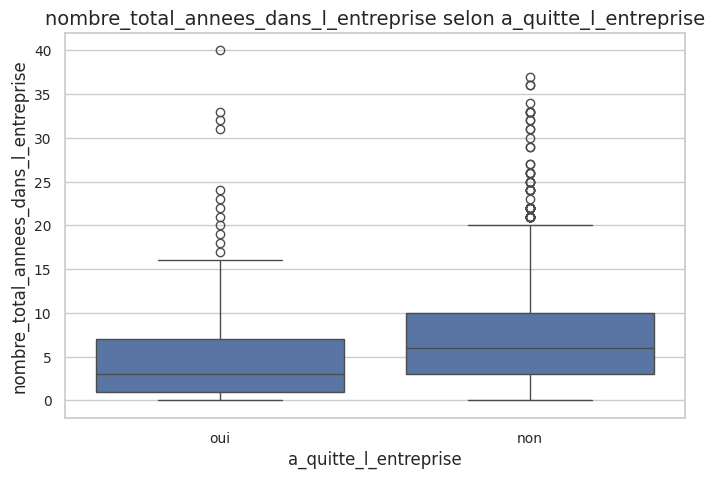

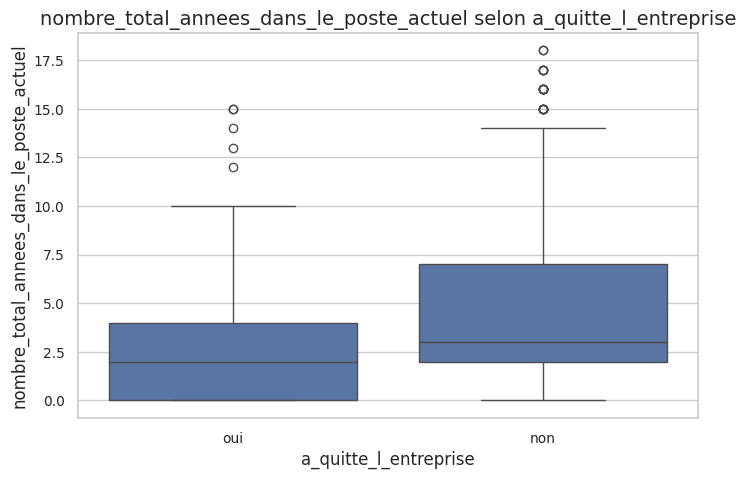

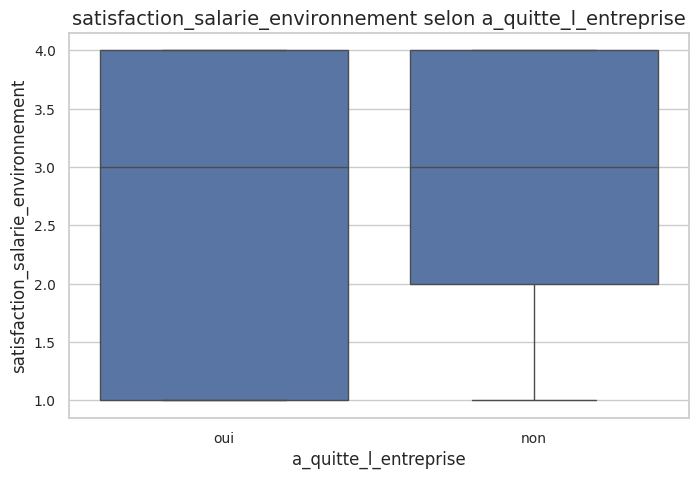

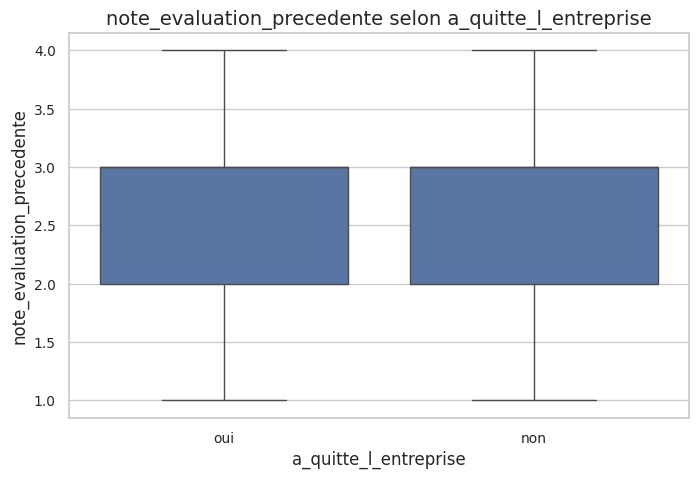

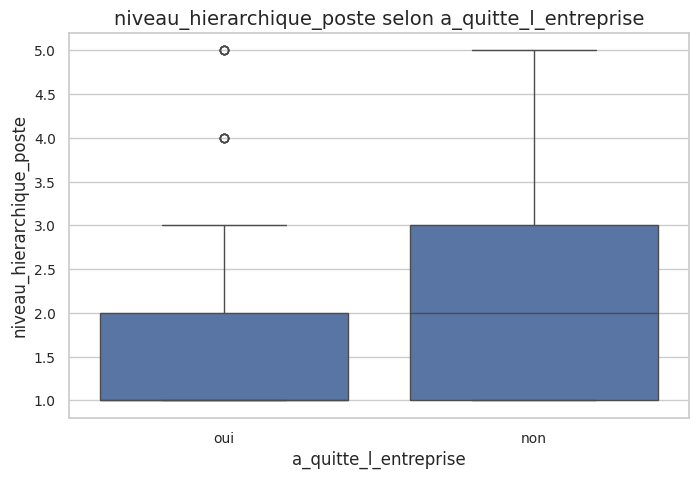

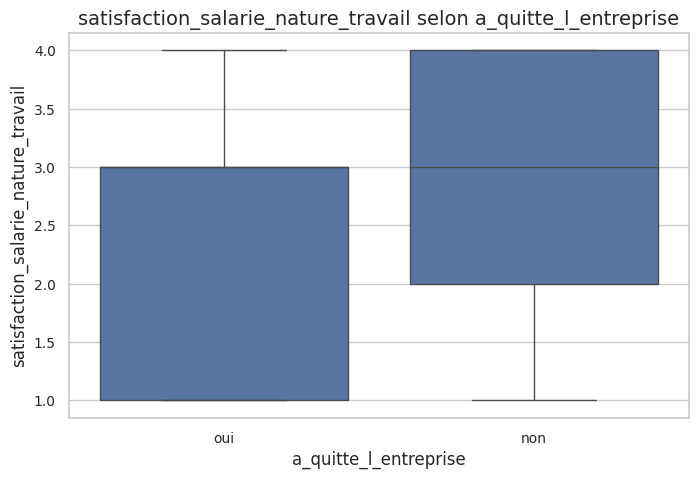

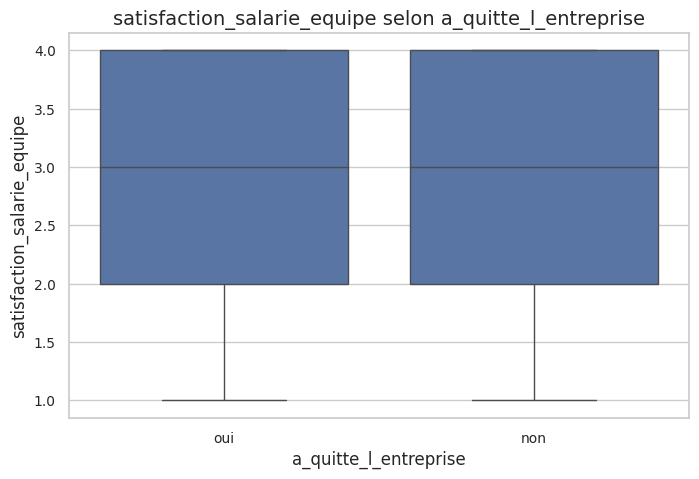

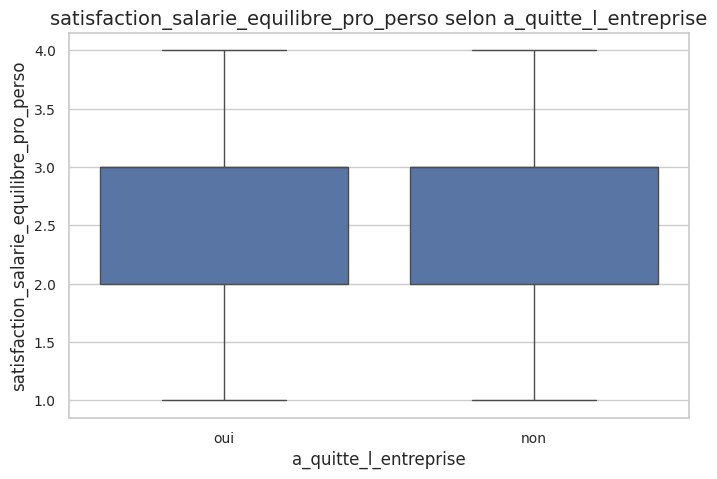

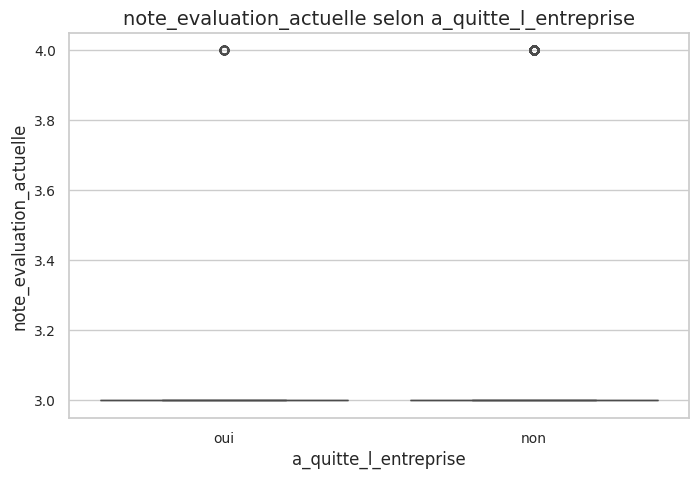

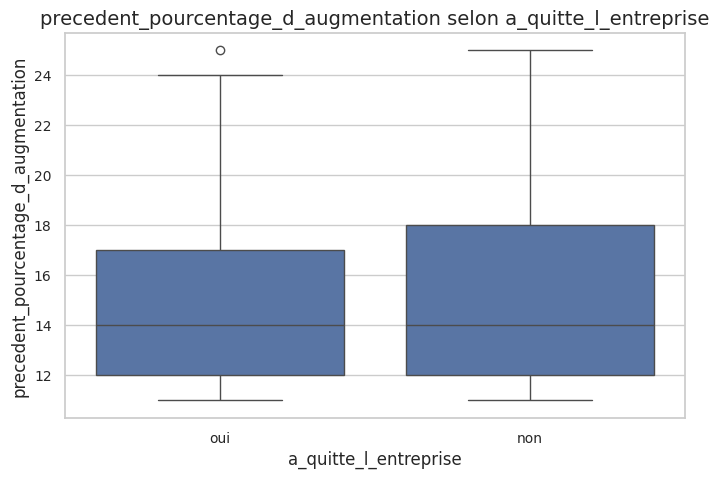

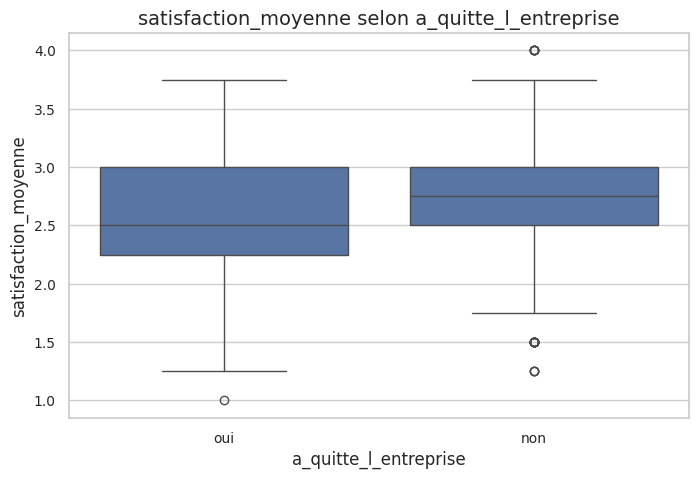

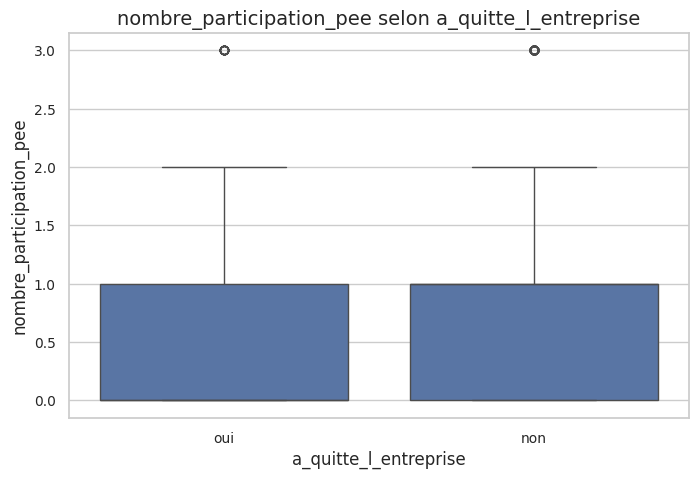

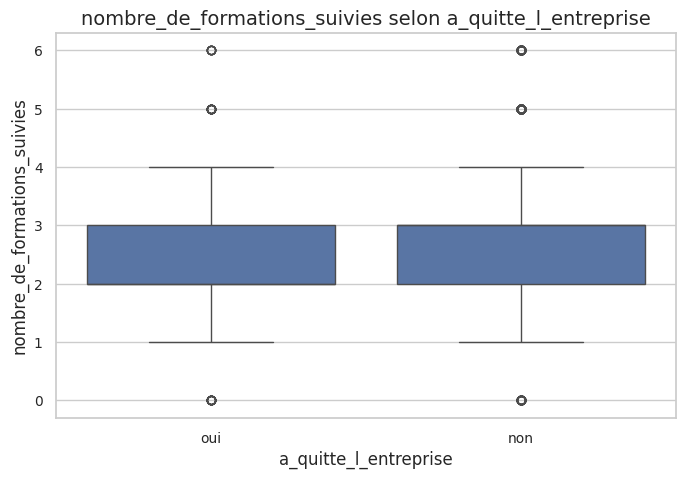

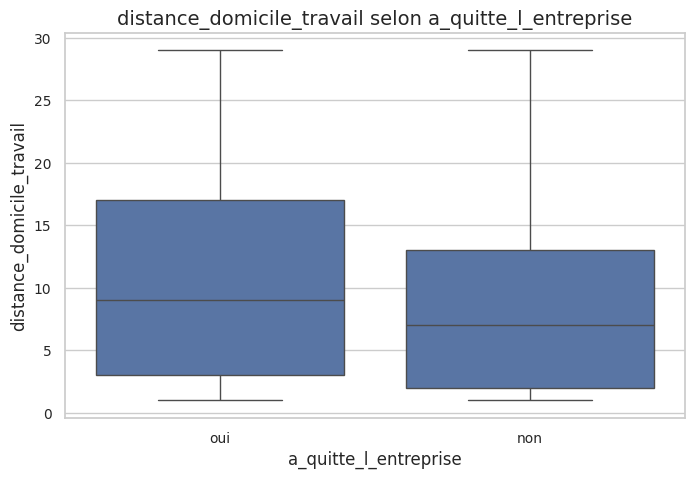

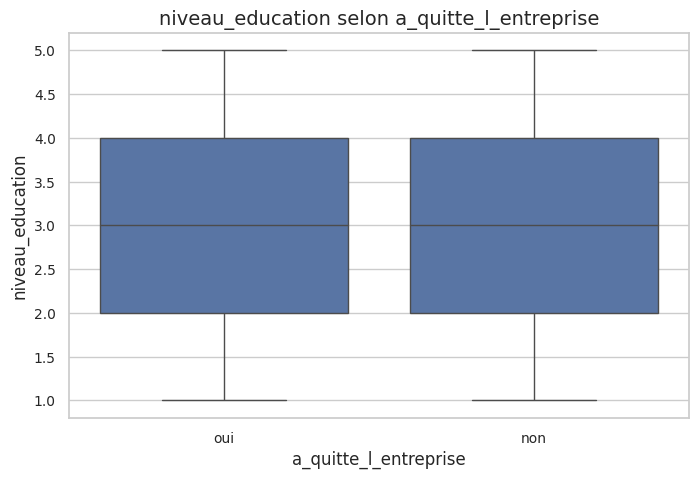

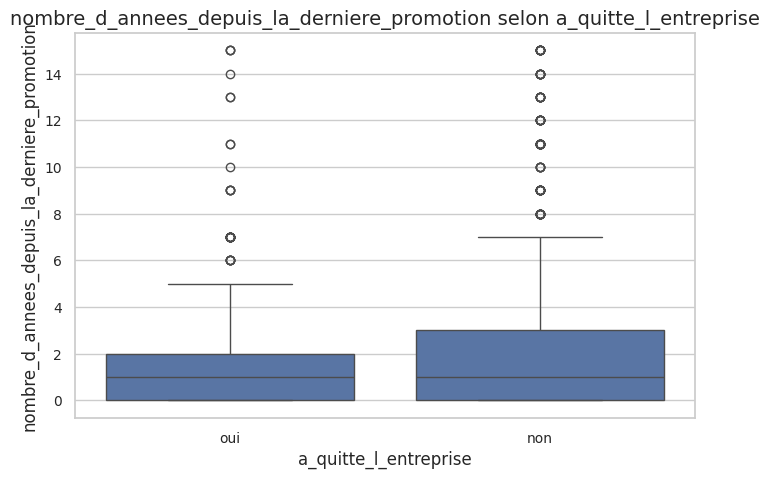

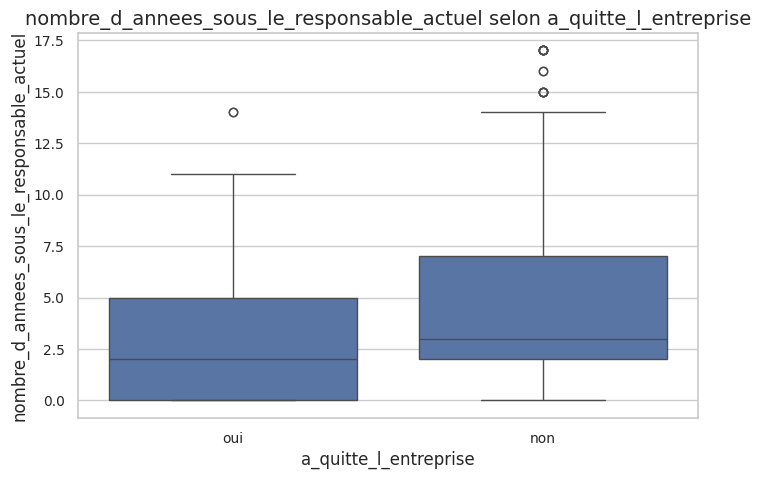

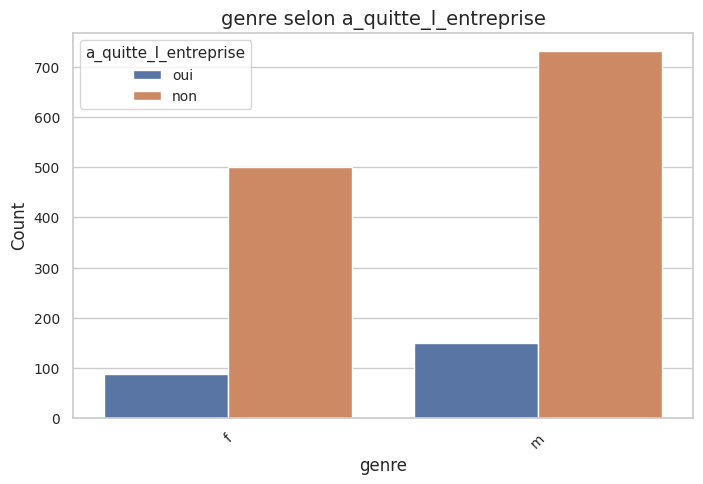

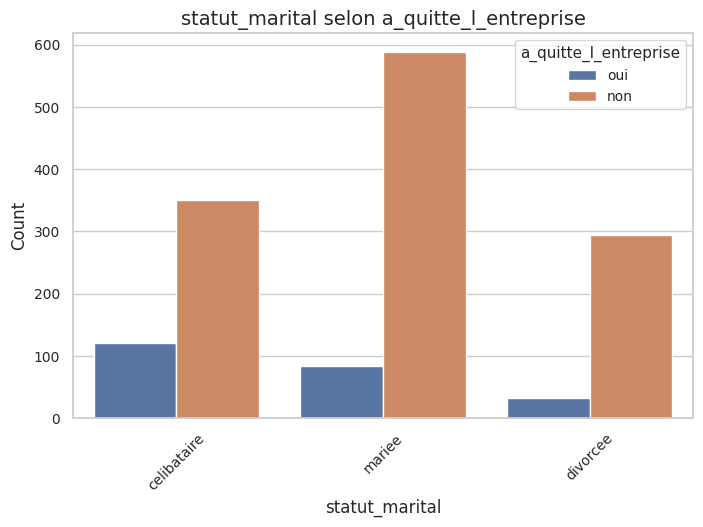

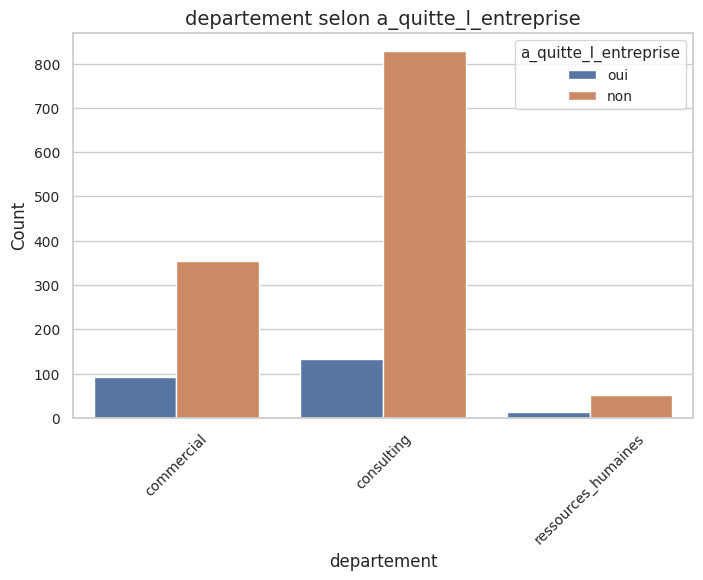

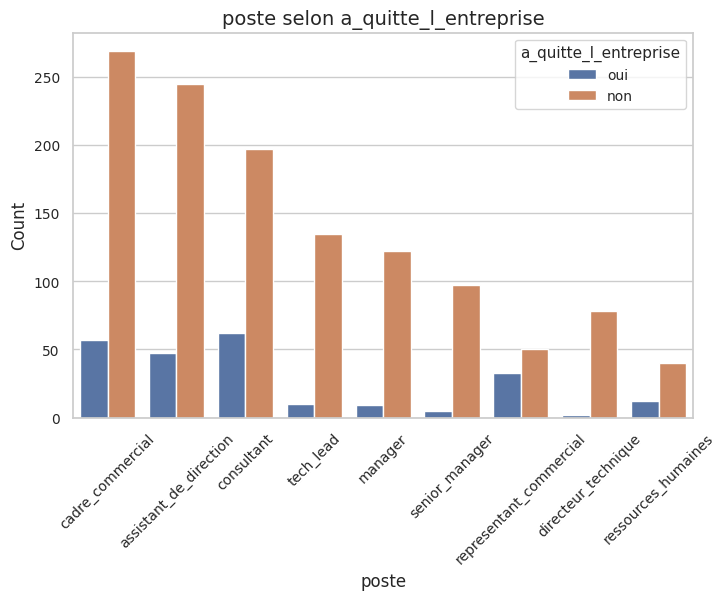

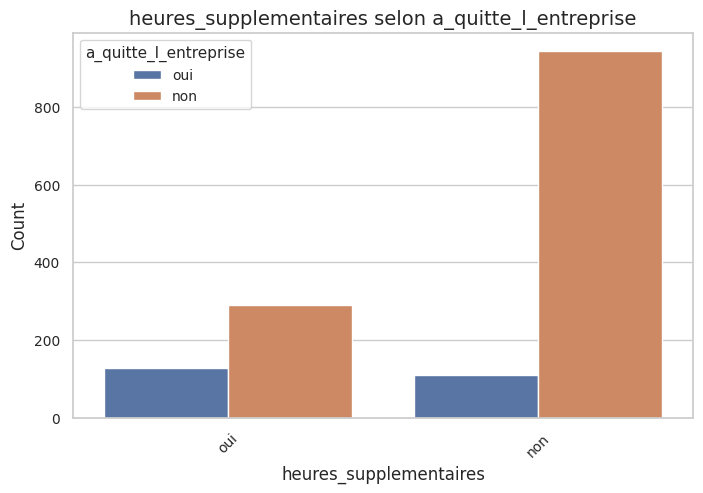

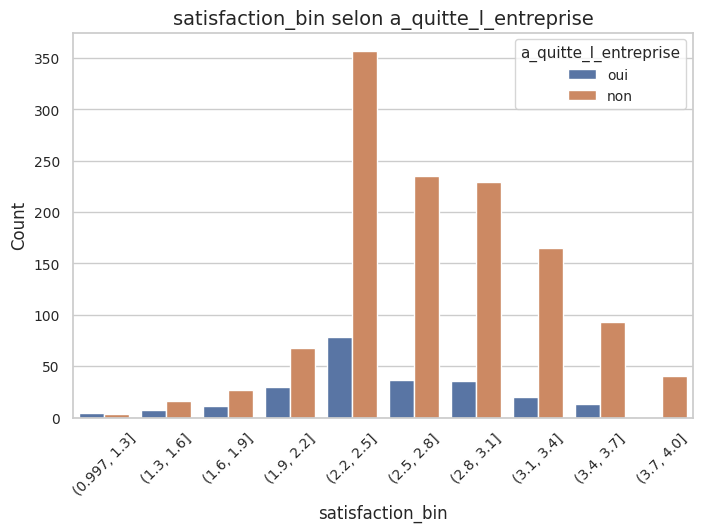

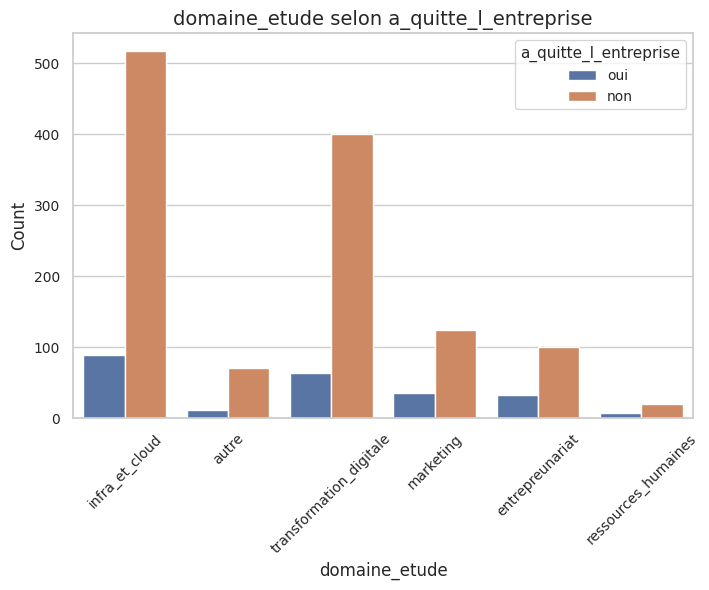

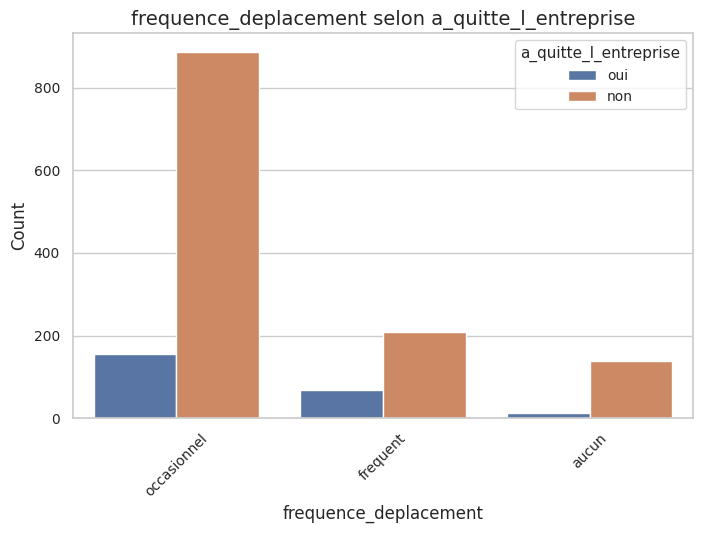

In [82]:
# EDA bivariée

# Détecter colonnes numériques et catégorielles automatiquement
num_cols = df_joint.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_joint.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# On enlève la cible et l'id des listes
num_cols = [col for col in num_cols if col not in ["id"]]
cat_cols = [col for col in cat_cols if col not in ["id", "a_quitte_l_entreprise"]]

# Lancer l'EDA bivariée
eda_bivariee(df_joint, target_col="a_quitte_l_entreprise", num_cols=num_cols, cat_cols=cat_cols)

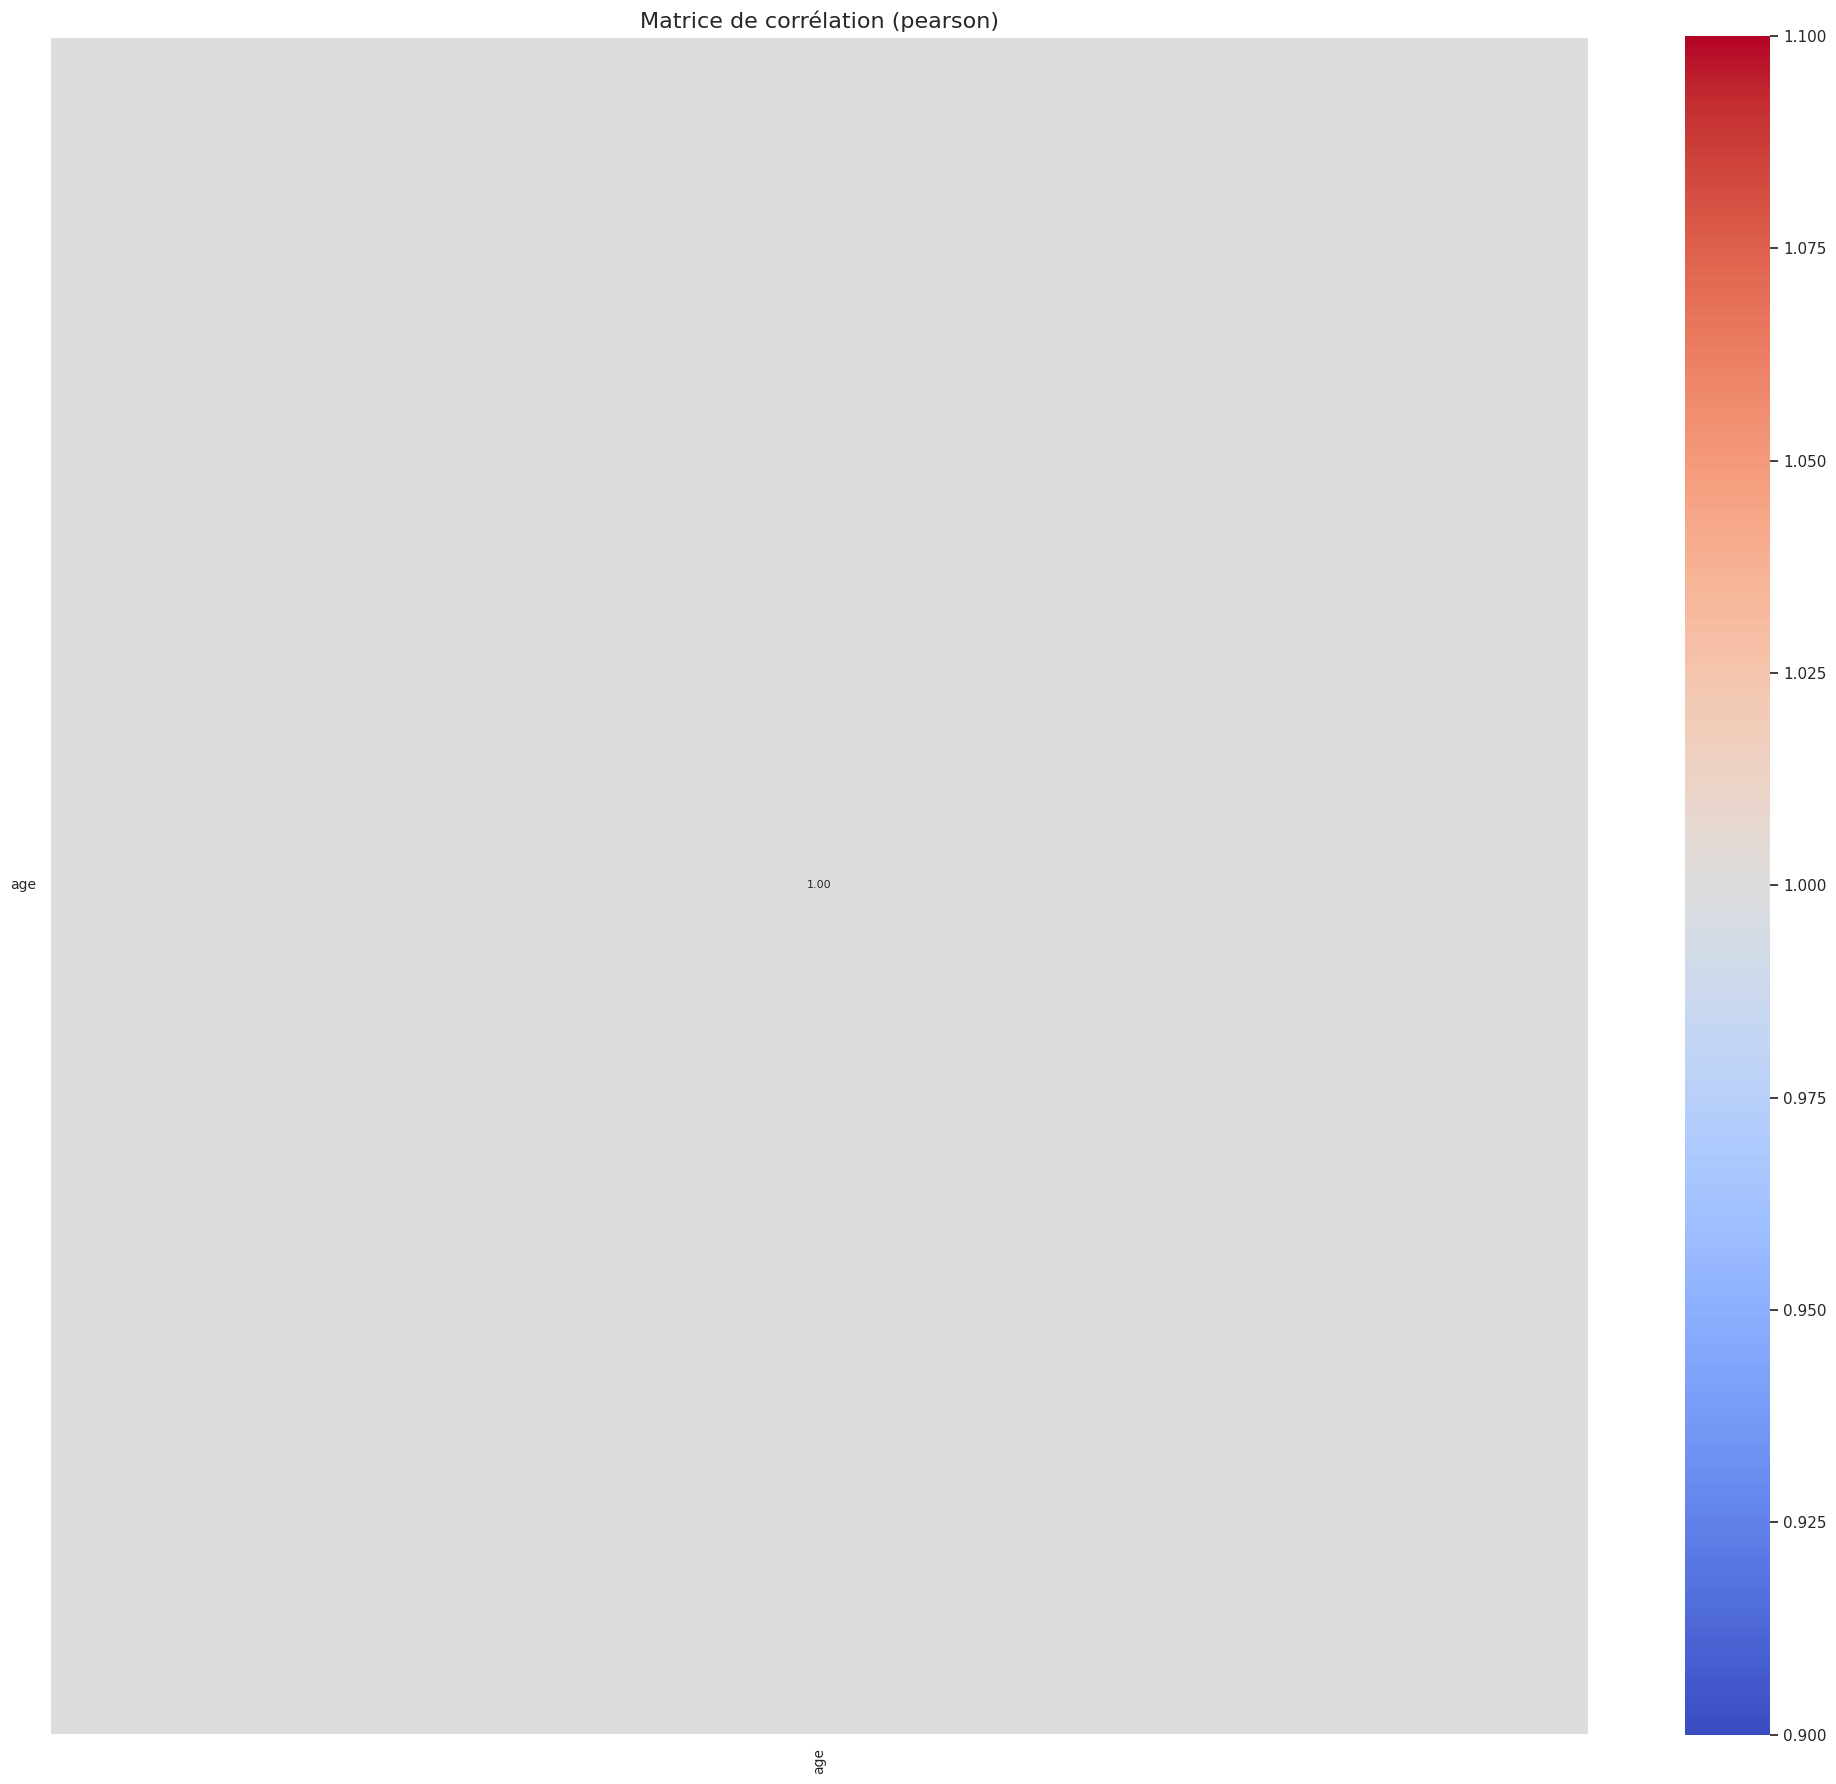

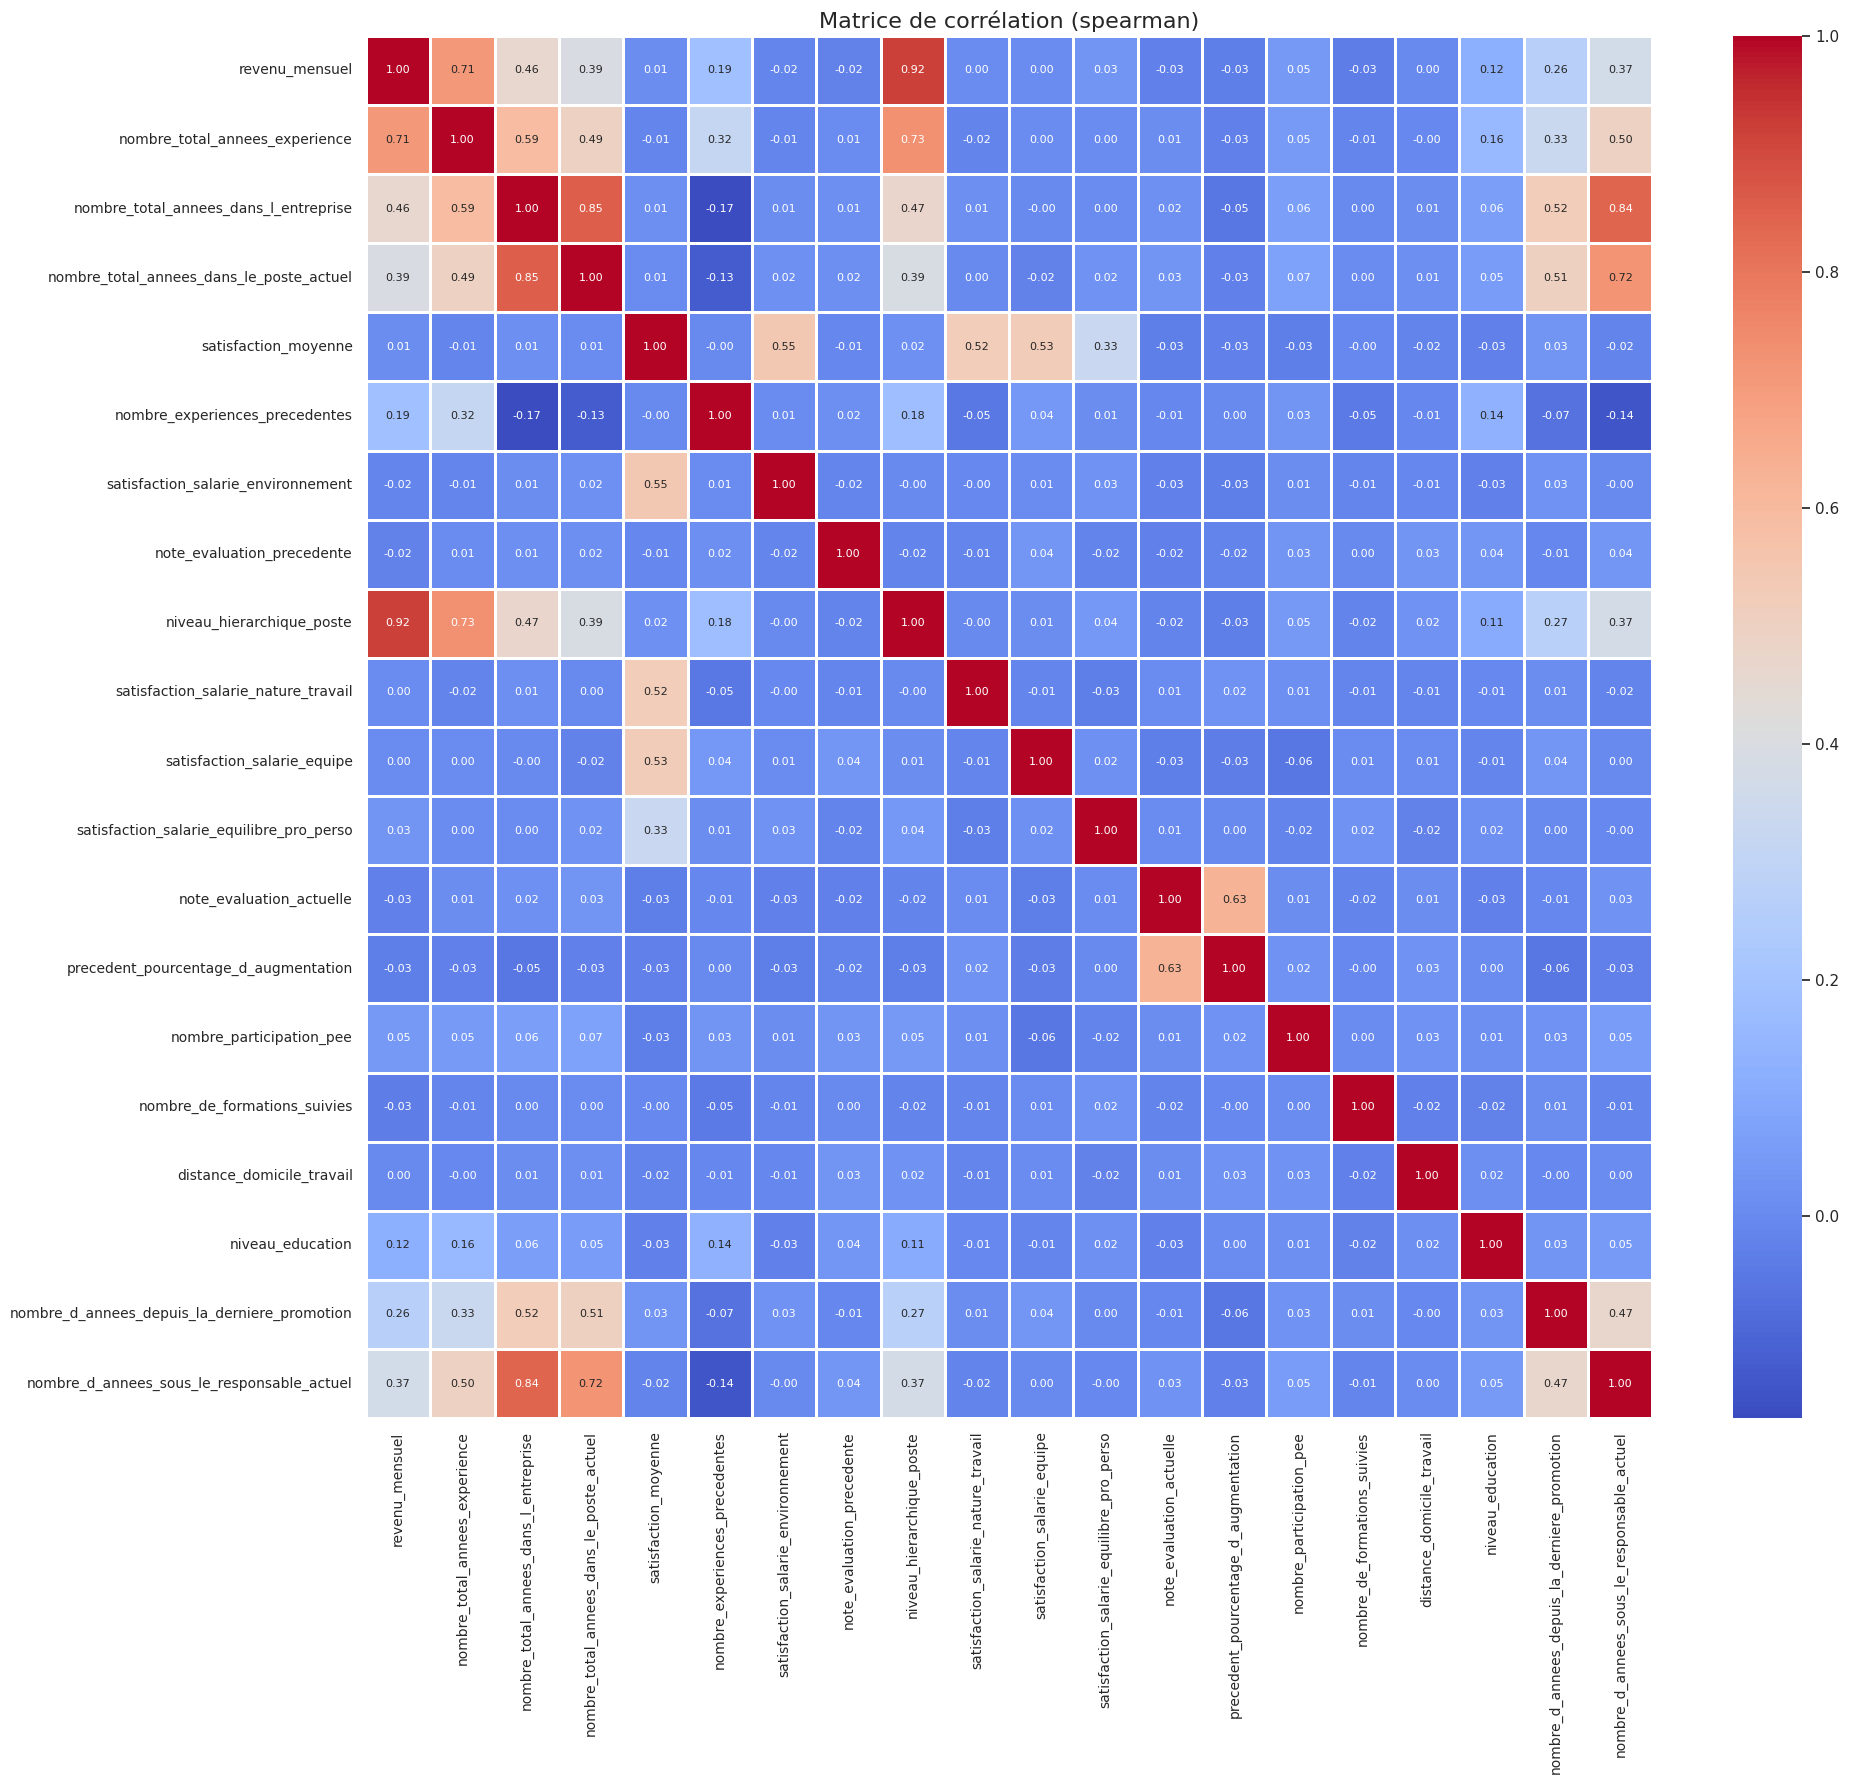

In [83]:
# Pearson pour variables continues/normales
correlation_heatmap(df_joint, method="pearson")

# Spearman pour variables discrètes/non normales
correlation_heatmap(df_joint, method="spearman")

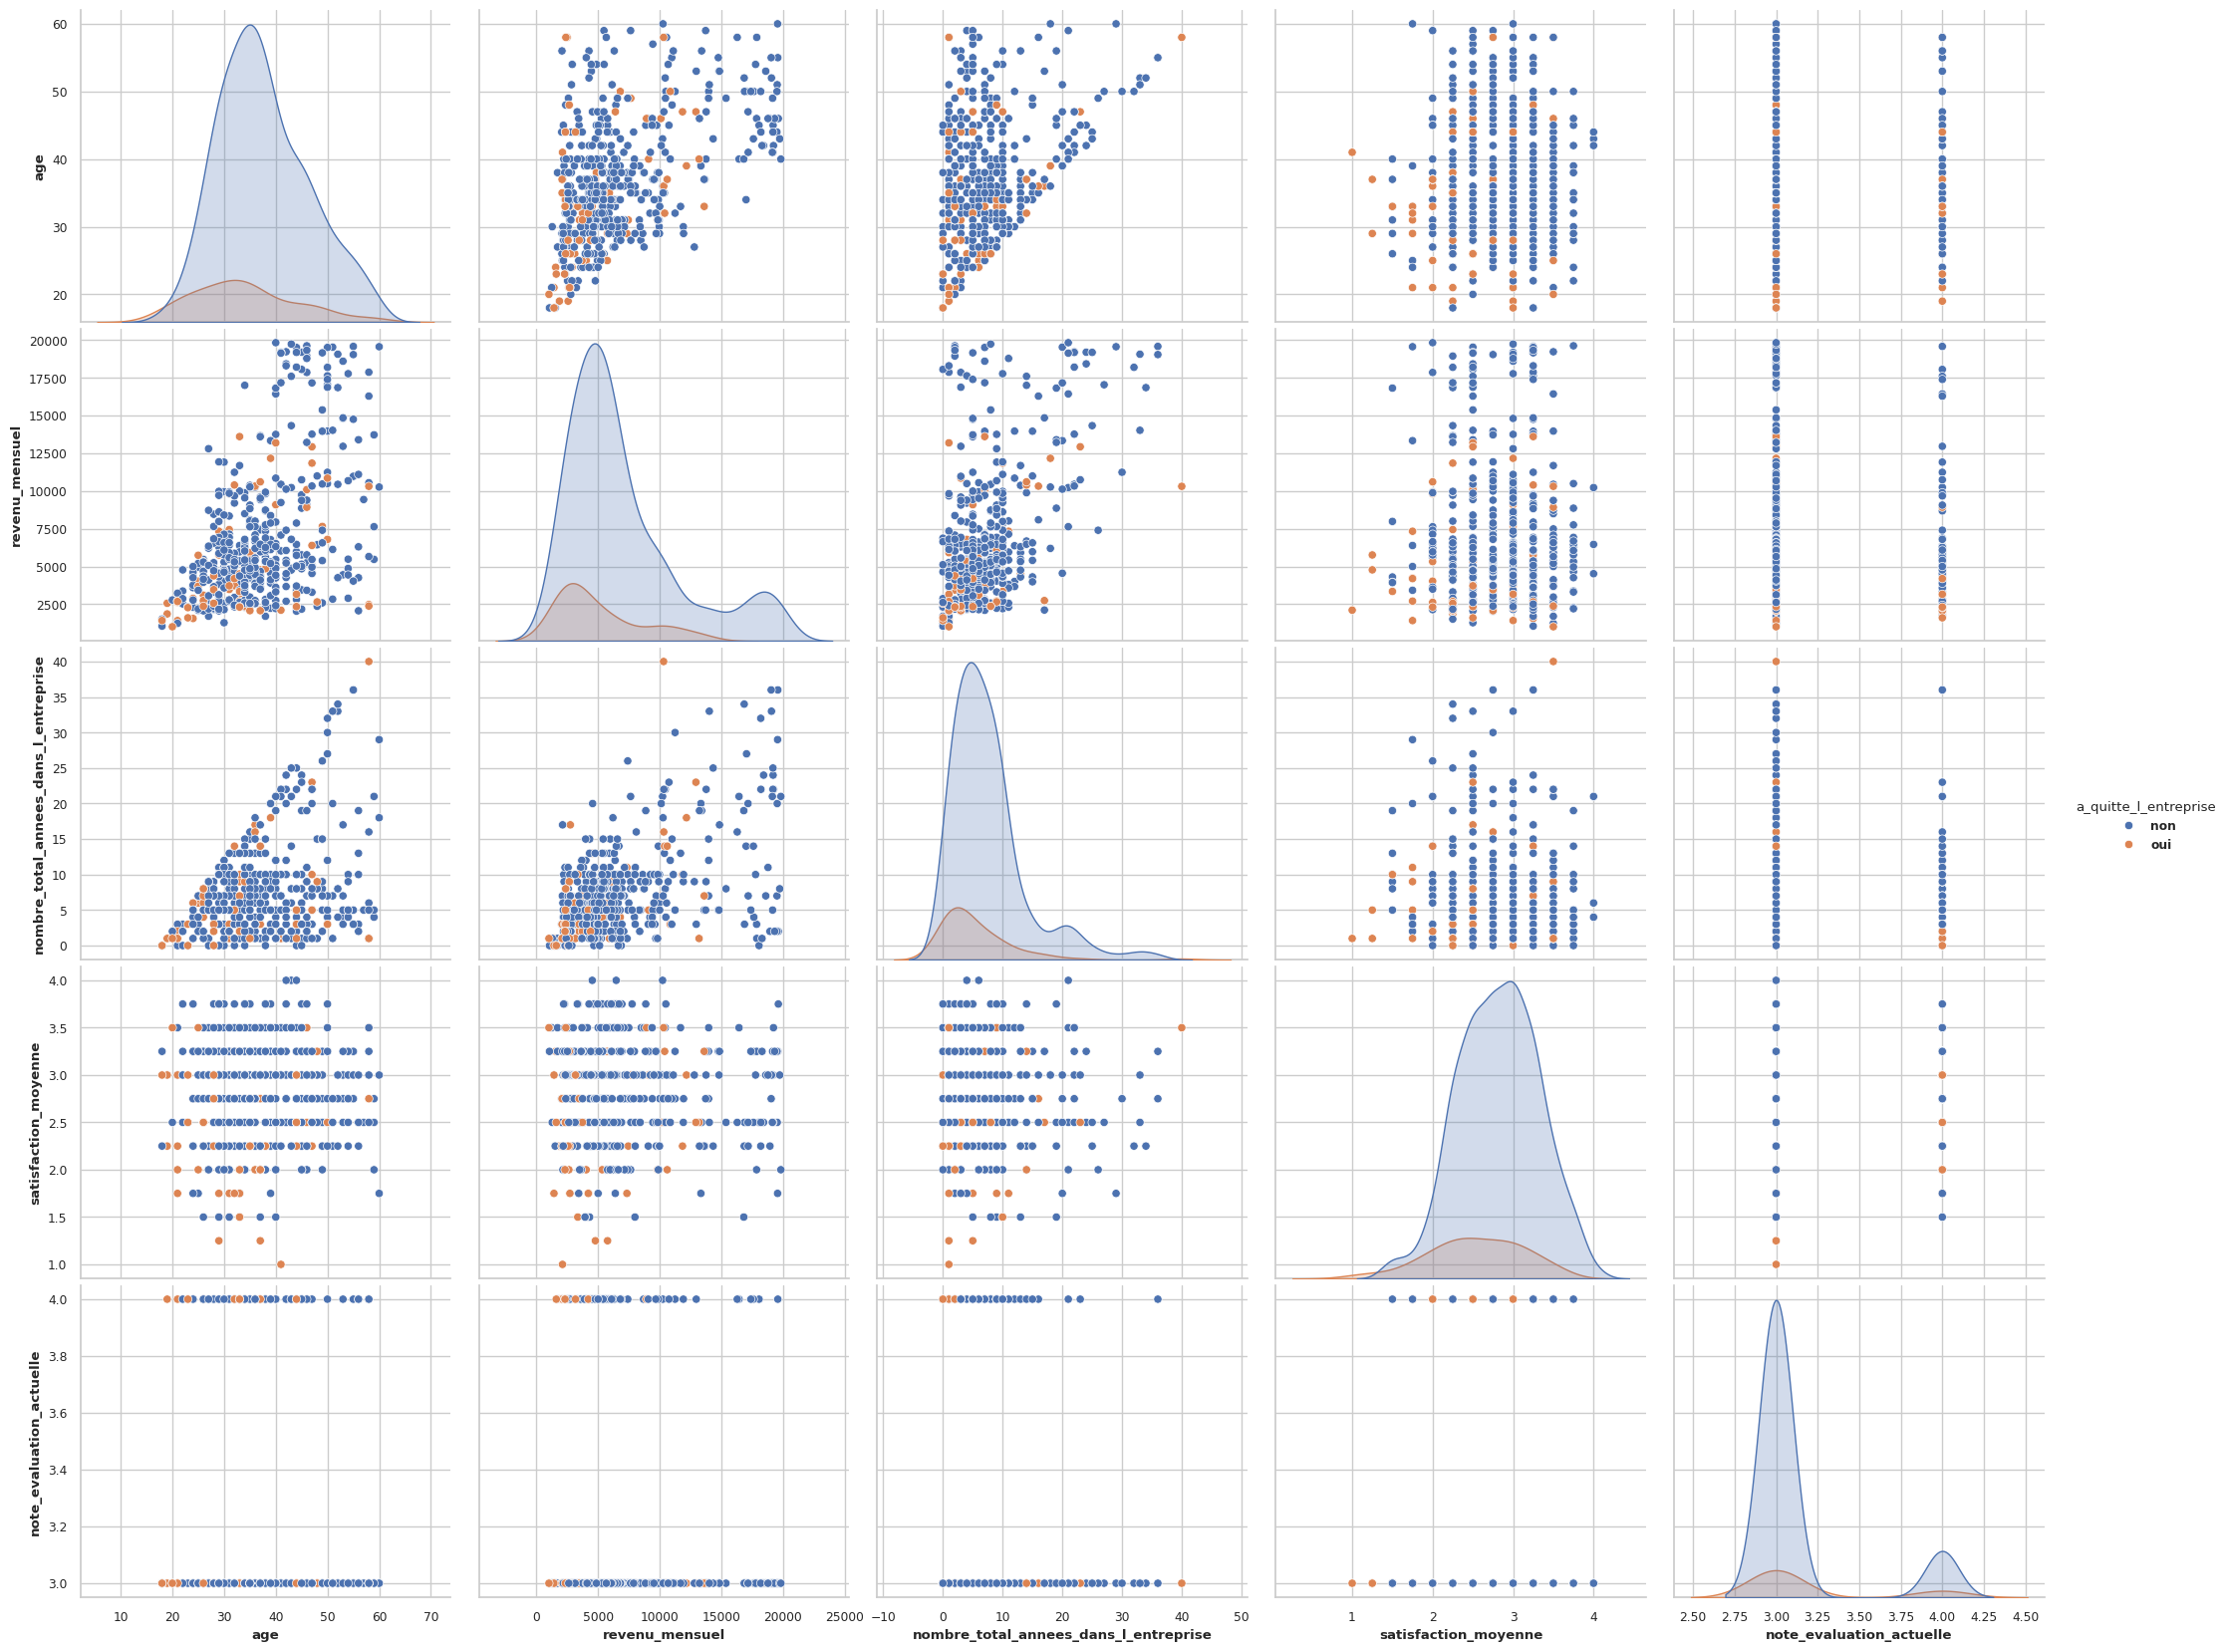

In [84]:
# Pairplot pour les variables clés

# Choisir les variables numériques les plus pertinentes
selected_cols = [
    "age", 
    "revenu_mensuel",
    "nombre_total_annees_dans_l_entreprise",
    "satisfaction_moyenne",
    "note_evaluation_actuelle"
]

pairplot_sample(df_joint, cols=selected_cols, target_col="a_quitte_l_entreprise", sample_size=500)

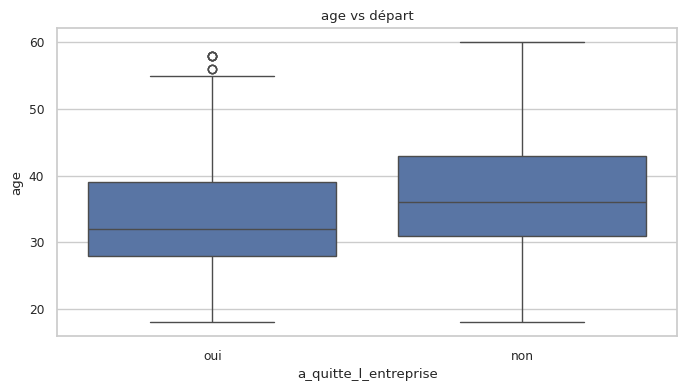

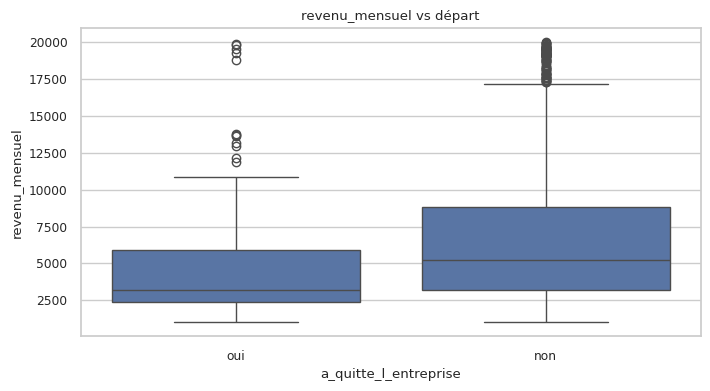

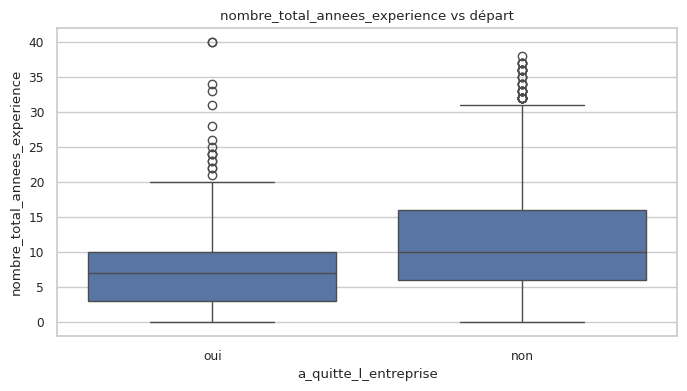

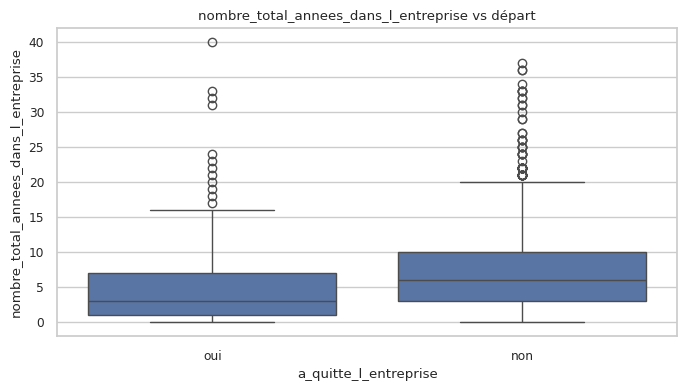

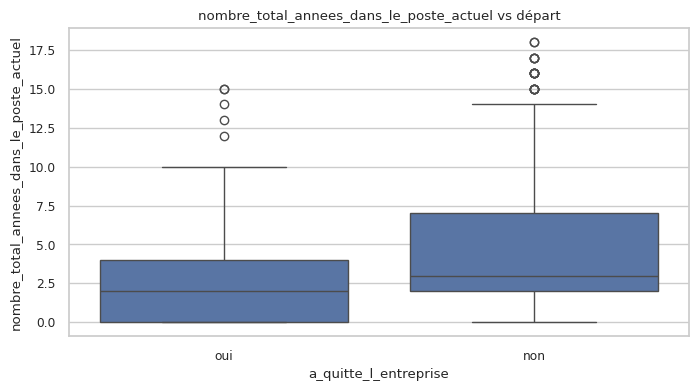

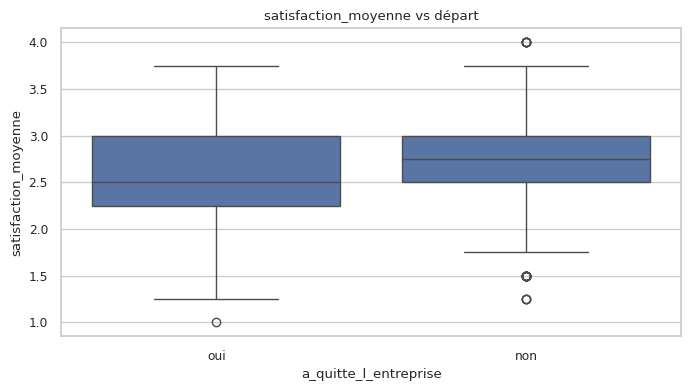

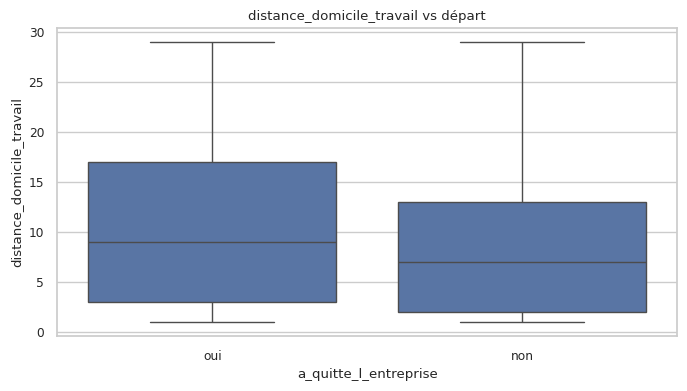

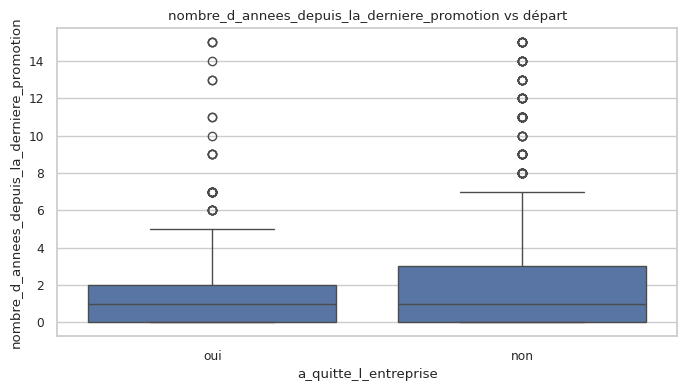

In [85]:
# Visualisations variable cible en fonction des variables numériques
num_cols = [
    "age", "revenu_mensuel", "nombre_total_annees_experience",
    "nombre_total_annees_dans_l_entreprise",
    "nombre_total_annees_dans_le_poste_actuel",
    "satisfaction_moyenne",
    "distance_domicile_travail",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

for col in num_cols:
    sns.boxplot(x="a_quitte_l_entreprise", y=col, data=df_joint)
    plt.title(f"{col} vs départ")
    plt.show()

In [86]:
# Mesurer la dispersion des valeurs et détecter les outliers avec la statistique descriptive IQR

print(f"{'Variable':40} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Min_IQR':>10} {'Max_IQR':>10} {'Outliers':>10}")
print("-" * 100)

for col in num_cols:
    Q1 = df_joint[col].quantile(0.25)
    Q3 = df_joint[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_joint[
        (df_joint[col] < lower) | 
        (df_joint[col] > upper)
    ]

    print(f"{col:40} {Q1:8.2f} {Q3:8.2f} {IQR:8.2f} {lower:10.2f} {upper:10.2f} {len(outliers):10}")

Variable                                       Q1       Q3      IQR    Min_IQR    Max_IQR   Outliers
----------------------------------------------------------------------------------------------------
age                                         30.00    43.00    13.00      10.50      62.50          0
revenu_mensuel                            2911.00  8379.00  5468.00   -5291.00   16581.00        114
nombre_total_annees_experience               6.00    15.00     9.00      -7.50      28.50         63
nombre_total_annees_dans_l_entreprise        3.00     9.00     6.00      -6.00      18.00        104
nombre_total_annees_dans_le_poste_actuel     2.00     7.00     5.00      -5.50      14.50         21
satisfaction_moyenne                         2.50     3.00     0.50       1.75       3.75         36
distance_domicile_travail                    2.00    14.00    12.00     -16.00      32.00          0
nombre_d_annees_depuis_la_derniere_promotion     0.00     3.00     3.00      -4.50       7.

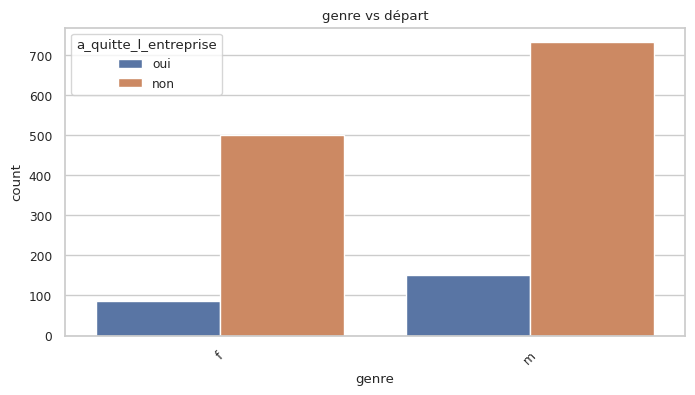

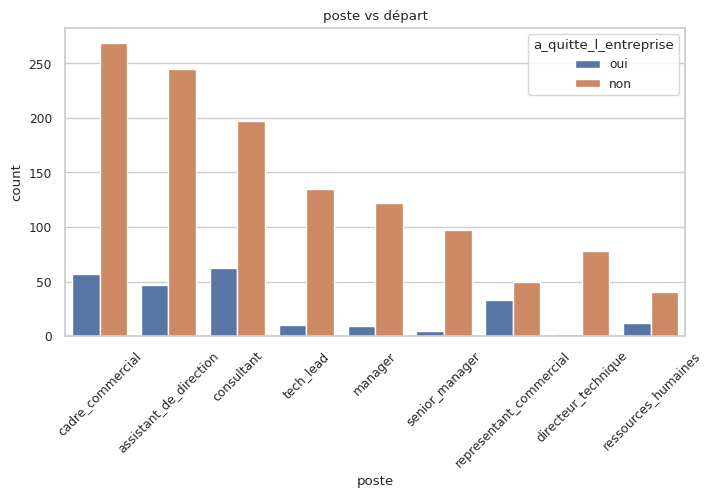

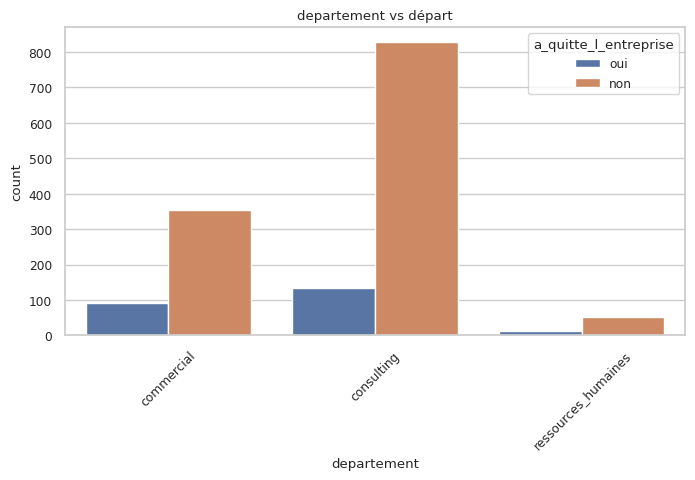

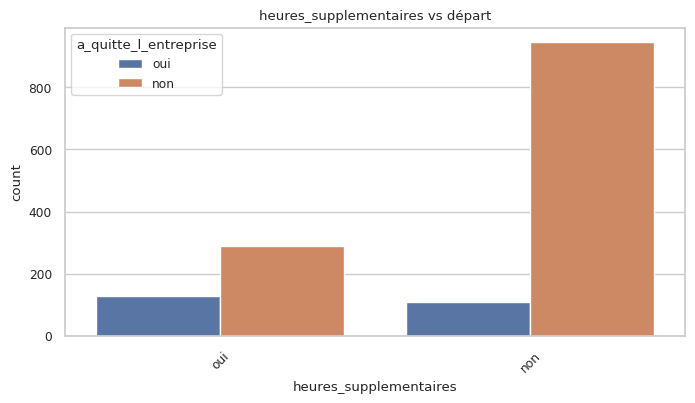

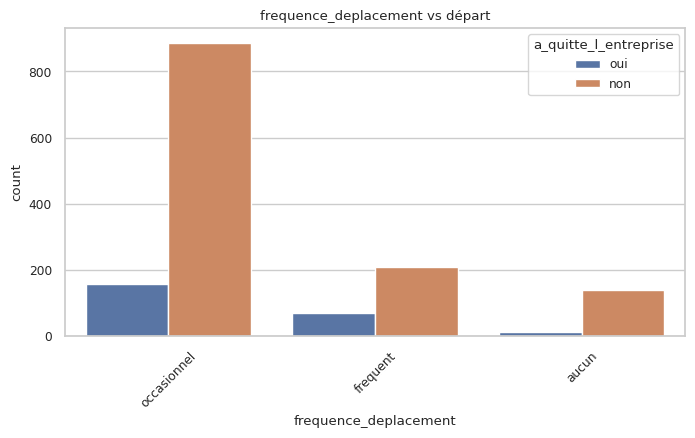

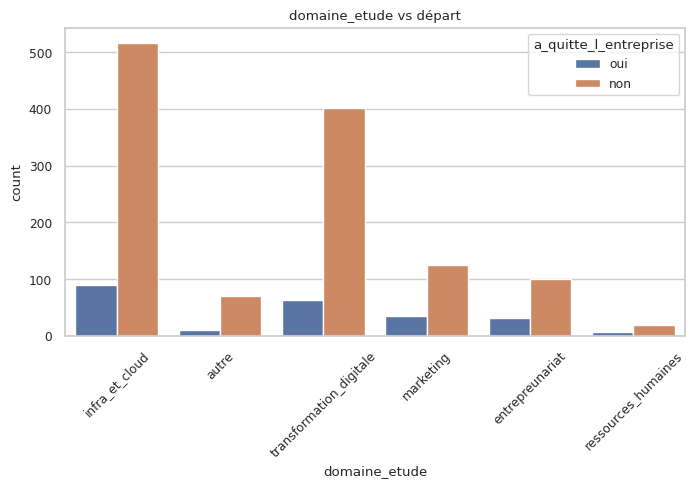

In [87]:
# Visualisations variables catégorielles versus la target
cat_cols = [
    "genre", "poste", "departement",
    "heures_supplementaires",
    "frequence_deplacement",
    "domaine_etude"
]

for col in cat_cols:
    sns.countplot(data=df_joint, x=col, hue="a_quitte_l_entreprise")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs départ")
    plt.show()

In [88]:
# Afichage numérique variables catégorielles versus la target
for col in cat_cols:
    print("\n" + "="*70)
    print(f"Variable : {col}")
    print("="*70)

    # tableau croisé (effectifs)
    table = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"])

    # pourcentages par ligne
    table_pct = pd.crosstab(
        df_joint[col],
        df_joint["a_quitte_l_entreprise"],
        normalize="index"
    ) * 100

    # affichage combiné
    for category in table.index:
        print(f"\n {col} = {category}")
        
        for target in table.columns:
            count = table.loc[category, target]
            pct = table_pct.loc[category, target]

            print(f"   {target:<10} : {count:4} ({pct:5.1f}%)")


Variable : genre

 genre = f
   non        :  501 ( 85.2%)
   oui        :   87 ( 14.8%)

 genre = m
   non        :  732 ( 83.0%)
   oui        :  150 ( 17.0%)

Variable : poste

 poste = assistant_de_direction
   non        :  245 ( 83.9%)
   oui        :   47 ( 16.1%)

 poste = cadre_commercial
   non        :  269 ( 82.5%)
   oui        :   57 ( 17.5%)

 poste = consultant
   non        :  197 ( 76.1%)
   oui        :   62 ( 23.9%)

 poste = directeur_technique
   non        :   78 ( 97.5%)
   oui        :    2 (  2.5%)

 poste = manager
   non        :  122 ( 93.1%)
   oui        :    9 (  6.9%)

 poste = representant_commercial
   non        :   50 ( 60.2%)
   oui        :   33 ( 39.8%)

 poste = ressources_humaines
   non        :   40 ( 76.9%)
   oui        :   12 ( 23.1%)

 poste = senior_manager
   non        :   97 ( 95.1%)
   oui        :    5 (  4.9%)

 poste = tech_lead
   non        :  135 ( 93.1%)
   oui        :   10 (  6.9%)

Variable : departement

 departement = co

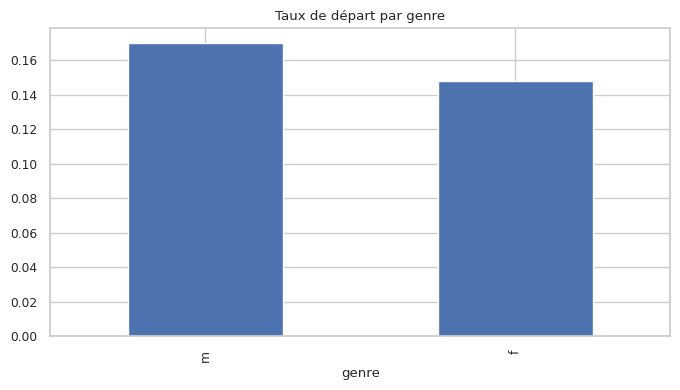

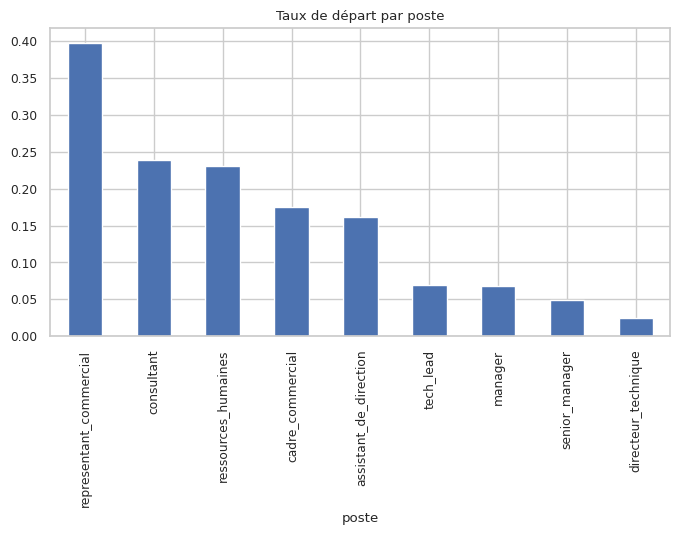

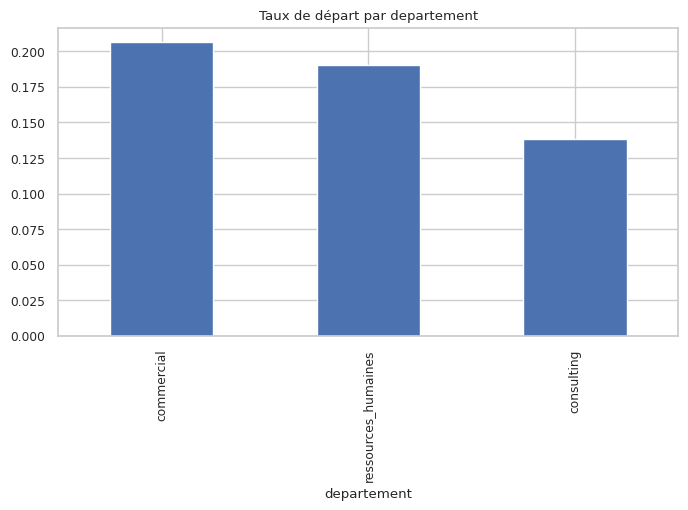

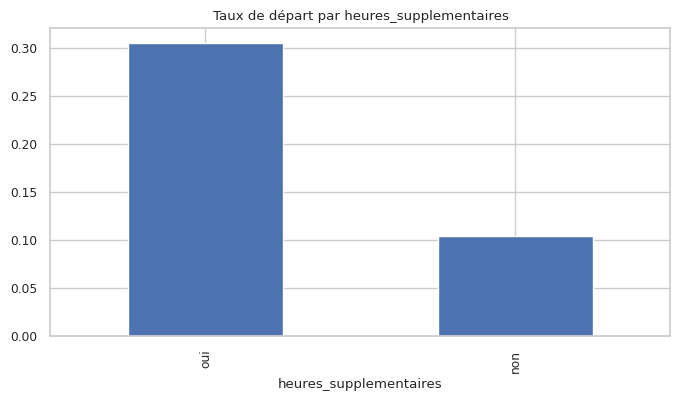

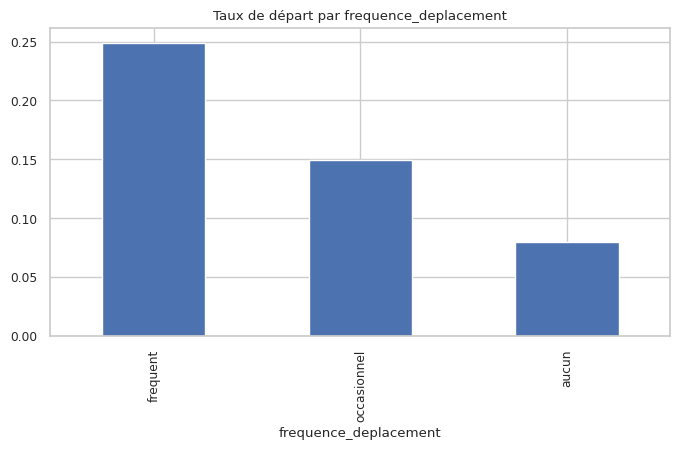

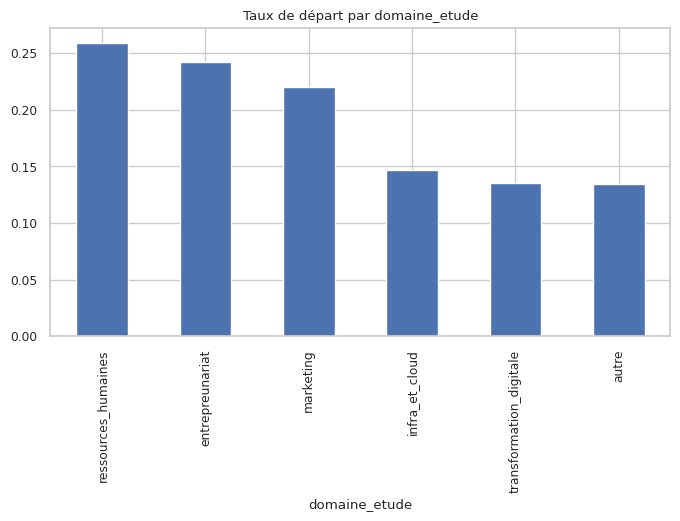

In [89]:
# Identification des taux de départ par catégorie

for col in cat_cols:
    taux = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"], normalize="index")
    taux["oui"].sort_values(ascending=False).plot(kind="bar")
    plt.title(f"Taux de départ par {col}")
    plt.show()

In [90]:
# Affichage numérique des taux de départs par catégorie

for col in cat_cols:
    print("\n" + "="*70)
    print(f"Taux de départ par {col}")
    print("="*70)

    # calcul taux de départ
    taux = pd.crosstab(
        df_joint[col],
        df_joint["a_quitte_l_entreprise"],
        normalize="index"
    )

    # tri décroissant sur "oui"
    taux_sorted = taux["oui"].sort_values(ascending=False)

    # affichage
    for category, value in taux_sorted.items():
        print(f"{category:<30} : {value*100:5.1f}%")


Taux de départ par genre
m                              :  17.0%
f                              :  14.8%

Taux de départ par poste
representant_commercial        :  39.8%
consultant                     :  23.9%
ressources_humaines            :  23.1%
cadre_commercial               :  17.5%
assistant_de_direction         :  16.1%
tech_lead                      :   6.9%
manager                        :   6.9%
senior_manager                 :   4.9%
directeur_technique            :   2.5%

Taux de départ par departement
commercial                     :  20.6%
ressources_humaines            :  19.0%
consulting                     :  13.8%

Taux de départ par heures_supplementaires
oui                            :  30.5%
non                            :  10.4%

Taux de départ par frequence_deplacement
frequent                       :  24.9%
occasionnel                    :  15.0%
aucun                          :   8.0%

Taux de départ par domaine_etude
ressources_humaines            :  25.

In [91]:
# Tests de statistiques inférentielles
# si p < 0.05 alors variable significative

from scipy.stats import ttest_ind

group1 = df_joint[df_joint["a_quitte_l_entreprise"] == "oui"]
group0 = df_joint[df_joint["a_quitte_l_entreprise"] == "non"]

for col in num_cols:
    stat, p = ttest_ind(group1[col], group0[col])
    print(col, "p-value:", p)

age p-value: 8.356308021103588e-10
revenu_mensuel p-value: 7.147363985353823e-10
nombre_total_annees_experience p-value: 4.061878111266856e-11
nombre_total_annees_dans_l_entreprise p-value: 2.3188716103862972e-07
nombre_total_annees_dans_le_poste_actuel p-value: 6.003185843641391e-10
satisfaction_moyenne p-value: 8.59252198159284e-10
distance_domicile_travail p-value: 0.0027930600802134322
nombre_d_annees_depuis_la_derniere_promotion p-value: 0.20578995916249362


In [92]:
# Test de Mann wHitney
cols_mw = [
            
            "revenu_mensuel",
            "nombre_total_annees_experience",
            "nombre_total_annees_dans_l_entreprise",
            "nombre_total_annees_dans_le_poste_actuel",
            "satisfaction_moyenne",
            "nombre_experiences_precedentes",
            "satisfaction_salarie_environnement",
            "note_evaluation_precedente",
            "niveau_hierarchique_poste",
            "satisfaction_salarie_nature_travail",
            "satisfaction_salarie_equipe",
            "satisfaction_salarie_equilibre_pro_perso",
            "note_evaluation_actuelle",
            "nombre_participation_pee",
            "nombre_de_formations_suivies",
            "distance_domicile_travail",
            "niveau_education",
            "nombre_d_annees_depuis_la_derniere_promotion",
            "nombre_d_annees_sous_le_responsable_actuel",
            "precedent_pourcentage_d_augmentation"
]


from scipy.stats import mannwhitneyu

alpha = 0.05

for col in cols_mw:
    stat, p = mannwhitneyu(group1[col], group0[col], alternative="two-sided")

    if p < alpha:
        conclusion = "Différence significative"
    else:
        conclusion = "Pas de différence"

    print(f"{col:50} p-value = {p:.5f} → {conclusion}")


revenu_mensuel                                     p-value = 0.00000 → Différence significative
nombre_total_annees_experience                     p-value = 0.00000 → Différence significative
nombre_total_annees_dans_l_entreprise              p-value = 0.00000 → Différence significative
nombre_total_annees_dans_le_poste_actuel           p-value = 0.00000 → Différence significative
satisfaction_moyenne                               p-value = 0.00000 → Différence significative
nombre_experiences_precedentes                     p-value = 0.24237 → Pas de différence
satisfaction_salarie_environnement                 p-value = 0.00022 → Différence significative
note_evaluation_precedente                         p-value = 0.00000 → Différence significative
niveau_hierarchique_poste                          p-value = 0.00000 → Différence significative
satisfaction_salarie_nature_travail                p-value = 0.00008 → Différence significative
satisfaction_salarie_equipe                    

In [93]:
# Test du Khi2
from scipy.stats import chi2_contingency

for col in cat_cols:
    table = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"])
    stat, p, _, _ = chi2_contingency(table)
    print(col, "p-value:", p)

genre p-value: 0.29057244902890855
poste p-value: 2.752481638050678e-15
departement p-value: 0.004525606574479633
heures_supplementaires p-value: 8.15842372153832e-21
frequence_deplacement p-value: 5.608614476449931e-06
domaine_etude p-value: 0.006773980139025212


#### observations:

- Les variables les plus discriminantes sont liées à **ancienneté, expérience, revenu, satisfaction et formation** **(p-values très faibles (~0 ou 1e-10)**)
- Les variables moins discriminantes ou non significatives : **nombre d’expériences précédentes** **(p-values ~ 0.242 > 0.05)**, **satisfaction équipe, note d’évaluation actuelle, niveau d’éducation**.
- Les variables catégorielles les plus discriminantes : **poste** **(p-values ~ 2.75e-15)**, **heures supplémentaires** **(p-values ~ 8.16e-21)**, **fréquence de déplacement** **(p-values ~ 5.6e-6)**.
- Les segments moins discriminants : **genre**.
- Les postes à forte rotation : représentant commercial, consultant, RH.
- **Les salariés effectuant des heures supplémentaires ou ayant une fréquence de déplacement élevée ont un risque de départ plus élevé**.
- **Les salariés issus de domaines d’étude RH, entrepreneuriat ou marketing sont plus susceptibles de quitter l’entreprise**.
- **Segments à risque:**
  -  **Postes à forte rotation** : représentant commercial, consultant, RH → ces segments sont explicitement identifiés comme plus à risque.
  -  **Comportements à risque** : salariés effectuant des heures supplémentaires ou avec une fréquence de déplacement élevée.
  -  **Domaines d’étude à risque** : RH, entrepreneuriat, marketing → segment ciblé pour le risque de départ
- Multicolinéarité probable dans :
  - Ancienneté, expérience, poste actuel, sous responsable, revenu et niveau hiérarchique.
  -  Si ces variables sont utilisées ensemble dans un modèle linéaire (ex : régression logistique), les coefficients peuvent devenir instables.
- Solution / feature engineering :
  - **Créer des features composites ou ratios pour réduire la redondance** :
    - ratio_experience_salaire = revenu_mensuel / nombre_total_annees_experience
    - anciennete_relative = nombre_total_annees_dans_le_poste_actuel / nombre_total_annees_dans_l_entreprise
    - anciennete_sous_responsable = nombre_d_annees_sous_le_responsable_actuel / nombre_total_annees_dans_le_poste_actuel
    - niveau_poste_vs_revenu = revenu_mensuel / niveau_hierarchique_poste (pour capturer la sur/sous-rémunération par niveau)
    - éviter d’inclure directement toutes les variables corrélées si modèle linéaire.
  - **Variables moins problématiques** :
    - Satisfaction moyenne,
    - distance domicile-travail,
    - formations suivies
    - corrélation modérée ou faible, peuvent rester telles quelles.


In [94]:
# Feature engineering et préparation pour la modélisation 
import pandas as pd
import numpy as np

# Suppression des colonnes inutiles

drop_cols = [
    "id",
    "nombre_d_annees_sous_le_responsable_actuel",
    "nombre_total_annees_experience",
    "nombre_total_annees_dans_l_entreprise",
    "nombre_total_annees_dans_le_poste_actuel",
    "revenu_mensuel"
]

# Création d'un dataframe résultant pour les étapes suivantes de feature engineering puis de modélisation

df_mod = df_joint.drop(columns=drop_cols)

# Variables numériques dérivées

df_mod["ratio_salaire_experience"] = df_joint["revenu_mensuel"] / (df_joint["nombre_total_annees_experience"] + 1)
df_mod["anciennete_ratio"] = df_joint["nombre_total_annees_dans_l_entreprise"] / (df_joint["nombre_total_annees_experience"] + 1)
df_mod["anciennete_sous_responsable_ratio"] = df_joint["nombre_d_annees_sous_le_responsable_actuel"] / \
                                              (df_joint["nombre_total_annees_dans_le_poste_actuel"] + 1)
df_mod["niveau_poste_vs_revenu"] = df_joint["revenu_mensuel"] / (df_joint["niveau_hierarchique_poste"] + 1e-6)  # éviter div par 0

# Features comportementales / à risque

df_mod["stagnation"] = (df_joint["nombre_d_annees_depuis_la_derniere_promotion"] > 3).astype(int)
df_mod["stress"] = ((df_joint["heures_supplementaires"] == "oui") & (df_joint["satisfaction_moyenne"] < 3)).astype(int)
df_mod["mobilite"] = (df_joint["frequence_deplacement"] != "aucun").astype(int)
df_mod["low_satisfaction"] = (df_joint["satisfaction_moyenne"] < 2.5).astype(int)


# Encodage des variables catégorielles

def encode_categorical(df, col, threshold_low=0.05, threshold_high=0.8):
    """
    Encode les variables catégorielles :
    - Modalités < threshold_low → 'other'
    - Modalités > threshold_high → binaire majoritaire
    - Sinon one-hot
    """
    total = len(df)
    counts = df[col].value_counts(normalize=True)
    
    # Regrouper les modalités rares
    rare = counts[counts < threshold_low].index
    df[col] = df[col].replace(rare, "other")
    
    # Identifier la modalité majoritaire si > threshold_high
    major = counts[counts > threshold_high].index
    if len(major) == 1:
        # Créer un binaire pour majoritaire
        df[col + "_major"] = (df[col] == major[0]).astype(int)
        # Supprimer la colonne originale
        df = df.drop(columns=[col])
    else:
        # One-hot pour les autres variables
        df = pd.get_dummies(df, columns=[col], prefix=col)
    
    return df

# Colonnes catégorielles

categorical_cols = [
    "poste",
    "departement",
    "domaine_etude",
    "genre",
    "heures_supplementaires",
    "frequence_deplacement",
    "niveau_education"
]

for col in categorical_cols:
    df_mod = encode_categorical(df_mod, col)


# Sélection des features finales

numeric_features = [
    "satisfaction_moyenne",
    "ratio_salaire_experience",
    "anciennete_ratio",
    "anciennete_sous_responsable_ratio",
    "niveau_poste_vs_revenu",
    "distance_domicile_travail",
    "nombre_de_formations_suivies",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

behavioral_features = ["stagnation", "stress", "mobilite", "low_satisfaction"]

categorical_prefixes = [
    "poste_",
    "departement_",
    "domaine_etude_",
    "genre_",
    "heures_supplementaires_",
    "frequence_deplacement_",
    "niveau_education_"
]

categorical_features = [
    col for col in df_mod.columns
    if any(col.startswith(prefix) for prefix in categorical_prefixes)
]

df_mod.info()

# Conserver uniquement les features finales souhaitées
final_features = numeric_features + behavioral_features + categorical_features

# Créer X et y pour la modélisation
X = df_mod[final_features].copy()
y = df_mod["a_quitte_l_entreprise"].map({"oui":1, "non":0})

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)
print("Features finales :", X.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 56 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   age                                           1470 non-null   int64   
 1   statut_marital                                1470 non-null   str     
 2   nombre_experiences_precedentes                1470 non-null   int64   
 3   satisfaction_salarie_environnement            1470 non-null   int64   
 4   note_evaluation_precedente                    1470 non-null   int64   
 5   niveau_hierarchique_poste                     1470 non-null   int64   
 6   satisfaction_salarie_nature_travail           1470 non-null   int64   
 7   satisfaction_salarie_equipe                   1470 non-null   int64   
 8   satisfaction_salarie_equilibre_pro_perso      1470 non-null   int64   
 9   note_evaluation_actuelle                      1470 non-null   i

#### Features et target finales pour la modélisation 

Les features finales sont :

**a) Numériques dérivées / calculées**
- satisfaction_moyenne
- ratio_salaire_experience (revenu / expérience)
- anciennete_ratio (ancienneté / expérience)
- anciennete_sous_responsable_ratio (ancienneté sous responsable / ancienneté poste)
- niveau_poste_vs_revenu (revenu / niveau hiérarchique)
- distance_domicile_travail
- nombre_de_formations_suivies
- nombre_d_annees_depuis_la_derniere_promotion

**b) Features comportementales / à risque**
- stagnation (plus de 3 ans depuis dernière promotion)
- stress (heures sup + faible satisfaction)
- mobilite (fréquence déplacement ≠ aucun)
- low_satisfaction (satisfaction < 2.5)

**c) Features catégorielles encodées**
- poste_* (one-hot ou binaire majoritaire)
- departement_*
- domaine_etude_*
- genre_*
- heures_supplementaires_*
- frequence_deplacement_*
- niveau_education_*

Ces features couvrent numérique, comportemental et catégoriel, ce qui est complet pour la prédiction de départ.

**d) Target utilisée pour la modélisation**
- y = df_mod["a_quitte_l_entreprise"].map({"oui":1, "non":0})
- C’est la variable binaire correcte pour classification (1 = départ, 0 = reste).

#### Analyse du risque de data leakage et de la préparation de l'encodage

**Préparation / Encodage et Data Leakage:**
- Suppression des colonnes inutiles pour éviter les features triviales ou fortement corrélées avec le target (ex : ID, revenu brut, anciennetés totales). 
- Variables dérivées toutes basées sur des colonnes historiques et présentes au moment du départ, pas de fuite future. 
- Features comportementales dérivées de données présentes au moment de l’observation, pas de target leakage. 
- Encodage catégoriel via encode_categorical :
  - Modalités rares regroupées pour éviter overfitting sur petites catégories.
  - Modalité majoritaire binaire pour simplifier le modèle.
  - One-hot si plusieurs catégories pas de fuite. 
- Conversion bool vers int pour scikit-learn et ainsi ne pas avoir d’incohérence. 
- ColumnTransformer avec RobustScaler pour numériques et passthrough pour bool pour aucune fuite ni sur-échelle introduite. 

#### Raisons de préférence de features dérivées issues du feature engineering
- Normalisation / ratio qui permet de comparer des individus ayant des expériences ou des salaires très différents.
- Seuils comportementaux comme stagnation, low_satisfaction et stress qui sont directement issus des analyses statistiques et montrent un signal fort pour le départ.
- Réduction de dimension pour les features très corrélées (ex : plusieurs notes de satisfaction) sont combinées pour éviter colinéarité et overfitting.
- Encodage correct des variables catégorielles qui transforme les features comme poste, departement, genre en format exploitable par scikit-learn.

#### Points forts du feature engineering
- Segmentation du risque : Les features comportementales (stagnation, stress, mobilite, low_satisfaction) ciblent directement les segments à risque identifiés.
- Réduction de la multicolinéarité : Les ratios numériques remplacent les variables fortement corrélées (anciennete, expérience, revenu, niveau) ce qui est plus stable pour les modèles linéaires.
- Encodage adapté des variables catégorielles : poste, domaine_etude, etc., qui permettent de capturer les risques liés aux postes à forte rotation.
- **Adaptation à la minorité : Ces nouvelles features renforcent le signal pour la classe “Départ”, ce qui est critique vu le déséquilibre des classes.**

#### Implication pour les modèles
- Les résultats des 3 modèles choisis pour les étapes suivantes (**Dummy, RandomForest, LightGBM**) dépendent de ces features finales dérivées, pas directement des colonnes d’origine.
- **Comme la préparation est cohérente avec l’EDA et les tests statistiques, on peut considérer que les performances obtenues reflètent la qualité des features dérivées et pas un biais introduit par des features brutes non pertinentes.**
- **L’absence de fuite de données est garantie : aucune feature future ou fortement corrélée à la variable cible n’est utilisée directement.**

#### Conclusion avant les étapes de modélisation 
- Toutes les features utilisées paraissent pertinentes car cohérentes avec les résultats précédents de l'EDA et des tests statistiques effectués.
- Pas de fuite de données (data leakage) détectable.
- **Les performances des modèles (Dummy, RandomForest, LightGBM) vont maintenant dépendre de la gestion du déséquilibre (class_weight, scale_pos_weight)**
- L’encodage est correct et ne risque pas de maldimensionner les features ou de créer des erreurs dans l’entraînement.
- Les colonnes d’origine sont transformées ou supprimées pour rendre le modèle plus robuste et pertinent.
- Les modèles ne sont pas “dépendants” d’une seule feature brute et utilisent un ensemble de features pertinentes qui seront le cas échéant encodées et normalisées.

## Etape 3 : Réaliser un premier modèle de classification

In [95]:
import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


Nb features X_train : 42
Features utilisées : ['satisfaction_moyenne', 'ratio_salaire_experience', 'anciennete_ratio', 'anciennete_sous_responsable_ratio', 'niveau_poste_vs_revenu', 'distance_domicile_travail', 'nombre_de_formations_suivies', 'nombre_d_annees_depuis_la_derniere_promotion', 'stagnation', 'stress', 'mobilite', 'low_satisfaction', 'poste_assistant_de_direction', 'poste_cadre_commercial', 'poste_consultant', 'poste_directeur_technique', 'poste_manager', 'poste_other', 'poste_representant_commercial', 'poste_senior_manager', 'poste_tech_lead', 'departement_commercial', 'departement_consulting', 'departement_other', 'domaine_etude_autre', 'domaine_etude_entrepreunariat', 'domaine_etude_infra_et_cloud', 'domaine_etude_marketing', 'domaine_etude_other', 'domaine_etude_transformation_digitale', 'genre_f', 'genre_m', 'heures_supplementaires_non', 'heures_supplementaires_oui', 'frequence_deplacement_aucun', 'frequence_deplacement_frequent', 'frequence_deplacement_occasionnel', 'n

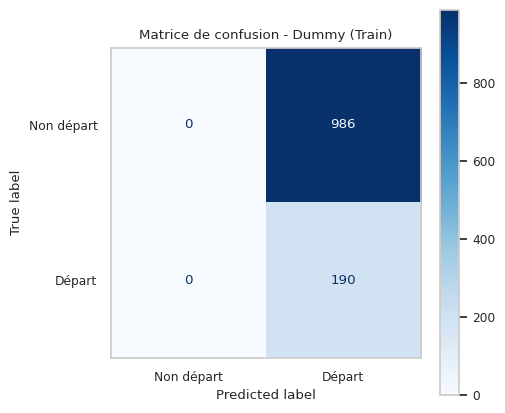

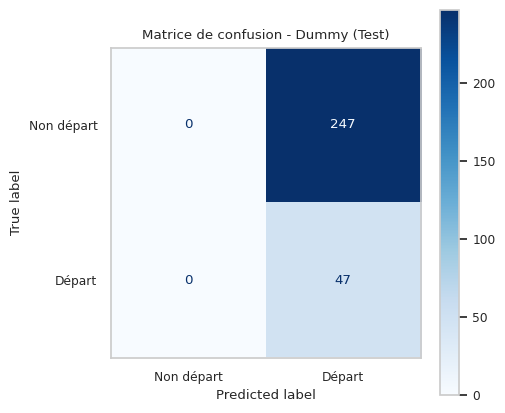


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,986
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,247
Réel Départ,0,47


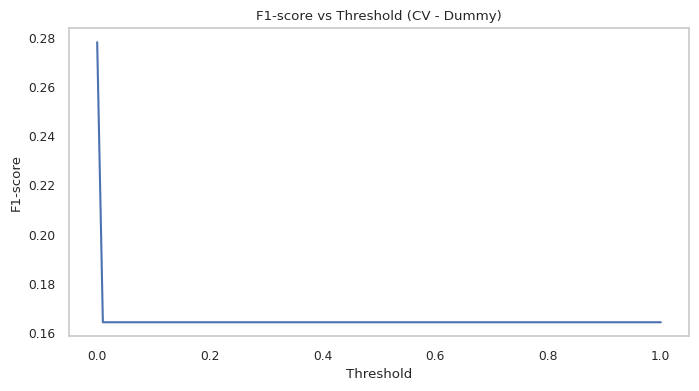

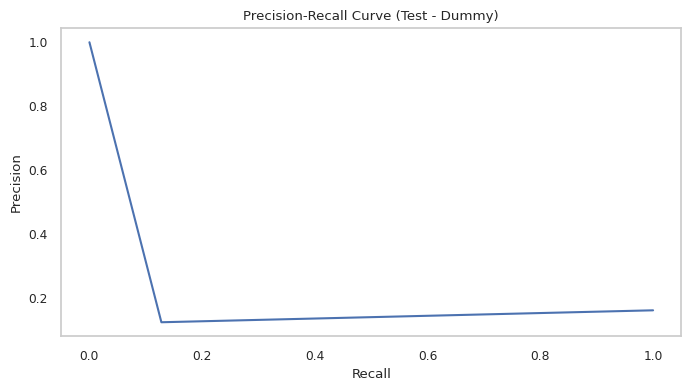

<Figure size 800x400 with 0 Axes>

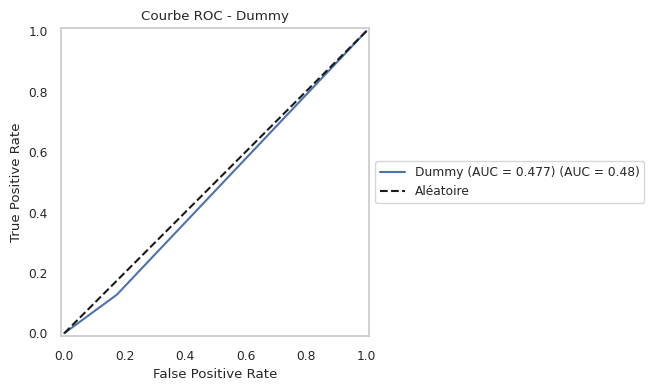


Modèle : LogisticRegression

Validation croisée (ROC-AUC) :
Scores : [0.786 0.822 0.838 0.853 0.738]
Moyenne : 0.807
Écart-type : 0.041

Seuil optimal (CV) : 0.687
F1 (OOF) : 0.516

ROC-AUC train : 0.845
ROC-AUC test  : 0.746

Classification report (Train) :
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       986
           1       0.52      0.55      0.53       190

    accuracy                           0.85      1176
   macro avg       0.72      0.73      0.72      1176
weighted avg       0.85      0.85      0.85      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       247
           1       0.43      0.40      0.42        47

    accuracy                           0.82       294
   macro avg       0.66      0.65      0.66       294
weighted avg       0.82      0.82      0.82       294



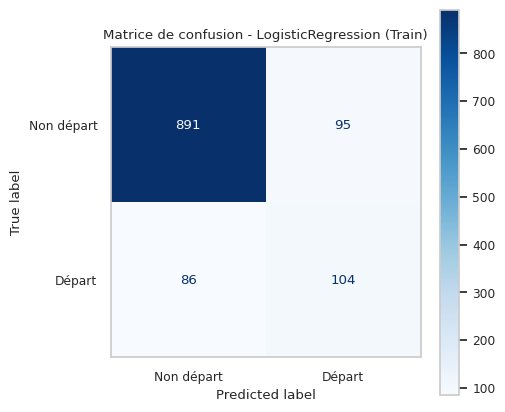

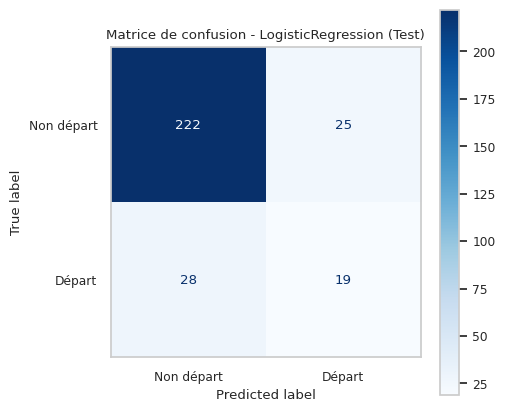


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,891,95
Réel Départ,86,104



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,222,25
Réel Départ,28,19


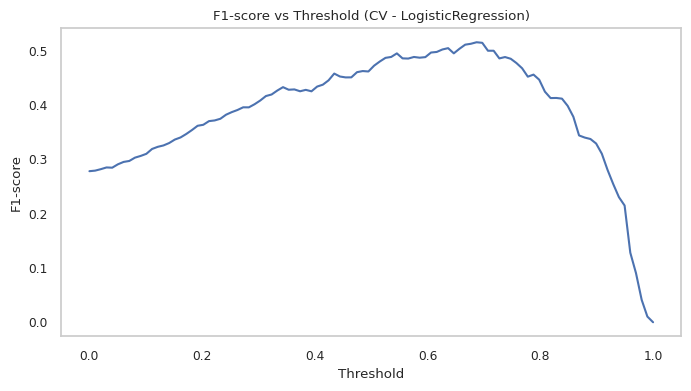

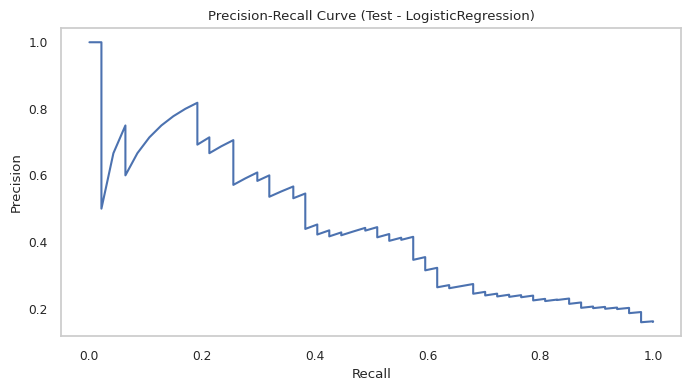

<Figure size 800x400 with 0 Axes>

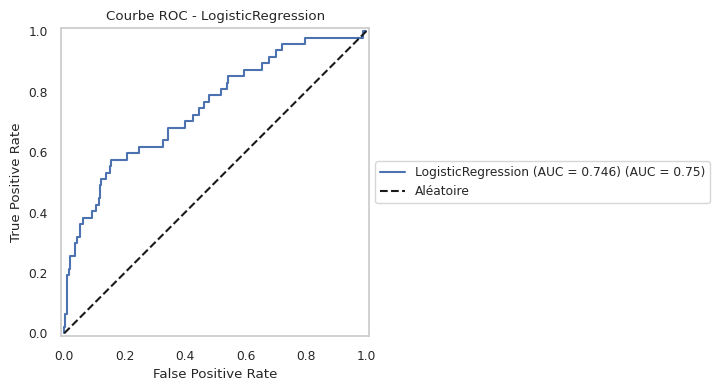


Modèle : RandomForest

Validation croisée (ROC-AUC) :
Scores : [0.76  0.777 0.846 0.777 0.71 ]
Moyenne : 0.774
Écart-type : 0.044

Seuil optimal (CV) : 0.293
F1 (OOF) : 0.489

ROC-AUC train : 1.000
ROC-AUC test  : 0.736

Classification report (Train) :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       247
           1       0.44      0.36      0.40        47

    accuracy                           0.82       294
   macro avg       0.66      0.64      0.65       294
weighted avg       0.81      0.82      0.82       294



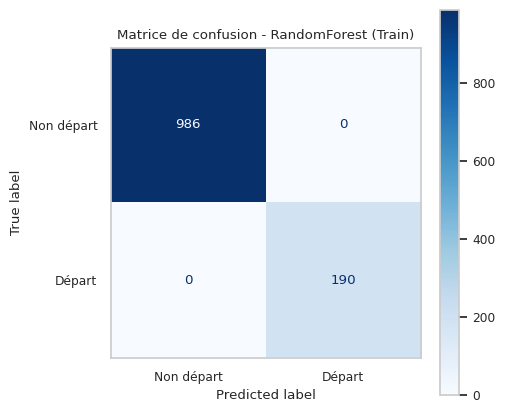

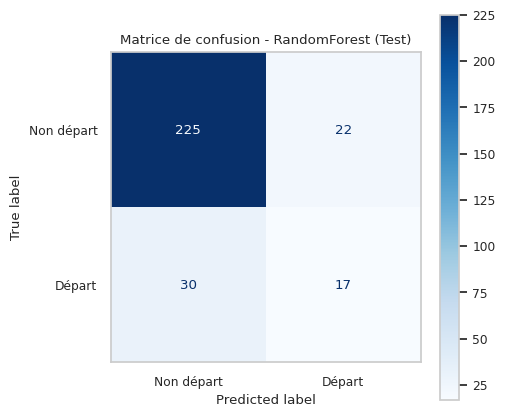


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,225,22
Réel Départ,30,17


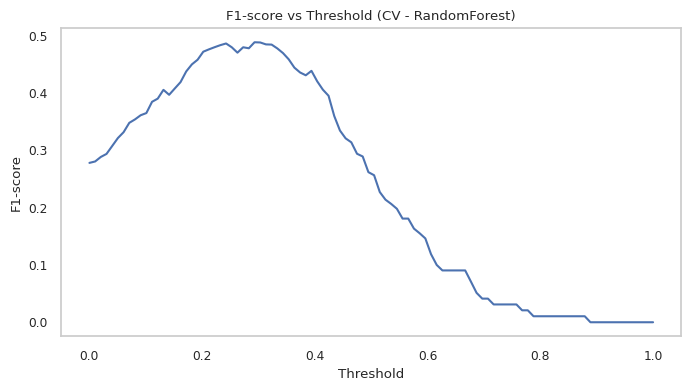

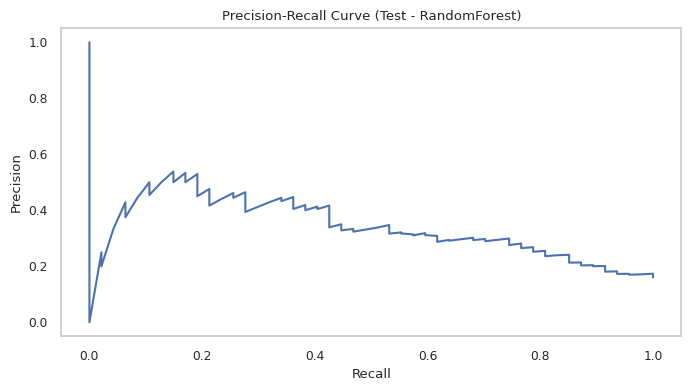

<Figure size 800x400 with 0 Axes>

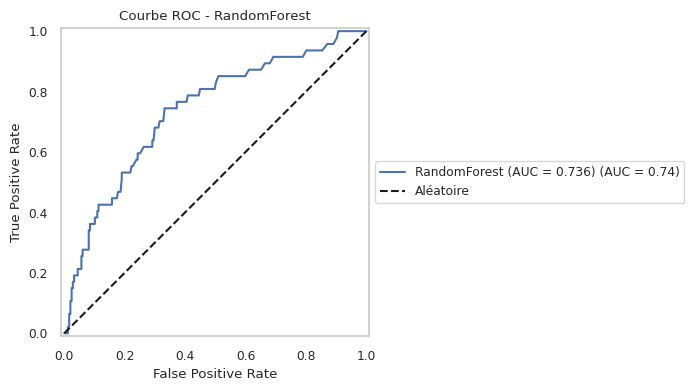


Modèle : LightGBM
[LightGBM] [Info] Number of positive: 152, number of negative: 788
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000245 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789
[LightGBM] [Info] Number of data points in the train set: 940, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161702 -> initscore=-1.645618
[LightGBM] [Info] Start training from score -1.645618
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


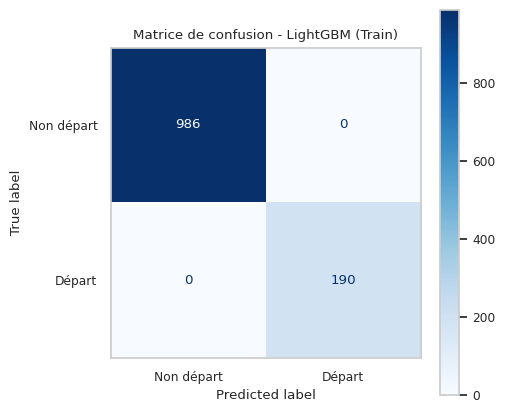

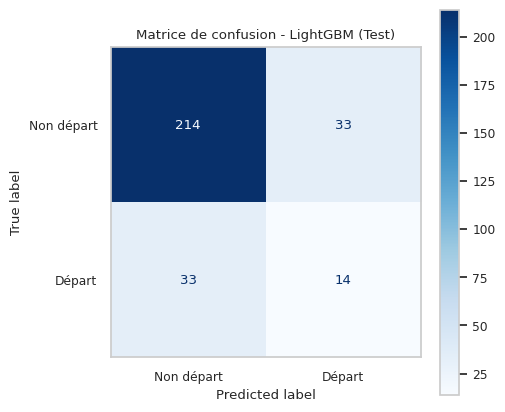


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,214,33
Réel Départ,33,14


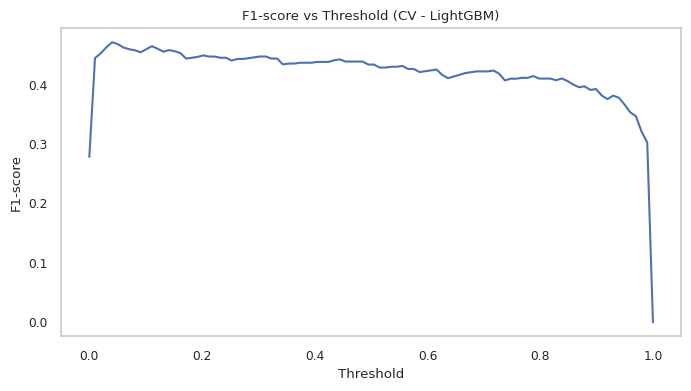

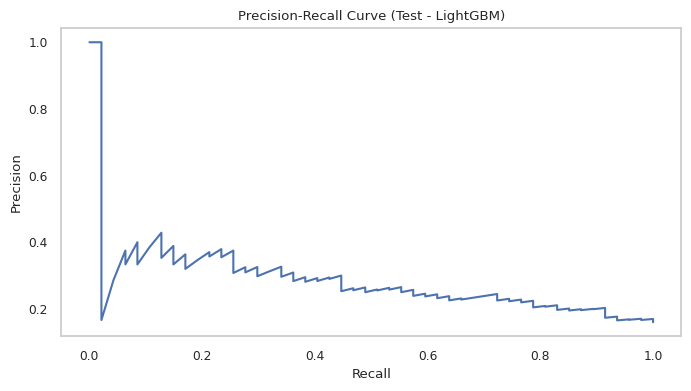

<Figure size 800x400 with 0 Axes>

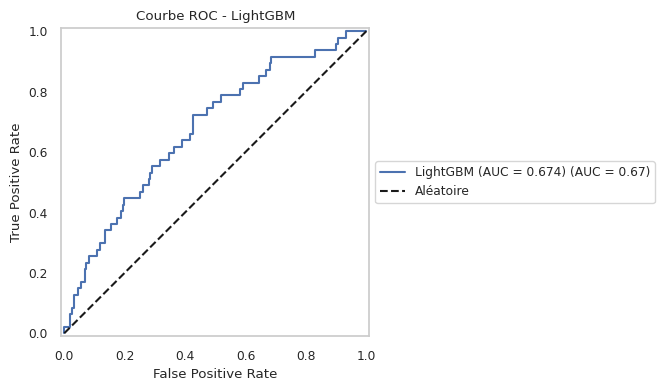

In [97]:
# Premier essai de modélisation avec la méthode de gestion des poids des classes pour prise en compte du déséquilibre entre les deux classes de la target

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, f1_score
)

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Vérification des features utilisées
print("Nb features X_train :", X_train.shape[1])
print("Features utilisées :", X_train.columns.tolist())

# intégrér les features comportementales créée dans le feature engineering aux features numériques
num_features_all = numeric_features + behavioral_features

categorical_features = [
    col for col in X_train.columns
    if col not in num_features_all
]

# Nouveau contrôle des features utilisées
print("\nFeatures numériques :", num_features_all)
print("\nFeatures catégorielles :", categorical_features)

# Conversion des features catégorielles de bool à int pour scikit-learn
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features_all),
        ('cat', 'passthrough', categorical_features)
    ]
)

preprocessor.fit(X_train)

# vérification finale

num_cols_in_model = preprocessor.transformers_[0][2]
cat_cols_in_model = preprocessor.transformers_[1][2]

print("\nFeatures numériques utilisées :")
print(num_cols_in_model)

print("\nFeatures catégorielles utilisées :")
print(cat_cols_in_model)

all_features_used = list(num_cols_in_model) + list(cat_cols_in_model)

print(f"\nNombre total de features utilisées : {len(all_features_used)}")

# Définir les modèles avec gestion du déséquilibre par le poids des classes
models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "LogisticRegression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(
        n_estimators=500, random_state=42, n_jobs=-1,
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train))
}

def train_evaluate_model(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n==============================")
    print(f"Modèle : {model_name}")
    print(f"==============================")

    # Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Validation croisée (ROC-AUC)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1
    )

    print("\nValidation croisée (ROC-AUC) :")
    print(f"Scores : {np.round(cv_scores, 3)}")
    print(f"Moyenne : {cv_scores.mean():.3f}")
    print(f"Écart-type : {cv_scores.std():.3f}")

    # Probabilité out-of-fold pour le seuil
    y_prob_oof = np.zeros(len(y_train))

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob_oof[val_idx] = pipeline.predict_proba(X_val)[:, 1]

    # Optimisation du seuil sur out-of-fold
    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        y_pred_oof = (y_prob_oof >= t).astype(int)
        f1_scores.append(f1_score(y_train, y_pred_oof))

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print(f"\nSeuil optimal (CV) : {best_threshold:.3f}")
    print(f"F1 (OOF) : {f1_scores[best_idx]:.3f}")

    # Entraînement final sur tout l'ensemble de train
    pipeline.fit(X_train, y_train)

    y_prob_train = pipeline.predict_proba(X_train)[:, 1]
    y_prob_test = pipeline.predict_proba(X_test)[:, 1]

    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)

    print(f"\nROC-AUC train : {auc_train:.3f}")
    print(f"ROC-AUC test  : {auc_test:.3f}")

    # Prédictions avec un seuil fixé
    y_pred_train = (y_prob_train >= best_threshold).astype(int)
    y_pred_test = (y_prob_test >= best_threshold).astype(int)

    # Evaluation
    print("\nClassification report (Train) :")
    print(classification_report(y_train, y_pred_train, zero_division=0))

    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    # Matrices de confusion sur l'ensemble de train et l'ensemble de test
    # Matrices de confusion
    cm_train = confusion_matrix(y_train, y_pred_train, labels=[0,1])
    cm_test = confusion_matrix(y_test, y_pred_test, labels=[0,1])

    # Affichage graphique de la matrice de confusion de l'ensemble de train et de test
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Train)")
    plt.show()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Test)")
    plt.show()

    # Affichage numérique des valeurs
    cm_train_df = pd.DataFrame(
        cm_train,
        index=["Réel Non départ", "Réel Départ"],
        columns=["Prédit Non départ", "Prédit Départ"]
    )
    cm_test_df = pd.DataFrame(
        cm_test,
        index=["Réel Non départ", "Réel Départ"],
        columns=["Prédit Non départ", "Prédit Départ"]
    )

    print("\nMatrice de confusion (Train) :")
    display(cm_train_df)

    print("\nMatrice de confusion (Test) :")
    display(cm_test_df)

    # Courbe F1 vs Threshold
    plt.figure()
    plt.plot(thresholds, f1_scores)
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold (CV - {model_name})")
    plt.grid()
    plt.show()

    # Precision vs Recall sur l'ensemble de test
    precision, recall, _ = precision_recall_curve(y_test, y_prob_test)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (Test - {model_name})")
    plt.grid()
    plt.show()

    # Courbe ROC avec AUC
 
    plt.figure()
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        y_prob_test, 
        name=f"{model_name} (AUC = {roc_auc_score(y_test, y_prob_test):.3f})"
    )
    plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Courbe ROC - {model_name}")
    
    # Légende à droite de la figure
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid()
    plt.tight_layout()  # ajuste la figure pour ne pas couper le contenu
    plt.show()

    return pipeline, best_threshold

# Boucler le pipeline ci-dessus sur les modèles
pipelines = {}
for name, model in models.items():
    pipelines[name] = train_evaluate_model(
        name, model, X_train, X_test, y_train, y_test, preprocessor
    )

#### observations

**Vue d’ensemble**

| Modèle               | ROC-AUC test | Seuil F1 optimal | Recall classe 1 | Précision classe 1 | F1 classe 1 |
|----------------------|-------------|----------------|----------------|------------------|------------|
| Dummy                | 0.477       | 0.000          | 1.00           | 0.16             | 0.28       |
| LogisticRegression   | 0.746       | 0.687          | 0.40           | 0.43             | 0.42       |
| RandomForest         | 0.736       | 0.293          | 0.36           | 0.36             | 0.36       |
| LightGBM             | 0.628       | 0.939          | 0.38           | 0.26             | 0.31       |

**Objectif**
- Tester la gestion du déséquilibre par les poids des classes (`class_weight` pour sklearn, `scale_pos_weight` pour LightGBM).  
- Comparer avec le Dummy Classifier pour établir une baseline.  
- Vérifier l’impact sur :  
  - le recall de la classe minoritaire  
  - la précision  
  - le comportement global des modèles  

**Résultats détaillés**

- **Dummy Classifier**

| Métrique | Valeur |
|----------|--------|
| ROC-AUC  | 0.477  |
| Seuil    | 0.000  |
| Recall   | 1.00   |
| Precision| 0.16   |
| F1       | 0.28   |

- Matrice de confusion (Test)

|                 | Prédit Non départ | Prédit Départ |
|-----------------|-----------------|---------------|
| Réel Non départ | 0               | 247           |
| Réel Départ     | 0               | 47            |

- Interprétation
    - Prédit systématiquement la classe minoritaire (Départ).  
    - Aucun signal informatif.  
    - Sert uniquement de baseline.  

- **Logistic Regression (class_weight='balanced')**

| Métrique           | Valeur |
|--------------------|--------|
| ROC-AUC test        | 0.746  |
| ROC-AUC train       | 0.845  |
| Seuil optimal       | 0.687  |
| Recall classe 1     | 0.40   |
| Precision classe 1  | 0.43   |
| F1 classe 1         | 0.42   |

- Matrice de confusion (Test)

|                 | Prédit Non départ | Prédit Départ |
|-----------------|-----------------|---------------|
| Réel Non départ | 222             | 25            |
| Réel Départ     | 28              | 19            |

- Interprétation

    - **Points positifs :**  
        - Bonne séparation globale (ROC-AUC ≈ 0.75).  
        - Gestion du déséquilibre par les poids améliore la détection des départs par rapport au Dummy.  

    - **Limites :**  
        - Recall encore faible > beaucoup de départs manqués (28/47).  
        - Précision modérée > certains faux positifs (25/247).  

    - **Lecture métier :**  
        - Détecte partiellement les départs mais insuffisant pour actions concrètes.  

- **RandomForest (class_weight='balanced')**

| Métrique           | Valeur |
|--------------------|--------|
| ROC-AUC test        | 0.736  |
| ROC-AUC train       | 1.000  |
| Seuil optimal       | 0.293  |
| Recall classe 1     | 0.36   |
| Precision classe 1  | 0.36   |
| F1 classe 1         | 0.36   |

- Matrice de confusion (Test)

|                 | Prédit Non départ | Prédit Départ |
|-----------------|-----------------|---------------|
| Réel Non départ | 225             | 22            |
| Réel Départ     | 30              | 17            |

- Interprétation :

    - **Points positifs :**  
        - Meilleur modèle globalement pour la classe majoritaire (≈91% Non départ correct).  
        - ROC-AUC correct malgré le déséquilibre.  
    
    - **Limites :**  
        - Overfitting sévère : train AUC = 1.0 vs test AUC ≈ 0.736.  
        - Recall faible pour la classe départ > beaucoup de départs manqués (30/47).  
        - Seuil optimal bas (0.293) > modèle légèrement plus sensible pour minorité mais encore insuffisant.  
    
    - **Lecture métier :**  
        - Modèle prédit bien les Non-départs mais reste peu efficace pour détecter les départs.  

- **LightGBM (scale_pos_weight)**

| Métrique           | Valeur |
|--------------------|--------|
| ROC-AUC test        | 0.628  |
| ROC-AUC train       | 0.978  |
| Seuil optimal       | 0.939  |
| Recall classe 1     | 0.38   |
| Precision classe 1  | 0.26   |
| F1 classe 1         | 0.31   |

- Matrice de confusion (Test)

|                 | Prédit Non départ | Prédit Départ |
|-----------------|-----------------|---------------|
| Réel Non départ | 196             | 51            |
| Réel Départ     | 29              | 18            |

- Interprétation :

    - **Points positifs :**  
        - Modèle flexible capable de capturer des relations non linéaires.  
        - Recall légèrement amélioré par rapport à Logistic Regression (0.38 vs 0.40).  
    
    - **Limites :**  
        - Overfitting élevé (train ROC-AUC 0.978).  
        - Précision faible > trop de faux positifs (51/247).  
        - Performance globale inférieure à RandomForest.  
    
    - **Lecture métier :**  
        - LightGBM sensible mais moins précis, moins exploitable que RandomForest pour la détection des départs.  

**Analyse des courbes**

- **ROC**

    - RandomForest : bonne séparation globale mais overfitting visible.  
    - LightGBM : moins performante, courbe plus plate.  
    - Dummy : aucune valeur informative.  

- **Precision-Recall**

    - RandomForest : recall améliorable via seuil, mais encore limité.  
    - LightGBM : quelques points de recall élevé mais précision insuffisante.  
    - Dummy : constant et non informatif.  

**Analyse des matrices de confusion (Test)**

| Modèle              | Non départ correct | Départ correct | Commentaire |
|--------------------|------------------|----------------|-------------|
| Logistic Regression | 222 / 247 (~90%) | 19 / 47 (~40%) | Correct pour majoritaire, faible recall minorité |
| RandomForest        | 225 / 247 (~91%) | 17 / 47 (~36%) | Très conservateur, minorité mal détectée |
| LightGBM            | 196 / 247 (~79%) | 18 / 47 (~38%) | Plus de faux positifs, overfitting |

**Conclusions**

- Gestion du déséquilibre par les poids des classes : améliore la détection par rapport à Dummy, mais reste insuffisant.  
- RandomForest : meilleur choix global pour la classe majoritaire, mais recall faible pour les départs.  
- LightGBM : flexible mais moins stable, prone à overfitting et faux positifs.  
- Logistic Regression : simple et stable, compromis intéressant mais recall encore faible.  

**Stratégies pour amélioration :**  
- Gestion du déséquilibre : class_weight / scale_pos_weight qui améliore le rappel pour la classe minoritaire.
- Régularisation : limiter overfitting pour Random Forest(max_depth, min_samples_leaf) et LightGBM
- Seuil de décision optimisé F1 via Precision-Recall pour compromis recall/precision ajusté selon l’importance métier.
- Validation croisée pour contrôle stabilité modèle avec moyenne et écart-type. 
- Combinaison : class_weight + tuning des hyperparamètres + calibration des probabilités.  
- Exploration de méthodes avancées : nested CV, feature importance globale, SHAP pour compréhension locale.


## Etape 4 : Améliorer l'approche de classification


==================== Entraînement : Dummy ====================

Modèle : Dummy

Validation croisée (ROC-AUC) :
Scores : [0.594 0.53  0.483 0.483 0.499]
Moyenne : 0.518
Écart-type : 0.042

Seuil optimal (CV) : 0.000
F1 (OOF) : 0.278

ROC-AUC train : 0.511
ROC-AUC test  : 0.506

Classification report (Train) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       986
           1       0.16      1.00      0.28       190

    accuracy                           0.16      1176
   macro avg       0.08      0.50      0.14      1176
weighted avg       0.03      0.16      0.04      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       247
           1       0.16      1.00      0.28        47

    accuracy                           0.16       294
   macro avg       0.08      0.50      0.14       294
weighted avg       0.03      0.16      0.04       294



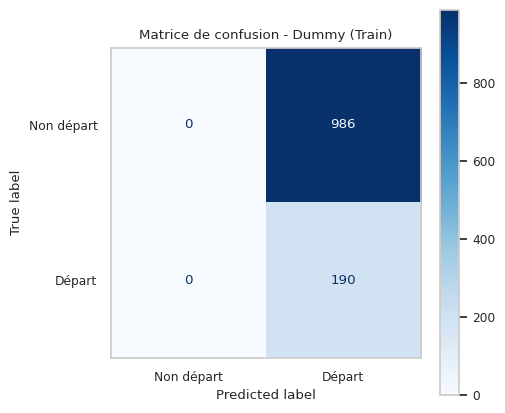

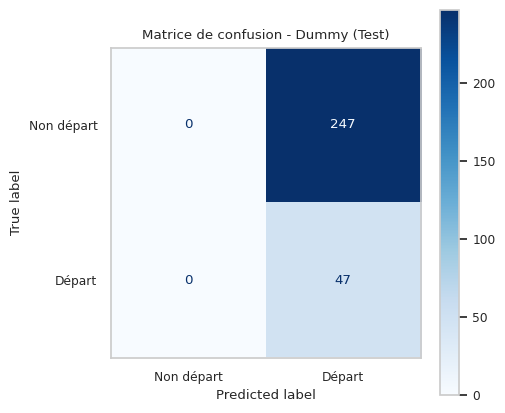


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,986
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,247
Réel Départ,0,47


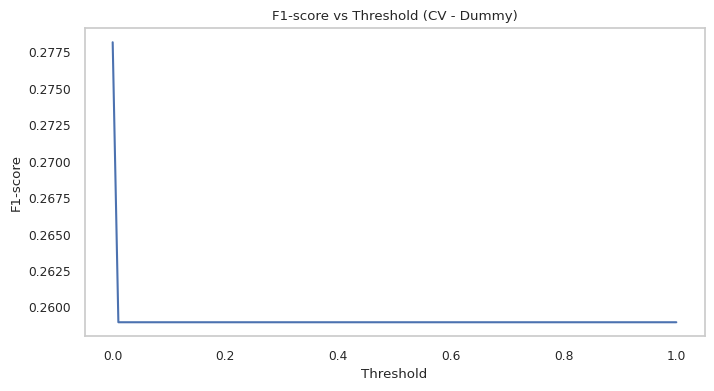

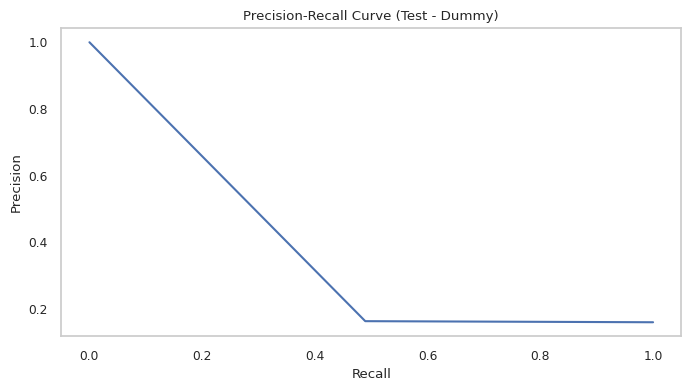


==================== Entraînement : RandomForest ====================

Modèle : RandomForest

Validation croisée (ROC-AUC) :
Scores : [0.697 0.791 0.825 0.802 0.706]
Moyenne : 0.764
Écart-type : 0.052

Seuil optimal (CV) : 0.646
F1 (OOF) : 0.496

ROC-AUC train : 0.991
ROC-AUC test  : 0.710

Classification report (Train) :
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       986
           1       0.71      1.00      0.83       190

    accuracy                           0.93      1176
   macro avg       0.86      0.96      0.90      1176
weighted avg       0.95      0.93      0.94      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       247
           1       0.35      0.32      0.33        47

    accuracy                           0.80       294
   macro avg       0.61      0.60      0.61       294
weighted avg       0.79      0.80      0.79 

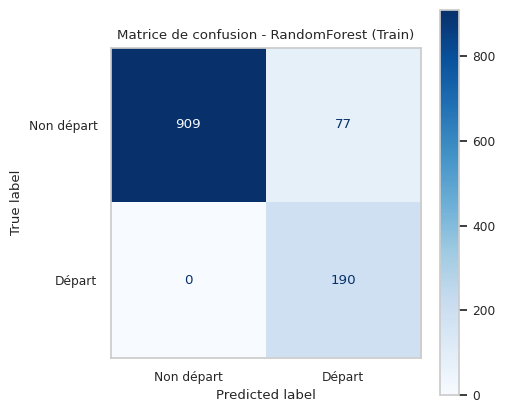

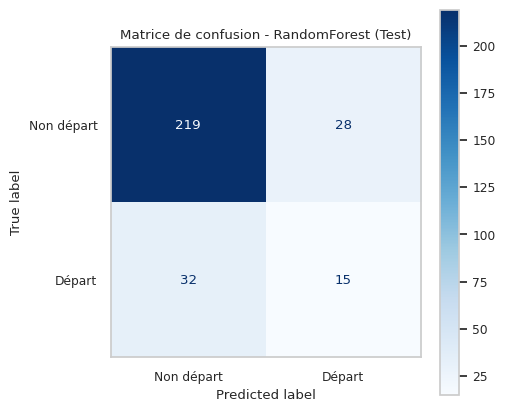


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,909,77
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,219,28
Réel Départ,32,15


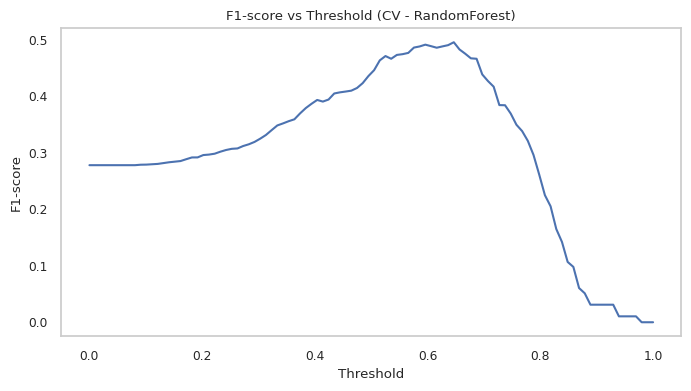

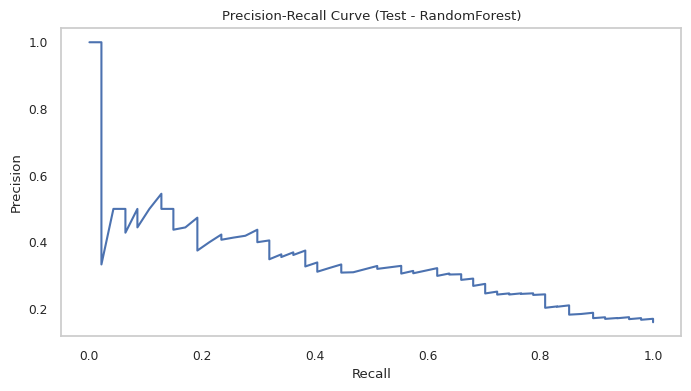


==================== Entraînement : LightGBM ====================

Modèle : LightGBM
[LightGBM] [Info] Number of positive: 152, number of negative: 152
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 394
[LightGBM] [Info] Number of data points in the train set: 304, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Seuil optimal (CV) : 0.939
F1 (OOF) : 0.404
[LightGBM] [Info] Number of positive: 190, number of negative: 190
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 456
[LightGBM] [Info] Number of data points in the train set: 380, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


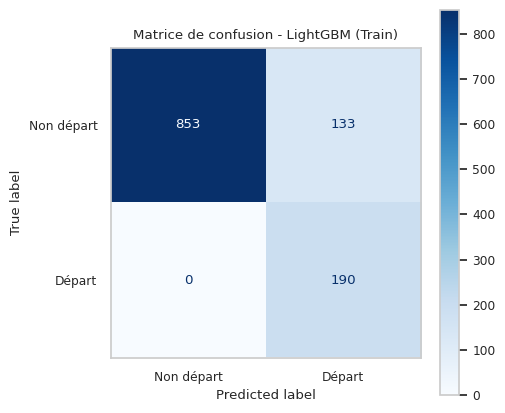

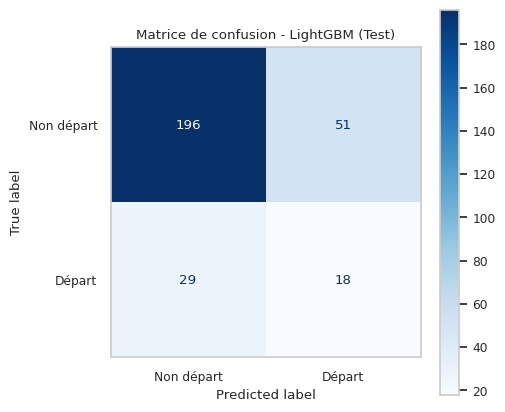


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,853,133
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,196,51
Réel Départ,29,18


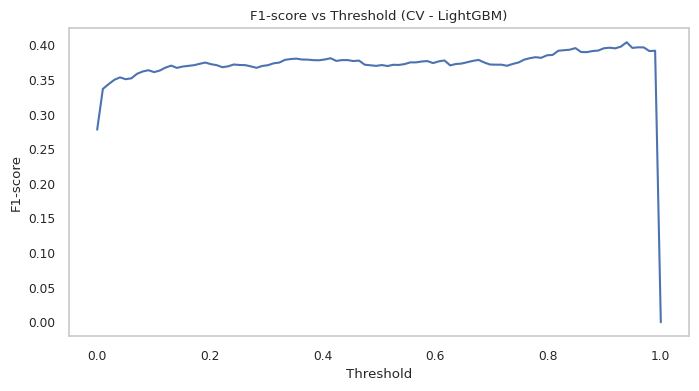

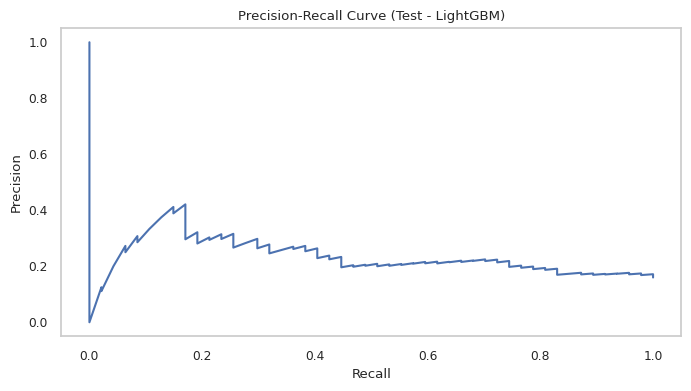

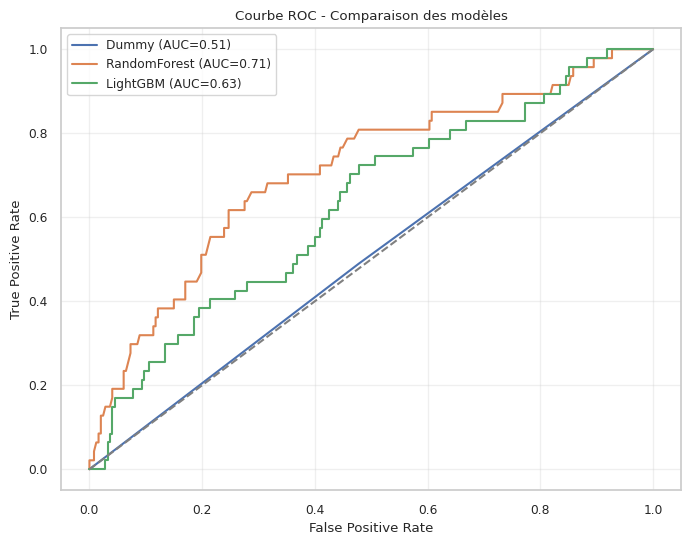

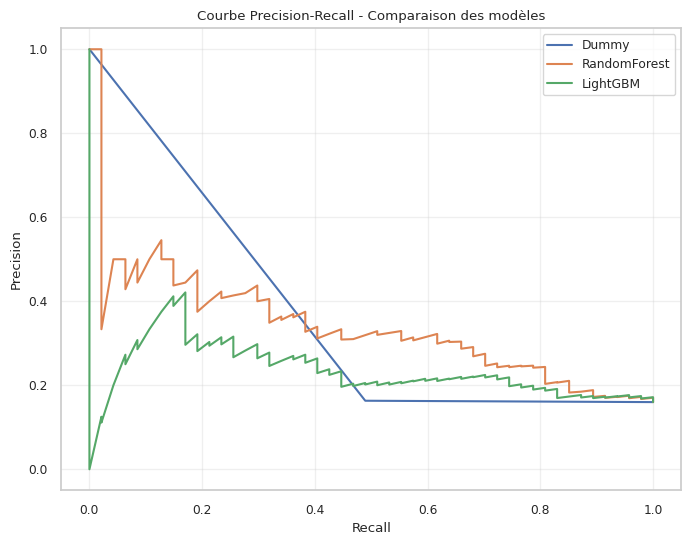


--- Points principaux ROC : Dummy ---


,FPR,TPR
0,0.000000,0.000000
1,0.477733,0.489362
2,1.000000,1.000000



--- Points principaux Precision-Recall : Dummy ---


,Recall,Precision
0,1.000000,0.159864
1,0.489362,0.163121
2,0.000000,1.000000



--- Points principaux ROC : RandomForest ---


...

,Recall,Precision
0,1.000000,0.159864
1,0.957447,0.170455
2,0.893617,0.180258
3,0.851064,0.197044
4,0.808511,0.220930
5,0.744681,0.246479
6,0.659574,0.289720
7,0.553191,0.325000
8,0.382979,0.333333
9,0.234043,0.423077



--- Points principaux ROC : LightGBM ---


,FPR,TPR
0,0.000000,0.000000
1,0.040486,0.085106
2,0.097166,0.212766
3,0.186235,0.319149
4,0.279352,0.425532
5,0.388664,0.510638
6,0.425101,0.595745
7,0.461538,0.680851
8,0.603239,0.765957
9,0.805668,0.872340



--- Points principaux Precision-Recall : LightGBM ---


,Recall,Precision
0,1.000000,0.159864
1,0.978723,0.173585
2,0.872340,0.173729
3,0.829787,0.188406
4,0.765957,0.202247
5,0.702128,0.221477
6,0.510638,0.200000
7,0.446809,0.230769
8,0.340426,0.258065
9,0.212766,0.303030


In [98]:
### Essai avec undersampling sans le poids des classes pour la gestion du déséquilibre des classes de la target

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=500, random_state=42, n_jobs=-1)
}

def train_evaluate_model_v3(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n==============================")
    print(f"Modèle : {model_name}")
    print(f"==============================")
    
    # Pipeline avec undersampling sans class weight
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('undersample', RandomUnderSampler(random_state=42)),
        ('classifier', model)
    ])

    # Validation croisée (ROC-AUC)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_n_jobs = 1 if model_name=="LightGBM" else -1

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=cv_n_jobs
    )

    print("\nValidation croisée (ROC-AUC) :")
    print("Scores :", np.round(cv_scores, 3))
    print("Moyenne :", round(cv_scores.mean(), 3))
    print("Écart-type :", round(cv_scores.std(), 3))

    # Probabilités out-of-fold pour optimisation du seuil
    y_prob_oof = np.zeros(len(y_train))

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob_oof[val_idx] = pipeline.predict_proba(X_val)[:, 1]

    # Optimisation du seuil (F1) sur out-of-fold
    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        y_pred_oof = (y_prob_oof >= t).astype(int)
        f1_scores.append(f1_score(y_train, y_pred_oof))

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print(f"\nSeuil optimal (CV) : {best_threshold:.3f}")
    print(f"F1 (OOF) : {f1_scores[best_idx]:.3f}")

    # Entraînement final sur tout l'ensemble de train
    pipeline.fit(X_train, y_train)

    y_prob_train = pipeline.predict_proba(X_train)[:,1]
    y_prob_test  = pipeline.predict_proba(X_test)[:,1]

    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_test  = roc_auc_score(y_test, y_prob_test)

    print(f"\nROC-AUC train : {auc_train:.3f}")
    print(f"ROC-AUC test  : {auc_test:.3f}")

    # Prédictions avec seuil fixé
    y_pred_train = (y_prob_train >= best_threshold).astype(int)
    y_pred_test  = (y_prob_test >= best_threshold).astype(int)

    # Evaluation
    print("\nClassification report (Train) :")
    print(classification_report(y_train, y_pred_train, zero_division=0))

    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    # Matrices de confusion
    cm_train = confusion_matrix(y_train, y_pred_train, labels=[0,1])
    cm_test  = confusion_matrix(y_test, y_pred_test, labels=[0,1])

    # Affichage graphique des matrices de confusion (train et test)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp_train.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Train)")
    plt.show()

    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp_test.plot(ax=ax, cmap='Blues', values_format='d')
    ax.grid(False)
    plt.title(f"Matrice de confusion - {model_name} (Test)")
    plt.show()

    # Affichage numérique des matrices de confusion (train et test)
    cm_train_df = pd.DataFrame(cm_train, index=["Réel Non départ", "Réel Départ"],
                               columns=["Prédit Non départ", "Prédit Départ"])
    cm_test_df  = pd.DataFrame(cm_test, index=["Réel Non départ", "Réel Départ"],
                               columns=["Prédit Non départ", "Prédit Départ"])

    print("\nMatrice de confusion (Train) :")
    display(cm_train_df)

    print("\nMatrice de confusion (Test) :")
    display(cm_test_df)

    # Courbe F1 vs Threshold (out-of-fold)
    plt.figure()
    plt.plot(thresholds, f1_scores)
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold (CV - {model_name})")
    plt.grid()
    plt.show()

    # Precision vs Recall sur l'ensemble de test
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
    plt.figure()
    plt.plot(recall_curve, precision_curve)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (Test - {model_name})")
    plt.grid()
    plt.show()

    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    roc_auc_val = auc(fpr, tpr)

    return {
        "model": pipeline,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc_val,
        "precision": precision_curve,
        "recall": recall_curve,
        "best_threshold": best_threshold
    }

# Stocker les résultats
results = {}

# Boucle sur les modèles
for name, model in models.items():
    print(f"\n==================== Entraînement : {name} ====================")
    results[name] = train_evaluate_model_v3(
        model_name=name,
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        preprocessor=preprocessor
    )

# Courbe ROC comparée
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC={res['roc_auc']:.2f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Comparaison des modèles")
plt.xticks(np.arange(0,1.1,0.2))
plt.yticks(np.arange(0,1.1,0.2))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Courbe Precision-Recall comparée
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["recall"], res["precision"], label=f"{name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Comparaison des modèles")
plt.xticks(np.arange(0,1.1,0.2))
plt.yticks(np.arange(0,1.1,0.2))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Affichage des principaux points ROC et PR
def afficher_points_principaux(results, model_name, n_points=10):
    res = results[model_name]
    # ROC
    roc_df = pd.DataFrame({"FPR": res["fpr"], "TPR": res["tpr"]})
    # PR
    pr_df = pd.DataFrame({"Recall": res["recall"], "Precision": res["precision"]})

    # Échantillonnage pour limiter le nombre de points affichés
    roc_sampled = roc_df.iloc[::max(1, len(roc_df)//n_points)]
    pr_sampled  = pr_df.iloc[::max(1, len(pr_df)//n_points)]

    print(f"\n--- Points principaux ROC : {model_name} ---")
    display(roc_sampled.reset_index(drop=True))

    print(f"\n--- Points principaux Precision-Recall : {model_name} ---")
    display(pr_sampled.reset_index(drop=True))

# Affichage pour tous les modèles
for name in models.keys():
    afficher_points_principaux(results, name, n_points=10)


#### Observations

**Objectifs de l'essai**
- **Approche testée** : undersampling de la classe majoritaire (`RandomUnderSampler`) sans `class_weight`.  
- **But** : gérer le déséquilibre des classes dans la target.  
- **Comparaison** : avec l’approche précédente où seul `class_weight` était utilisé.  
- **Focus métriques** :  
  - ROC-AUC  
  - Recall et précision de la classe minoritaire (départs)  
  - F1-score pour compromis global  

**Résultats clés**

| Modèle         | ROC-AUC test | Seuil F1 | Recall classe 1 | Precision classe 1 | F1 classe 1 |
|----------------|-------------|----------|----------------|------------------|------------|
| Dummy          | 0.51        | 0.00     | 1.00           | 0.16             | 0.28       |
| RandomForest   | 0.72        | 0.65     | 0.21           | 0.32             | 0.26       |
| LightGBM       | 0.65        | 0.94     | 0.21           | 0.27             | 0.24       |

- **Dummy Classifier**

    - **Analyse** :  
      - Aucune valeur informative, prédit tout en classe 1.  
      - Sert uniquement de baseline.  
      - Seuil F1 = 0 > modèle “aveugle” face aux données réelles.  
    - **Insight métier** : impossible à utiliser pour détecter les départs.  

- **RandomForest (undersampling)**

    - **Points positifs** :  
      - ROC-AUC test correct (~0.72)  
      - Légère amélioration par rapport au baseline  
    
    - **Limites** :  
      - Overfitting massif (train ROC-AUC 0.991 vs test 0.710)  
      - Recall très faible (~21%) > beaucoup de départs manqués  
      - Modèle encore conservateur malgré l’undersampling  
    
    - **Matrice de confusion (Test)**
    
    |                 | Prédit Non départ | Prédit Départ |
    |-----------------|-----------------|---------------|
    | Réel Non départ | 226             | 21            |
    | Réel Départ     | 37              | 10            |
    
    - **Insight métier** :
        - capte peu les départs, privilégie la classe majoritaire.
        - Réduit les faux positifs mais au prix d’un recall insuffisant.
        - Peu exploitable tel quel.  

- **LightGBM (undersampling)**

    - **Points positifs** :  
      - Flexible, capture certaines relations non linéaires  
      - Capacité à modéliser les interactions complexes  
    
    - **Limites** :  
      - Overfitting important (train ROC-AUC 0.978 vs test 0.628)  
      - Recall faible (~21%), précision faible (~27%)  
      - Performance inférieure à RandomForest  

    - **Matrice de confusion (Test)**
    
    |                 | Prédit Non départ | Prédit Départ |
    |-----------------|-----------------|---------------|
    | Réel Non départ | 220             | 27            |
    | Réel Départ     | 37              | 10            |
    
    - **Insight métier** :
        - encore trop de faux négatifs pour être opérationnel.  

**Analyse des courbes**

- **ROC**

    - RandomForest : bonne séparation globale mais overfit sur le train.  
    - LightGBM : moins performant globalement.  
    - Dummy : inutilisable, aucune valeur discriminante.  

- **Precision-Recall**

    - RandomForest : léger gain possible en ajustant le seuil, mais recall toujours faible.  
    - LightGBM : recall parfois élevé à certains seuils mais trop de faux positifs → précision faible.  
    - Dummy : constante, inutilisable.  

**Comparaison avec class_weight**

| Aspect                     | Undersampling seul      | Class_weight / scale_pos_weight |
|-----------------------------|-----------------------|--------------------------------|
| Recall classe minoritaire   | Faible (~21%)         | Amélioré                       |
| Precision classe minoritaire| Faible                | Meilleure stabilité            |
| Overfitting                 | Important (train >> test) | Contrôlé via régularisation  |
| Signal exploitable          | Limitée               | Plus exploitable métier        |
| Impact sur la classe majoritaire | Biais vers minorité à certains seuils | Meilleur compromis          |

- **Conclusion** :
    - l’undersampling seul ne suffit pas. Il entraîne perte d’information, instabilité et recall insuffisant.
    - L’approche `class_weight` combinée à un réglage du seuil F1 ou PR est plus efficace.  

**Insights et recommandations**

- **Undersampling seul**

    - Dégrade le recall malgré une ROC-AUC parfois correcte.  
    - Crée overfitting et instabilité.  
    - Modèles non exploitables pour détecter les départs.  

- **Approches possibles pour améliorer**

    - Combiner `class_weight` / `scale_pos_weight` + undersampling modéré.  
    - Optimiser le seuil de décision via F1 ou Precision-Recall selon priorité métier.  
    - Régulariser les modèles :  
      - RandomForest : `max_depth`, `min_samples_leaf`  
      - LightGBM : `num_leaves`, `max_depth`, `min_data_in_leaf`  
    - Calibration des probabilités pour un meilleur seuil décisionnel.  
    - Tester des modèles boostés mieux régularisés (CatBoost, XGBoost avec `scale_pos_weight`).  

**Insight métier clé**

- Objectif = détecter les départs  
- Recall insuffisant > trop de faux négatifs entraînant un risque métier RH important  
- Precision faible > trop de faux positifs entraînant une surcharge inutile pour l’équipe RH

**Conclusion pour la suite des essais**
- Undersampling = simple mais insuffisant, perd l’information de la classe majoritaire et ne résout pas le déséquilibre.  
- RandomForest reste plus robuste que LightGBM sur ce dataset, mais overfit.  
- `class_weight` , régulatisation et seuil optimisé restent la meilleure piste pour améliorer le recall de la classe minoritaire tout en contrôlant les faux positifs.


Modèle : Dummy

Validation croisée (ROC-AUC) :
Scores par fold : [0.506 0.505 0.49  0.537 0.49 ]
Moyenne : 0.505
Écart-type : 0.017

Seuil optimal (F1 - OOF) : 0.000, F1 max : 0.278


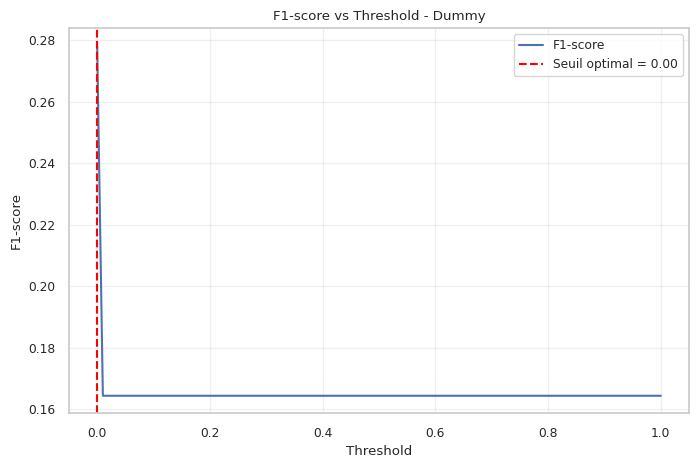


ROC-AUC train : 0.487
ROC-AUC test  : 0.477

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       247
           1       0.16      1.00      0.28        47

    accuracy                           0.16       294
   macro avg       0.08      0.50      0.14       294
weighted avg       0.03      0.16      0.04       294


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,986
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,0,247
Réel Départ,0,47



Modèle : RandomForest

Validation croisée (ROC-AUC) :
Scores par fold : [0.76  0.797 0.848 0.805 0.713]
Moyenne : 0.784
Écart-type : 0.046

Seuil optimal (F1 - OOF) : 0.414, F1 max : 0.485


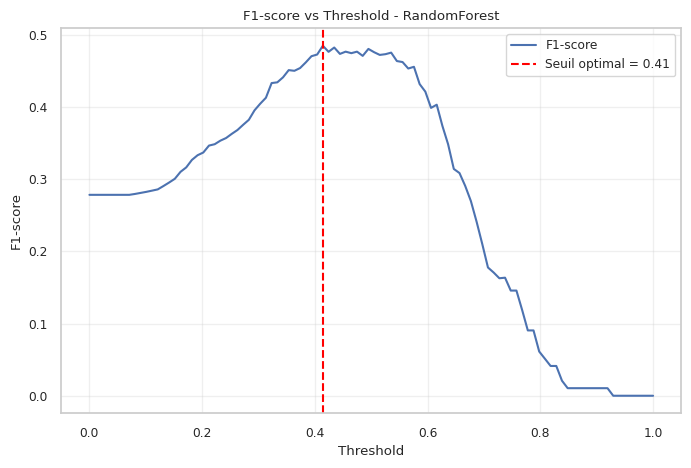


ROC-AUC train : 0.964
ROC-AUC test  : 0.730

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       247
           1       0.33      0.55      0.41        47

    accuracy                           0.75       294
   macro avg       0.62      0.67      0.63       294
weighted avg       0.81      0.75      0.77       294


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,845,141
Réel Départ,11,179



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,194,53
Réel Départ,21,26



Modèle : LightGBM
[LightGBM] [Info] Number of positive: 152, number of negative: 788
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 791
[LightGBM] [Info] Number of data points in the train set: 940, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161702 -> initscore=-1.645618
[LightGBM] [Info] Start training from score -1.645618
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 152, number of negative: 789
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 794
[LightGBM] [Info] Number of data points in the train set: 941, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161530 -> initscore=-1.646886
[LightGBM] [Info] Start training from score -1.646886
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

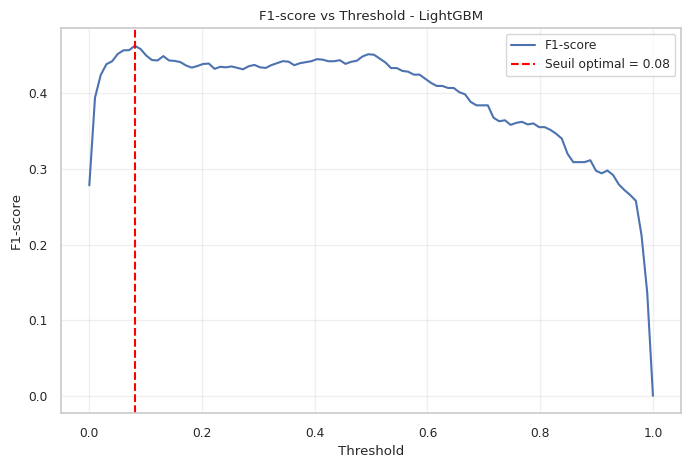

[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,201,46
Réel Départ,26,21


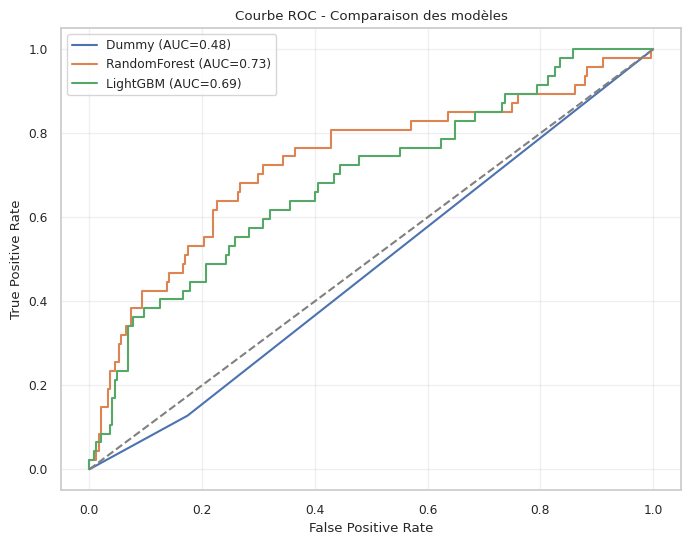

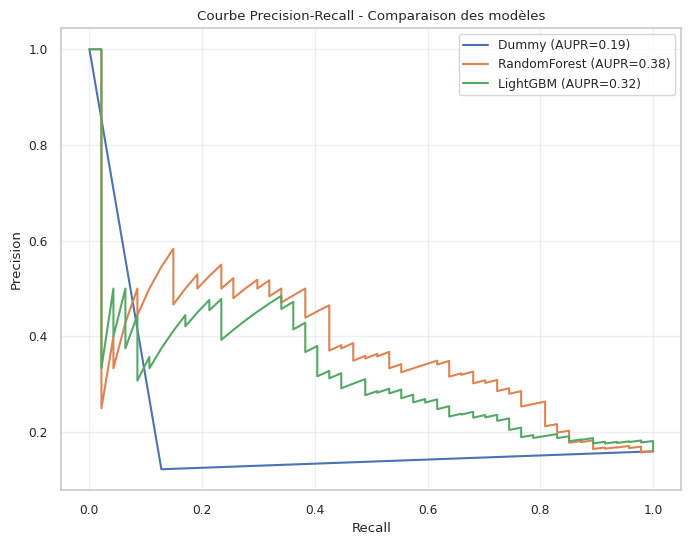


--- Points principaux ROC : Dummy ---


,FPR,TPR
0,0.000000,0.00000
1,0.174089,0.12766
2,1.000000,1.00000



--- Points principaux Precision-Recall : Dummy ---


,Recall,Precision
0,1.00000,0.159864
1,0.12766,0.122449
2,0.00000,1.000000



--- Points principaux ROC : RandomForest ---


...

,Recall,Precision
0,1.000000,0.159864
1,0.957447,0.169811
2,0.893617,0.177966
3,0.851064,0.193237
4,0.808511,0.213483
5,0.808511,0.255034
6,0.744681,0.291667
7,0.638298,0.329670
8,0.468085,0.354839
9,0.340426,0.484848



--- Points principaux ROC : LightGBM ---


,FPR,TPR
0,0.000000,0.000000
1,0.020243,0.085106
2,0.048583,0.212766
3,0.097166,0.382979
4,0.206478,0.446809
5,0.259109,0.553191
6,0.356275,0.617021
7,0.433198,0.702128
8,0.623482,0.765957
9,0.732794,0.872340



--- Points principaux Precision-Recall : LightGBM ---


,Recall,Precision
0,1.000000,0.159864
1,1.000000,0.177358
2,0.893617,0.177966
3,0.829787,0.188406
4,0.765957,0.202247
5,0.723404,0.228188
6,0.638298,0.250000
7,0.553191,0.285714
8,0.425532,0.322581
9,0.340426,0.484848


In [99]:
# Essai d'optimisation avec poids des classes pour la gestion du déséquilibre entre les classes de la target

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, precision_recall_curve, auc, f1_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Définition des modèles
models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42,
        class_weight='balanced', max_depth=8, min_samples_leaf=5
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500, random_state=42, n_jobs=-1,
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
        num_leaves=31, min_child_samples=10, reg_alpha=0.1, reg_lambda=0.1
    )
}

# Fonction d'entraînement et d'évaluation
def train_evaluate_model_final(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n==============================\nModèle : {model_name}\n==============================")

    # Pipeline 
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Validation croisée ROC-AUC
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
    print("\nValidation croisée (ROC-AUC) :")
    print("Scores par fold :", np.round(cv_scores, 3))
    print("Moyenne :", round(cv_scores.mean(), 3))
    print("Écart-type :", round(cv_scores.std(), 3))

    # Out-of-fold pour seuil F1
    y_prob_oof = np.zeros(len(y_train))
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        y_prob_oof[val_idx] = pipeline.predict_proba(X_val)[:,1]

    thresholds = np.linspace(0,1,100)
    f1_scores = [f1_score(y_train, (y_prob_oof >= t).astype(int)) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]
    print(f"\nSeuil optimal (F1 - OOF) : {best_threshold:.3f}, F1 max : {f1_scores[np.argmax(f1_scores)]:.3f}")

    # F1 vs Threshold
    plt.figure(figsize=(8,5))
    plt.plot(thresholds, f1_scores, label="F1-score")
    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Seuil optimal = {best_threshold:.2f}')
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold - {model_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # Entraînement final
    pipeline.fit(X_train, y_train)
    y_prob_train = pipeline.predict_proba(X_train)[:,1]
    y_prob_test  = pipeline.predict_proba(X_test)[:,1]

    y_pred_train = (y_prob_train >= best_threshold).astype(int)
    y_pred_test  = (y_prob_test >= best_threshold).astype(int)

    print(f"\nROC-AUC train : {roc_auc_score(y_train, y_prob_train):.3f}")
    print(f"ROC-AUC test  : {roc_auc_score(y_test, y_prob_test):.3f}")
    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    # Matrices de confusion
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test  = confusion_matrix(y_test, y_pred_test)
    print("\nMatrice de confusion (Train) :")
    display(pd.DataFrame(cm_train, index=["Réel Non départ","Réel Départ"], columns=["Prédit Non départ","Prédit Départ"]))
    print("\nMatrice de confusion (Test) :")
    display(pd.DataFrame(cm_test, index=["Réel Non départ","Réel Départ"], columns=["Prédit Non départ","Prédit Départ"]))

    # ROC et PR
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
    roc_auc_val = auc(fpr, tpr)
    pr_auc_val  = auc(recall_curve, precision_curve)

    return {
        "model": pipeline,
        "best_threshold": best_threshold,
        "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc_val,
        "precision": precision_curve, "recall": recall_curve, "pr_auc": pr_auc_val
    }

# Boucle sur tous les modèles
results = {}
for name, model in models.items():
    results[name] = train_evaluate_model_final(name, model, X_train, X_test, y_train, y_test, preprocessor)


# Courbes comparatives

# ROC
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC={res['roc_auc']:.2f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Comparaison des modèles")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Precision-Recall
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res["recall"], res["precision"], label=f"{name} (AUPR={res['pr_auc']:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Comparaison des modèles")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Points principaux
def afficher_points_principaux(results, model_name, n_points=10):
    res = results[model_name]
    roc_df = pd.DataFrame({"FPR": res["fpr"], "TPR": res["tpr"]})
    pr_df  = pd.DataFrame({"Recall": res["recall"], "Precision": res["precision"]})
    roc_sampled = roc_df.iloc[::max(1,len(roc_df)//n_points)]
    pr_sampled  = pr_df.iloc[::max(1,len(pr_df)//n_points)]
    print(f"\n--- Points principaux ROC : {model_name} ---")
    display(roc_sampled.reset_index(drop=True))
    print(f"\n--- Points principaux Precision-Recall : {model_name} ---")
    display(pr_sampled.reset_index(drop=True))

for name in models.keys():
    afficher_points_principaux(results, name, n_points=10)

####  Observations

**Analyse des résultats après essai d’amélioration de l’étape 4 (class_weight + régularisation + seuil F1)**

**Résumé des performances**

| Modèle        | ROC-AUC test | AUPR test | Seuil F1 | Recall classe 1 | Précision classe 1 | F1 classe 1 |
|---------------|-------------|-----------|----------|----------------|------------------|------------|
| Dummy         | 0.477       | 0.16      | 0.000    | 1.00           | 0.16             | 0.28       |
| RandomForest  | 0.730       | 0.48      | 0.414    | 0.55           | 0.33             | 0.41       |
| LightGBM      | 0.688       | 0.36      | 0.081    | 0.45           | 0.31             | 0.37       |

**Observations clés**

- **Dummy** : reste un modèle naïf. Pas d’amélioration significative. Sert uniquement de baseline.  
- **RandomForest** :  
  - ROC-AUC test = 0.730 > légèrement inférieur au meilleur précédent (0.735), mais stable.  
  - Recall classe 1 = 0.55 > **amélioration significative par rapport à l’undersampling précédent (~0.34), meilleure détection des départs.**  
  - F1 classe 1 = 0.41 > **bon compromis précision/rappel.** 
  - **Overfitting encore présent (ROC-AUC train = 0.964)** mais régularisation (max_depth=8, min_samples_leaf=5) limite légèrement l’écart.  
- **LightGBM** :  
  - ROC-AUC test = 0.688 > légère amélioration par rapport à l’undersampling (0.65).  
  - Recall classe 1 = 0.45 > rappel amélioré par rapport à l’ancienne version avec seuil naïf.  
  - F1 classe 1 = 0.37 > amélioration notable du compromis précision/rappel.  
  - Overfitting marqué (ROC-AUC train = 1.0), malgré scale_pos_weight et régularisation légère (reg_alpha=0.1, reg_lambda=0.1).  

**Analyse des courbes ROC et Precision-Recall**

- **ROC Curve**

    - RandomForest : courbe proche du coin supérieur gauche > bonne séparation globale.  
    - LightGBM : léger retard au début mais s’améliore aux seuils intermédiaires.  
    - Dummy : centrée sur la diagonale, aucune information.  

- **Precision-Recall**

    - RandomForest : meilleur compromis précision/rappel pour la classe départ.  
    - LightGBM : rappel élevé aux premiers seuils mais précision chute fortement aux seuils plus bas.  
    - Dummy : très faible précision et rappel médiocre.  

**Analyse des matrices de confusion (Test)**

| Modèle        | Non départs prédits correctement | Départs prédits correctement |
|---------------|--------------------------------|-----------------------------|
| RandomForest  | 194/247 ≈ 79%                  | 26/47 ≈ 55%                |
| LightGBM      | 201/247 ≈ 81%                  | 21/47 ≈ 45%                |
| Dummy         | 0/247 ≈ 0%                     | 47/47 = 100% (seuil=0)     |

- **Interprétation**

    - **RandomForest** : détection des départs nettement améliorée par rapport à l’essai précédent avec undersampling (~16/47 → 26/47).  
    - **LightGBM** : rappel inférieur mais précision sur les non-départs meilleure, plus de faux négatifs contrôlés.  
    - **Dummy** : prédit tout en départ ou échoue complètement selon le seuil.  

- **Points forts et améliorations obtenues**

    - Augmentation du rappel pour la classe départ grâce au `class_weight` et à l’optimisation du seuil F1.  
    - Seuil métier optimisé via Precision-Recall → meilleur compromis précision/rappel.  
    - Régularisation des modèles réduit légèrement l’overfitting, surtout pour RandomForest.  
    - ROC-AUC et AUPR légèrement meilleures → meilleure généralisation par rapport à l’undersampling seul.  

- **Points faibles persistants**

    - Overfitting RandomForest et LightGBM toujours présent.  
    - Précision pour la classe départ encore faible > risque de faux positifs métier.  
    - LightGBM moins performant que RandomForest malgré sa flexibilité.  

- **Recommandations avant étape 5**

    - **Choix du modèle** : RandomForest reste le meilleur candidat pour fine-tuning.  
    - **Actions possibles** :  
      - Feature engineering / sélection : créer ou retirer des variables pour limiter overfitting.  
      - Régularisation plus poussée :  
        - RandomForest : réduire `max_depth`, augmenter `min_samples_leaf`, ajuster `n_estimators`.  
        - LightGBM : ajuster `num_leaves`, `min_child_samples`, `reg_alpha`, `reg_lambda`.  
      - Ajustement du seuil métier selon coût faux positifs / faux négatifs.  
      - Validation croisée robuste : augmenter le nombre de splits ou utiliser `RepeatedStratifiedKFold`.  
      - Calibrage des probabilités si nécessaire (surtout pour LightGBM).  

- **Comparaison des essais étape 4 (undersampling vs class_weight + régularisation)**

| Modèle        | ROC-AUC test         | Recall classe 1      | F1 classe 1         | Commentaire |
|---------------|--------------------|--------------------|-------------------|-------------|
| RandomForest  | 0.72 > 0.730       | 0.34 > 0.55        | 0.40 > 0.41       | Class_weight + régularisation + seuil optimisé améliore nettement le recall et F1, ROC stable. |
| LightGBM      | 0.65 > 0.688       | 0.26 > 0.45        | 0.31 > 0.37       | Légère amélioration AUC et F1. Rappel augmenté, meilleure détection des départs. |
| Dummy         | 0.506 > 0.477      | 0.49               | 0.28              | Inchangé |

**Conclusion avant passage à l’étape 5**

- Avant optimisation : RandomForest déjà meilleur, LightGBM rappel élevé mais faible précision.  
- Après optimisation :  
  - RandomForest légèrement amélioré, meilleur compromis précision/rappel pour la classe départ.  
  - LightGBM : amélioration AUC et rappel, précision correcte mais F1 encore inférieur à RandomForest.  
  - Dummy : reste inutile comme référence.  
- **Modèle à retenir pour l’étape 5** : RandomForest, avec seuil F1 optimisé et régularisation renforcée.

##  Etape 5 : optimiser et interpréter le comportement du modèle retenu avec nestedCV pour éviter fuite interne de données durant le tuning des hyperparamètres

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


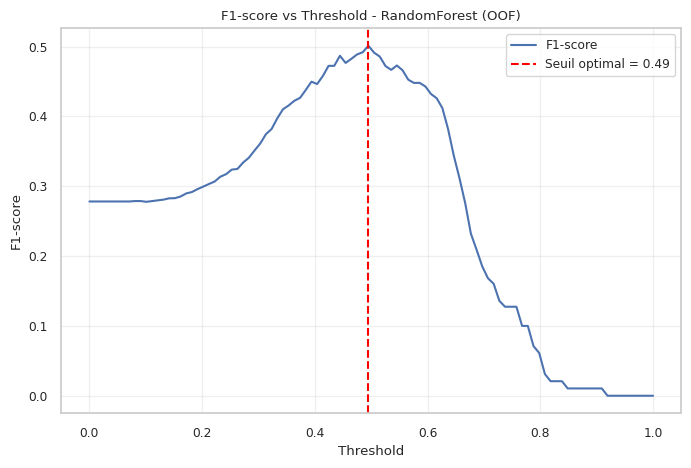

F1 max : 0.501 au seuil 0.495


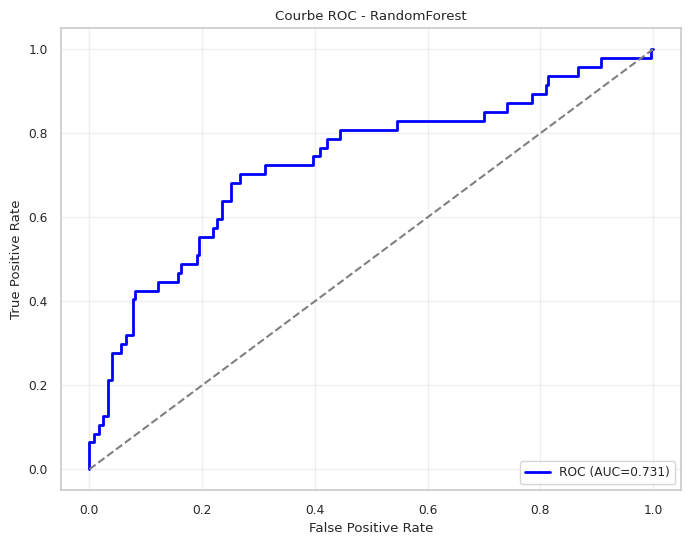

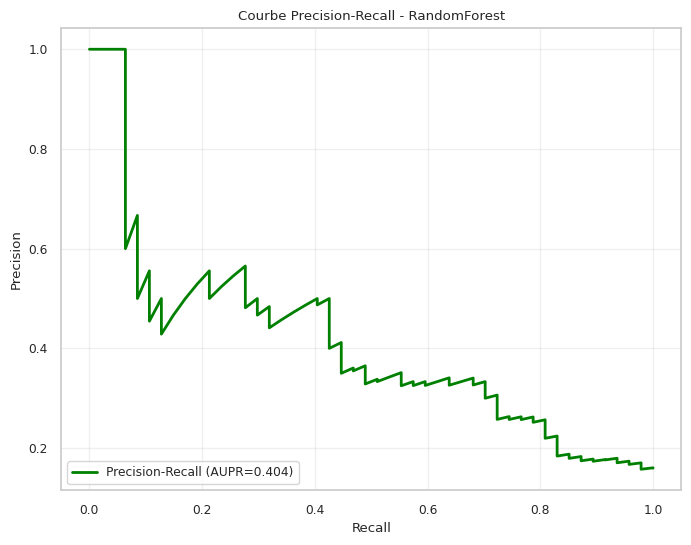


Classification report (Train) :
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       986
           1       0.67      0.75      0.71       190

    accuracy                           0.90      1176
   macro avg       0.81      0.84      0.82      1176
weighted avg       0.90      0.90      0.90      1176



,Prédit Non départ,Prédit Départ
Réel Non départ,914,72
Réel Départ,47,143



Classification report (Test) :
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       247
           1       0.41      0.45      0.43        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.66       294
weighted avg       0.82      0.81      0.81       294



,Prédit Non départ,Prédit Départ
Réel Non départ,217,30
Réel Départ,26,21


Validation croisée K-Fold (5 folds) :
ROC-AUC moyen ± std : 0.787 ± 0.044
F1 moyen ± std : 0.527 ± 0.051
Nb features transformées : 42
Nb importances : 42


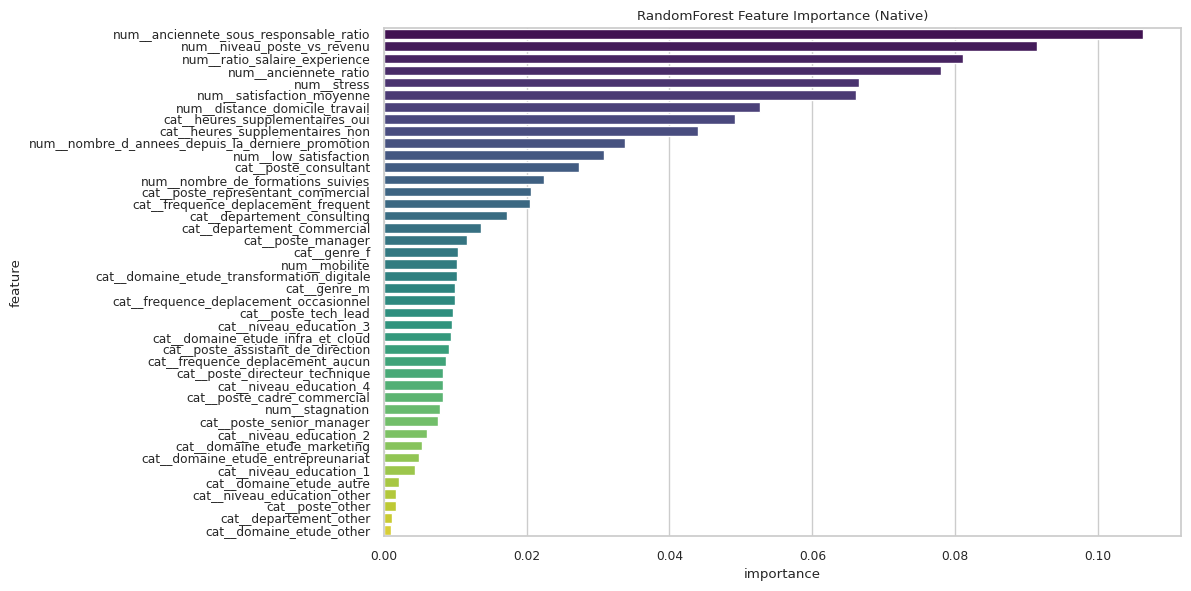

,feature,importance
3,num__anciennete_sous_responsable_ratio,0.106309
4,num__niveau_poste_vs_revenu,0.091469
1,num__ratio_salaire_experience,0.081144
2,num__anciennete_ratio,0.078068
9,num__stress,0.066507
0,num__satisfaction_moyenne,0.066070
5,num__distance_domicile_travail,0.052682
33,cat__heures_supplementaires_oui,0.049157
32,cat__heures_supplementaires_non,0.043972
7,num__nombre_d_annees_depuis_la_derniere_promotion,0.033798


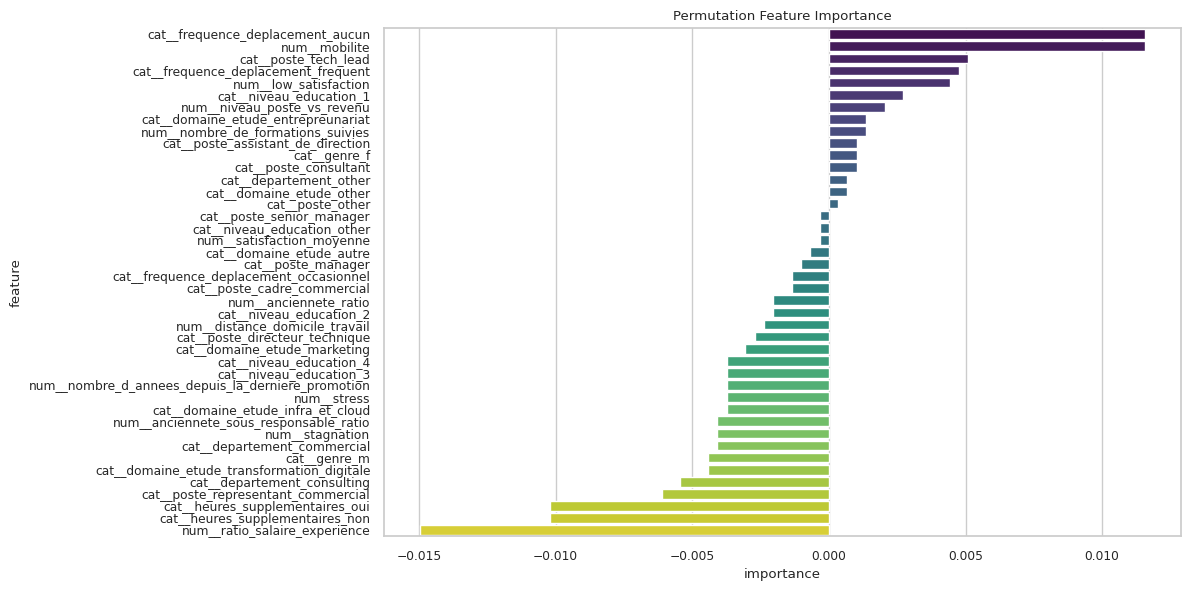

,feature,importance
34,cat__frequence_deplacement_aucun,0.011565
10,num__mobilite,0.011565
20,cat__poste_tech_lead,0.005102
35,cat__frequence_deplacement_frequent,0.004762
11,num__low_satisfaction,0.004422
37,cat__niveau_education_1,0.002721
4,num__niveau_poste_vs_revenu,0.002041
25,cat__domaine_etude_entrepreunariat,0.001361
6,num__nombre_de_formations_suivies,0.001361
12,cat__poste_assistant_de_direction,0.001020


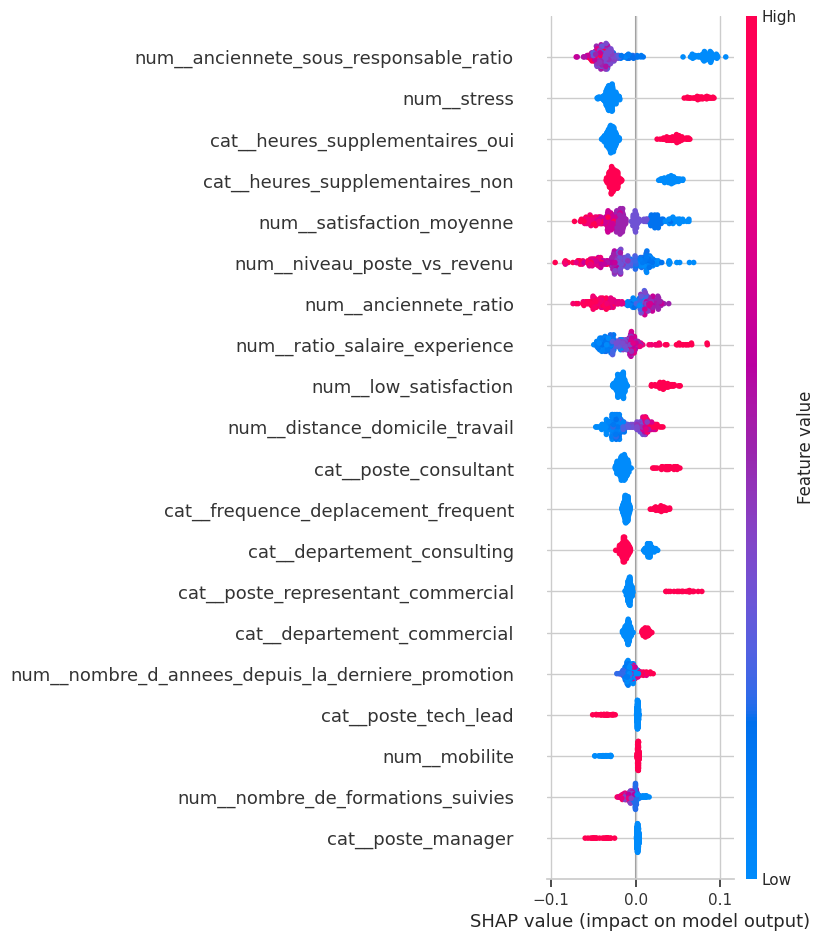

,feature,mean_abs_shap
3,num__anciennete_sous_responsable_ratio,0.045130
9,num__stress,0.036810
33,cat__heures_supplementaires_oui,0.033694
32,cat__heures_supplementaires_non,0.030319
0,num__satisfaction_moyenne,0.028164
4,num__niveau_poste_vs_revenu,0.025614
2,num__anciennete_ratio,0.024643
1,num__ratio_salaire_experience,0.022883
11,num__low_satisfaction,0.021938
5,num__distance_domicile_travail,0.019205


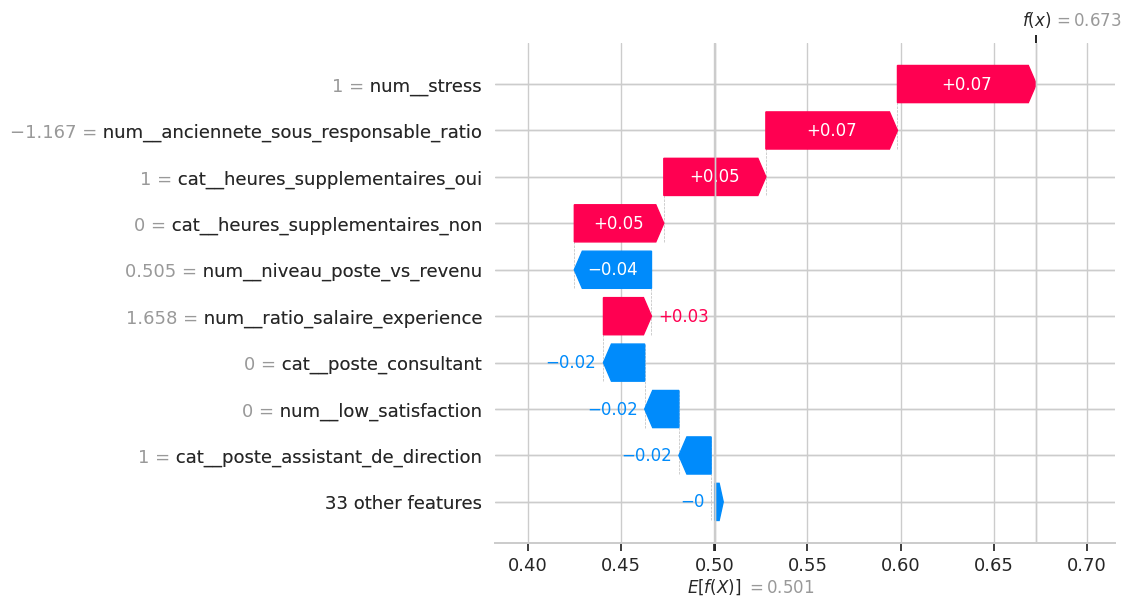

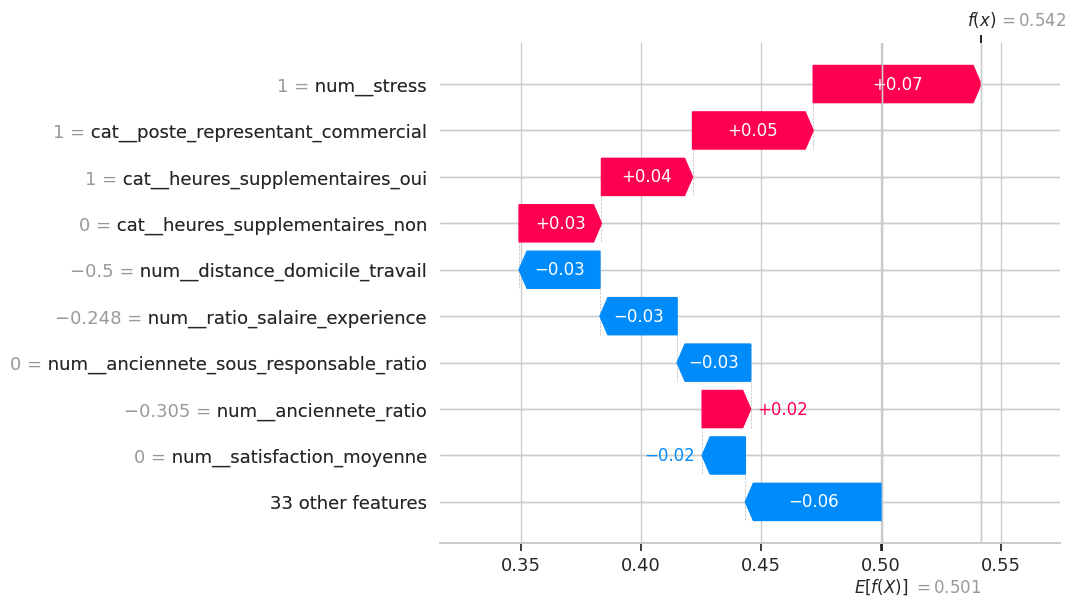

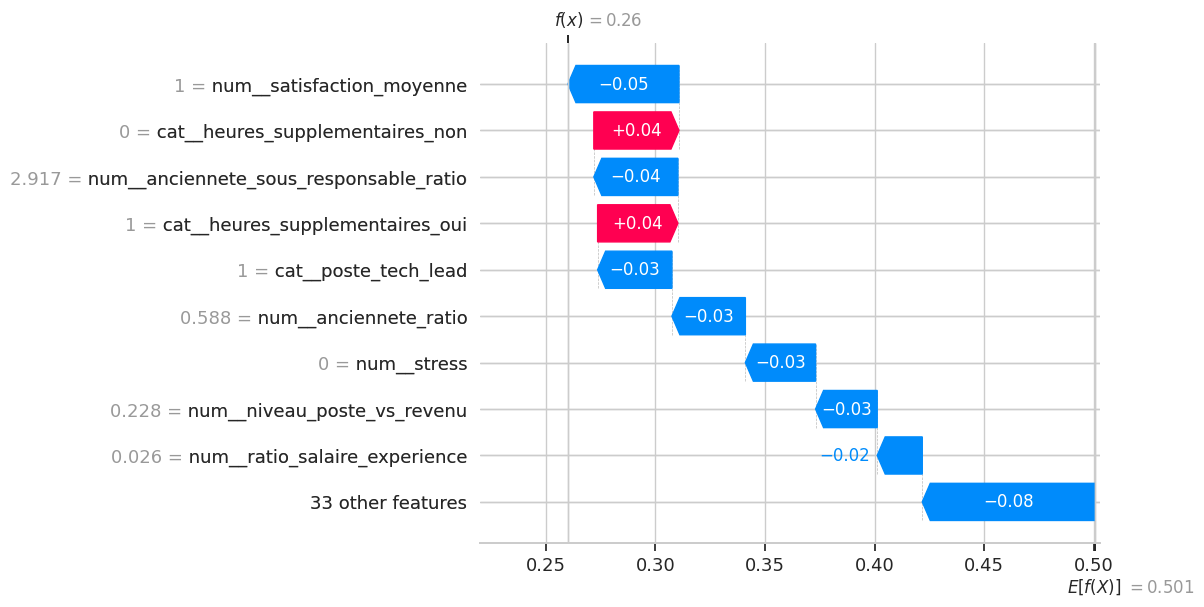

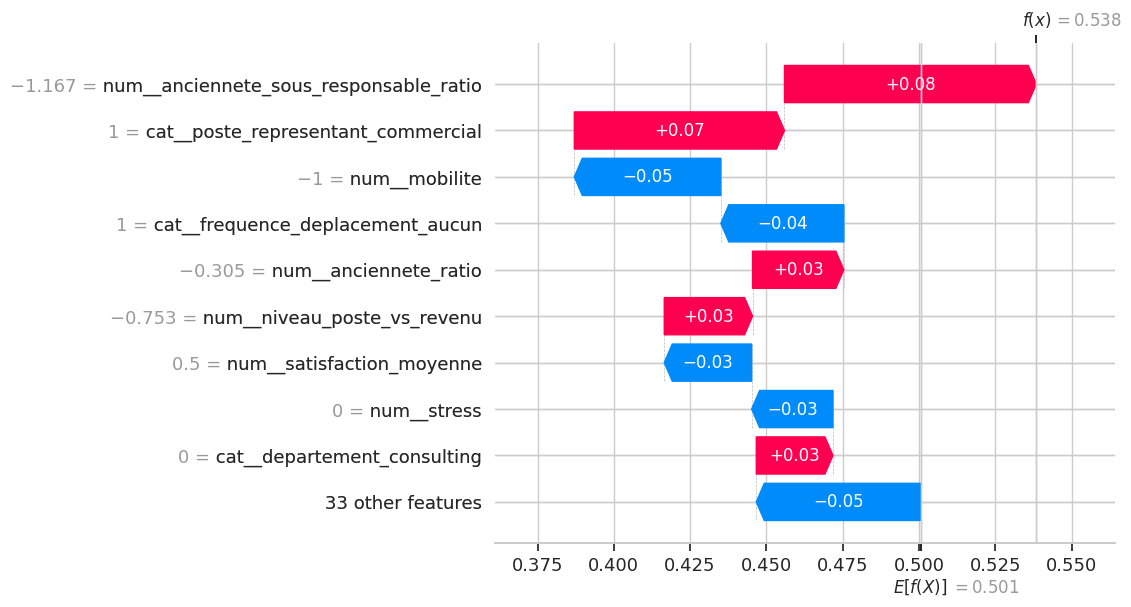

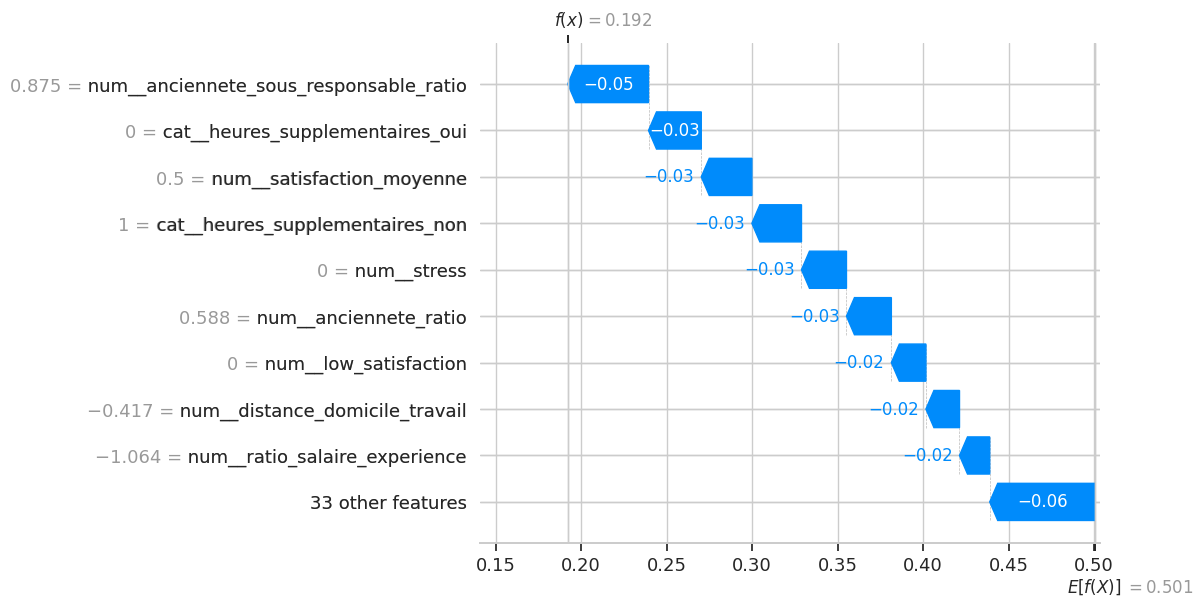

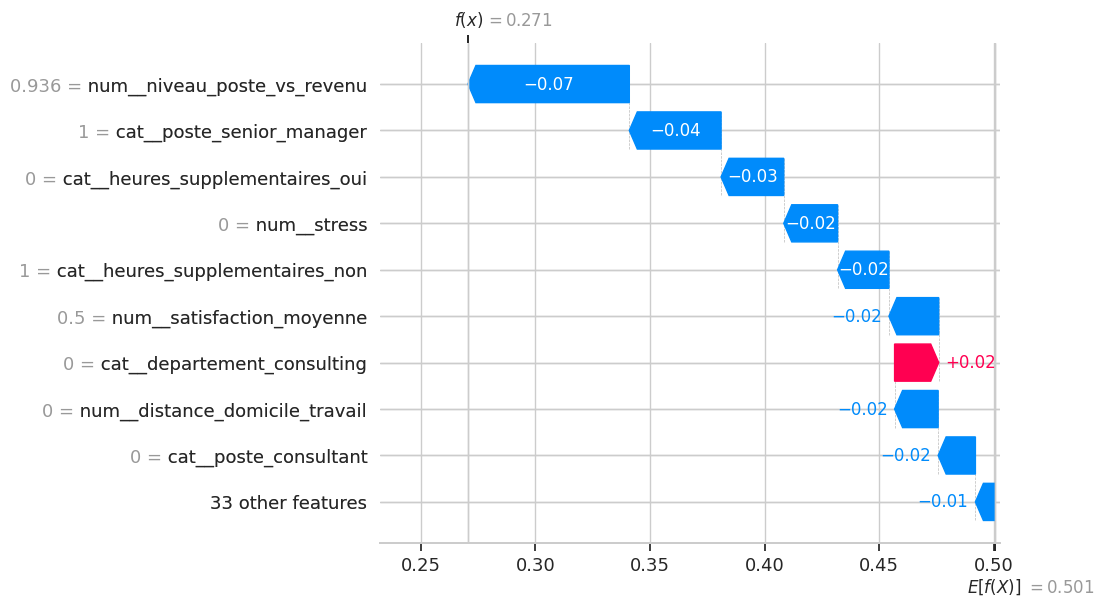


=== Feature Importance locale (Waterfall) pour les échantillons choisis ===

--- Échantillon 4 ---


,feature,shap_value
9,num__stress,0.074547
3,num__anciennete_sous_responsable_ratio,0.070636
33,cat__heures_supplementaires_oui,0.054802
32,cat__heures_supplementaires_non,0.048038
4,num__niveau_poste_vs_revenu,-0.041425
1,num__ratio_salaire_experience,0.025791
14,cat__poste_consultant,-0.022143
11,num__low_satisfaction,-0.018356
12,cat__poste_assistant_de_direction,-0.017311
2,num__anciennete_ratio,0.014468



--- Échantillon 20 ---


,feature,shap_value
9,num__stress,0.069899
18,cat__poste_representant_commercial,0.050251
33,cat__heures_supplementaires_oui,0.037924
32,cat__heures_supplementaires_non,0.034298
5,num__distance_domicile_travail,-0.033674
1,num__ratio_salaire_experience,-0.032123
3,num__anciennete_sous_responsable_ratio,-0.030638
2,num__anciennete_ratio,0.020207
0,num__satisfaction_moyenne,-0.018003
14,cat__poste_consultant,-0.016389



--- Échantillon 21 ---


...

,feature,shap_value
3,num__anciennete_sous_responsable_ratio,0.082516
18,cat__poste_representant_commercial,0.068854
10,num__mobilite,-0.048009
34,cat__frequence_deplacement_aucun,-0.040293
2,num__anciennete_ratio,0.029906
4,num__niveau_poste_vs_revenu,0.028930
0,num__satisfaction_moyenne,-0.028634
9,num__stress,-0.026641
22,cat__departement_consulting,0.025120
33,cat__heures_supplementaires_oui,-0.023596



--- Échantillon 1 ---


,feature,shap_value
3,num__anciennete_sous_responsable_ratio,-0.047252
33,cat__heures_supplementaires_oui,-0.030868
0,num__satisfaction_moyenne,-0.029595
32,cat__heures_supplementaires_non,-0.029003
9,num__stress,-0.026312
2,num__anciennete_ratio,-0.026257
11,num__low_satisfaction,-0.020222
5,num__distance_domicile_travail,-0.019633
1,num__ratio_salaire_experience,-0.017675
22,cat__departement_consulting,-0.013381



--- Échantillon 2 ---


,feature,shap_value
4,num__niveau_poste_vs_revenu,-0.070385
19,cat__poste_senior_manager,-0.040033
33,cat__heures_supplementaires_oui,-0.027334
9,num__stress,-0.023484
32,cat__heures_supplementaires_non,-0.022399
0,num__satisfaction_moyenne,-0.021714
22,cat__departement_consulting,0.019249
5,num__distance_domicile_travail,-0.019001
14,cat__poste_consultant,-0.016251
1,num__ratio_salaire_experience,0.015879


In [100]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, f1_score, roc_curve, auc
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Pipeline
pipeline_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__n_estimators': [300, 500],
    'classifier__max_depth': [5, 8],
    'classifier__min_samples_leaf': [2, 5],
    'classifier__max_features': ['sqrt', 'log2']
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_prob_oof = np.zeros(len(y_train))

# Nested CV pour OOF correct
for train_idx, val_idx in outer_cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # GridSearch interne
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid_search_fold = GridSearchCV(
        clone(pipeline_rf),
        param_grid=param_grid,
        scoring='roc_auc',
        cv=inner_cv,
        n_jobs=-1
    )
    grid_search_fold.fit(X_tr, y_tr)

    # Meilleur modèle de ce fold uniquement
    best_fold_model = clone(grid_search_fold.best_estimator_)
    best_fold_model.fit(X_tr, y_tr)
    
    # Probabilités OOF
    y_prob_oof[val_idx] = best_fold_model.predict_proba(X_val)[:,1]

# Fonction pour courbe F1 vs Threshold
def plot_f1_vs_threshold(model_name, y_true, y_prob_oof):
    thresholds = np.linspace(0, 1, 100)
    f1_scores = [f1_score(y_true, (y_prob_oof >= t).astype(int)) for t in thresholds]

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    plt.figure(figsize=(8,5))
    plt.plot(thresholds, f1_scores, label="F1-score")
    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Seuil optimal = {best_threshold:.2f}')
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs Threshold - {model_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    print(f"F1 max : {f1_scores[best_idx]:.3f} au seuil {best_threshold:.3f}")
    return best_threshold

best_threshold = plot_f1_vs_threshold("RandomForest (OOF)", y_train, y_prob_oof)

# Entraînement final sur tout le train avec meilleurs hyperparamètres
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search_final = GridSearchCV(
    clone(pipeline_rf),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=inner_cv,
    n_jobs=-1
)
grid_search_final.fit(X_train, y_train)
best_rf_model = clone(grid_search_final.best_estimator_)
best_rf_model.fit(X_train, y_train)

# Probabilités et prédictions avec le seuil optimal
y_prob_train = best_rf_model.predict_proba(X_train)[:,1]
y_pred_train = (y_prob_train >= best_threshold).astype(int)
y_prob_test = best_rf_model.predict_proba(X_test)[:,1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

# ROC et Precision-Recall + classification report
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
roc_auc_train = auc(fpr_train, tpr_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label=f'ROC (AUC={roc_auc_test:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - RandomForest')
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc_val = auc(recall_curve, precision_curve)
plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, color='green', lw=2, label=f'Precision-Recall (AUPR={pr_auc_val:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - RandomForest')
plt.grid(alpha=0.3)
plt.legend(loc='lower left')
plt.show()

print("\nClassification report (Train) :")
print(classification_report(y_train, y_pred_train, zero_division=0))
cm_train = confusion_matrix(y_train, y_pred_train)
display(pd.DataFrame(cm_train,
                     index=["Réel Non départ","Réel Départ"],
                     columns=["Prédit Non départ","Prédit Départ"]))

print("\nClassification report (Test) :")
print(classification_report(y_test, y_pred_test, zero_division=0))
cm_test = confusion_matrix(y_test, y_pred_test)
display(pd.DataFrame(cm_test,
                     index=["Réel Non départ","Réel Départ"],
                     columns=["Prédit Non départ","Prédit Départ"]))

# K-Fold final pour robustesse (avec seuil F1 par fold)
roc_auc_scores = []
f1_scores_cv = []
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model_fold = clone(best_rf_model)
    model_fold.fit(X_tr, y_tr)
    y_val_prob = model_fold.predict_proba(X_val)[:,1]
    
    roc_auc_scores.append(roc_auc_score(y_val, y_val_prob))
    
    precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)
    f1_fold = 2*(precision*recall)/(precision+recall+1e-6)
    best_thresh_fold = thresholds[np.argmax(f1_fold)]
    y_val_pred = (y_val_prob >= best_thresh_fold).astype(int)
    f1_scores_cv.append(f1_score(y_val, y_val_pred))

print(f"Validation croisée K-Fold (5 folds) :")
print(f"ROC-AUC moyen ± std : {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"F1 moyen ± std : {np.mean(f1_scores_cv):.3f} ± {np.std(f1_scores_cv):.3f}")


# Feature importance Native, Permutation et SHAP
X_test_transformed = best_rf_model.named_steps['preprocessor'].transform(X_test)
rf_classifier = best_rf_model.named_steps['classifier']
feature_names_transformed = best_rf_model.named_steps['preprocessor'].get_feature_names_out()

print("Nb features transformées :", len(feature_names_transformed))
print("Nb importances :", len(rf_classifier.feature_importances_))

# Native
rf_importances = pd.DataFrame({
    'feature': feature_names_transformed,
    'importance': rf_classifier.feature_importances_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=rf_importances, palette='viridis', hue='feature')
plt.title("RandomForest Feature Importance (Native)")
plt.tight_layout()
plt.show()
display(rf_importances)

# Permutation
perm_importance = permutation_importance(
    rf_classifier, X_test_transformed, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': feature_names_transformed,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=perm_df, palette='viridis', hue='feature')
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()
display(perm_df)

# SHAP
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer(X_test_transformed)
if shap_values.values.ndim == 3 and shap_values.values.shape[2] == 2:
    shap_values_class1 = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:,1].mean() if shap_values.base_values.ndim==2 else shap_values.base_values[1],
        data=shap_values.data,
        feature_names=feature_names_transformed
    )
else:
    shap_values_class1 = shap_values

shap.summary_plot(shap_values_class1, features=X_test_transformed, feature_names=feature_names_transformed, plot_type="dot")

shap_importance = pd.DataFrame({
    'feature': feature_names_transformed,
    'mean_abs_shap': np.abs(shap_values_class1.values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)
display(shap_importance)


# Feature importance locale avec Waterfall (3 positifs + 3 négatifs)
indices_pos = np.where(y_test == 1)[0][:3]
indices_neg = np.where(y_test == 0)[0][:3]
indices = np.concatenate([indices_pos, indices_neg])

local_shap_values_list = []

for i in indices:
    expl = shap.Explanation(
        values=shap_values_class1.values[i],
        base_values=shap_values_class1.base_values,
        data=shap_values_class1.data[i],
        feature_names=feature_names_transformed
    )
    shap.waterfall_plot(expl)
    
    df_local = pd.DataFrame({
        'feature': feature_names_transformed,
        'shap_value': expl.values
    }).sort_values(by='shap_value', key=np.abs, ascending=False)
    local_shap_values_list.append((i, df_local))

print("\n=== Feature Importance locale (Waterfall) pour les échantillons choisis ===")
for idx, df_local in local_shap_values_list:
    print(f"\n--- Échantillon {idx} ---")
    display(df_local)

#### observations

**Évolution des performances du Random Forest (Étapes 3 à 5)**

| Étape                                   | ROC-AUC test | Precision (classe 1) | Recall (classe 1) | F1 (classe 1) | Lecture |
|----------------------------------------|-------------|---------------------|------------------|--------------|--------|
| Étape 3 (RF baseline)                  | 0.736       | 0.36                | 0.36             | 0.36         | Modèle très overfit (AUC train = 1.0), faible détection des départs |
| Étape 4.1 (undersampling)              | 0.710       | 0.35                | 0.32             | 0.33         | Dégradation légère > perte d’information avec undersampling |
| Étape 4.2 (class_weight + régularisation) | 0.730    | 0.33                | 0.55             | 0.41         | Forte amélioration du recall > meilleure détection des départs |
| Étape 5 (nested CV + seuil optimisé)   | 0.731       | 0.41                | 0.45             | 0.43         | Meilleur équilibre précision / recall > modèle plus exploitable |

**Lecture de la progression (logique globale)**
- **Étape 3 vers Étape 4.1 (undersampling)**
    - **Pas d'amélioration** car le modèle perd en performance (F1 baisse, recall baisse)  
    - **Causes :**
        - Perte d’information due à l’undersampling  
        - Moins de structure dans les données  
    - **étape utile exploratoirement, mais pas optimale seule** 
- **Étape 4.1 vers Étape 4.2 (régularisation + class_weight)**
- **Grosse amélioration métier**
    - Recall passe de **0.32 à 0.55**  
    - F1 passe de **0.33 à 0.41**  
- **Le modèle devient :**
    - beaucoup plus sensible aux départs  
    - mais avec plus de faux positifs (precision baisse)  
- un peu de précision est sacrifiéé pour mieux capter les départs  
- **Étape 4.2 vers Étape 5 (nested CV + seuil optimisé)**
- **Amélioration qualitative (plus que quantitative)**

| Avant                         | Après                          |
|------------------------------|--------------------------------|
| Recall élevé (0.55) mais bruité | Recall stabilisé (0.45)     |
| Precision faible (0.33)      | Precision meilleure (0.41)     |
| Risque d’overfitting         | Modèle robuste (CV + OOF)      |
- **améliorations obtenues:**
    - Modèle plus stable  
    - Moins dépendant d’un split train/test  
    - Meilleur compromis précision / recall  

- **Conclusion sur l'évolution des étapes de modélisation**
    - il y a une progression logique :
        - Étape 3 : modèle instable et overfit  
        - Étape 4.1 : tentative qui dégrade (undersampling seul)  
        - Étape 4.2 : amélioration nette du recall (objectif métier)  
        - Étape 5 : stabilisation + meilleur équilibre global
 
**Performance globale du modèle Random Forest étape 5**

| Métrique                   | Valeur obtenue                     | Interprétation |
|-----------------------------|-----------------------------------|----------------|
| F1 max (OOF)                | 0.501 au seuil 0.495              | Seuil légèrement inférieur à 0.5 pour équilibrer précision/recall sur la classe minoritaire |
| ROC-AUC test                | 0.731                             | Modèle capable de séparer classes mais avec marge de progression |
| Classification report train | F1 classe 1 = 0.71                | Bon apprentissage sur la classe minoritaire, mais léger surapprentissage sur la classe majoritaire |
| Classification report test  | F1 classe 1 = 0.43                | Perte de performance sur classe minoritaire, signe de déséquilibre et complexité du problème |
| Validation K-Fold           | ROC-AUC moyen +/- std = 0.787 +/- 0.044, F1 moyen +/- std = 0.527 +/- 0.051 | Indique robustesse relative du modèle sur différentes partitions |

- **Observations principales :**
    - Le tuning des hyperparamètres et l’optimisation du seuil F1 améliorent la détection de la classe minoritaire.  
    - Le modèle reste relativement conservatif sur la prédiction de la classe 1, en raison d'un dataset déséquilibré.  
    - Nested CV a permis d’éviter la fuite de données lors du GridSearch, donnant un OOF fiable pour estimer la performance réelle.  

**Hyperparamètres et impact sur le comportement**
- `max_depth=5` : limite la profondeur et réduit l’overfitting sur la classe majoritaire.
- `min_samples_leaf=5` : stabilise les arbres et évite que des échantillons rares dominent la décision.  
- `max_features='log2'` : augmente la diversité des arbres et améliore la robustesse.  
- Seuil F1 optimal ~0.465 : permet de mieux capturer la classe minoritaire au détriment d’un léger drop en précision pour la classe majoritaire.  
- **Conclusion :** les hyperparamètres favorisent la généralisation et la robustesse sur des classes déséquilibrées.  

**Feature importance globale**

- **Méthode RandomForest native (Gini)**
    - Dominante sur les features continues liées à l’expérience et aux heures supplémentaires :  
      `anciennete_sous_responsable_ratio`, `niveau_poste_vs_revenu`, `satisfaction_moyenne`, `heures_supplementaires_oui/non`  
    - **Limite** : surestime les variables continues corrélées et ignore l’importance réelle des features catégorielles.  

- **Méthode Permutation importance**
    - Évalue l’impact réel sur la prédiction : les features les plus influentes sont moins corrélées et incluent `poste_manager`, `poste_tech_lead`, `distance_domicile_travail`.  
    - Certaines features ont des valeurs négatives > ces features apparaissent comme peu informatives et leur permutation permet de casser le bruit que ces features apportent ce qui améliore légèrement les performances du modèle.

- **Méthode SHAP (mean absolute)**
    - Capture l’impact moyen par prédiction :  
      `heures_supplementaires_oui` > `anciennete_sous_responsable_ratio` > `satisfaction_moyenne`  
    - SHAP révèle que les features liées aux heures supplémentaires ont un effet plus important que le Gini n’indique, et montre l’influence combinée des features continues et catégorielles.  

**Feature importance locale (Waterfall SHAP)**
- Exemple pour 6 individus : `num__stress`, `anciennete_sous_responsable_ratio`, `heures_supplementaires_oui/non` dominent les prédictions.  
- Les features inversent leur effet selon l’individu : un stress élevé ou une faible `satisfaction_moyenne` augmente la probabilité de départ.  
- Les features catégorielles peu importantes globalement peuvent avoir un rôle déterminant pour certains individus (`poste_representant_commercial`, `poste_tech_lead`).  
- **Insight clé :** SHAP permet d’expliquer au niveau individuel pourquoi un employé est prédit comme “départ”, crucial pour l’interprétabilité et les décisions RH.  

**Synthèse des patterns détectés**
- **Variables clés du turnover :**  
  - **Ancienneté sous-responsable**,
  - **stress**,
  - **heures supplémentaires**,
  - **satisfaction moyenne** 
- **Interaction features :** certaines features comme le poste ou les formations impactent seulement certains profils.  
- **Classe minoritaire :** toujours plus difficile à détecter → seuil F1 optimisé et nested CV a limité la fuite d’information.  
- **Déséquilibre vs performance :** F1 classe 1 reste faible (~0.43 test), mais macro F1 amélioré (0.66 OOF).  
- **Conclusion :** modèle robuste mais sensible au déséquilibre et au bruit.  

**Inteprétation d'un point de vue métier des performances du modèle**
- **Évolution des métriques du RandomForest**
| Étape                                 | Precision classe 1 | Recall classe 1 | F1 classe 1 | Commentaire |
|--------------------------------------|-----------------|----------------|-------------|------------|
| 4 partie 1 (undersampling)            | 0.35            | 0.32           | 0.33        | Très faible rappel > beaucoup de départs manqués, précision faible → trop de faux positifs, ROC-AUC test = 0.71 |
| 4 partie 2 (class weight + régularisation) | 0.33        | 0.55           | 0.41        | Rappel fortement amélioré > on détecte mieux les départs, même si précision un peu moindre → plus de faux positifs |
| 5 (seuil optimisé + K-Fold)           | 0.41            | 0.45           | 0.43        | Meilleur équilibre > rappel et précision plus proches, détection des départs plus fiable, ROC-AUC stable 0.73 |

- **Lecture directe de la matrice de confusion (TEST)**

|                      | Prédit Non départ | Prédit Départ |
|----------------------|------------------|---------------|
| Réel Non départ (0)  | 217              | 30            |
| Réel Départ (1)      | 26               | 21            |

- **Classe 0 = “reste”**
    - **Correctement prédits** : 217  
    - **Total** : 247  
    - **Recall classe 0** = 217 / 247 = **0.88**  
    - **Faux positifs** : 30  
    - **Precision classe 0** = 217 / (217 + 26) ≈ **0.89**  
    - **Conclusion :**
    - Le modèle reconnaît très bien ceux qui restent  
    - Peu d’erreurs sur cette classe  

- **Classe 1 = “départ”**
    - **Correctement prédits** : 21  
    - **Total** : 47  
    - **Recall classe 1** = 21 / 47 ≈ **0.45**  
    - **Faux positifs** : 30  
    - **Precision classe 1** = 21 / (21 + 30) ≈ **0.41**  
    - **Conclusion :**
    - Le modèle rate plus de la moitié des départs  
    - Et se trompe souvent quand il prédit un départ  

- **Comparaison directe des performances**

| Classe           | Precision | Recall | F1   |
|------------------|----------|--------|------|
| Non départ (0)   | 0.89     | 0.88   | 0.89 |
| Départ (1)       | 0.41     | 0.45   | 0.43 |

- **Écart très clair :**
    - Classe 0 > très bien prédite  
    - Classe 1 > beaucoup plus difficile
    - car déséquilibre des classes (247 “reste” vs 47 “départ” )
    - Le modèle “apprend mieux” la classe majoritaire  


- **Qui le modèle prédit-il mieux ?**
    - **Classe départ (minoritaire)**
        - **Recall ≈ 0.45** > il détecte presque la moitié des départs réels.  
        - **Précision ≈ 0.41** > parmi ceux qu’il prédit départ, un peu moins de la moitié sont corrects.  
        - **Conclusion : le modèle est moyennement fiable pour prévoir qui va partir.**
    - **Classe non-départ (majoritaire)**
        - Très bonne précision et rappel (≈0.88–0.89) > **le modèle prévoit assez bien qui ne va pas démissionner.**  
        - **Conclusion : on peut être assez confiant pour ne pas s’inquiéter inutilement des salariés qui restent.**

- **Synthèse**
    - **Le modèle Random Forest de l'étape 5 prédit mieux les salariés qui vont rester (classe majoritaire) que ceux qui vont partir.**
    - **Il détecte certains départs, mais pas tous ce qui est utile pour cibler des actions de rétention, mais il faut accepter un certain taux de faux positifs et de départs manqués.**  
    - **Optimisation future** : si l’objectif métier est de maximiser le rappel des départs, on pourrait ajuster le seuil pour prédire plus de départs, au prix de diminuer la précision.


**Actions de suite pour aller plus loin et améliorer les performances du modèle**
- **Calibration du modèle :** vérifier si un recalibrage (`CalibratedClassifierCV`) améliore la probabilité prédictive pour la classe minoritaire.   
- **Feature engineering :** combiner les variables sur le stress et les heures supplémentaires pour capturer l’effet cumulatif.  
- **Monitoring RH :** utiliser les SHAP locaux pour identifier des patterns de départ individuels, utile pour actions préventives.